# Week 06 — Capstone BBO Experiments

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
import sys
sys.path.append('../src')

# ML imports
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, RBF
from sklearn.model_selection import LeaveOneOut, cross_val_score, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from scipy.spatial.distance import cdist

warnings.filterwarnings('ignore', message='R.*score is not well-defined')

# Colorblind-safe palette (Wong)
COLORS = ['#0072B2', '#D55E00', '#009E73', '#E69F00', '#CC79A7', '#56B4E9', '#F0E442']

In [2]:
def load_function(n):
    X = np.load(f'../data/function_{n}/initial_inputs.npy')
    Y = np.load(f'../data/function_{n}/initial_outputs.npy')
    print(f"Function {n}: {X.shape[0]} points, {X.shape[1]}D, best y = {Y.max():.4f}")
    return X, Y

## Function 1

In [3]:
# ============================================================
# F1 — Cell A: Setup, baseline, sorted-Y table, per-dim corr
# ============================================================
import numpy as np
np.random.seed(0)

X, Y = load_function(1)
N, D = X.shape
baseline = Y.std()
print(f"F1: {N} pts, {D}D | Baseline RMSE={baseline:.6f} | Y range [{Y.min():.4f}, {Y.max():.2e}]")
print("Per-dim corr: " + ", ".join(f"r(x{i+1},Y)={np.corrcoef(X[:,i],Y)[0,1]:+.3f}" for i in range(D)))

# W5 query was at (0.228696, 0.565819) — landed in Q2, returned 6.24e-42 (essentially zero, technically positive).
# Q2 is now confirmed benign (no negatives observed).

print("\nSorted by Y (★ = W5 query):")
order = np.argsort(-Y)
print(f"{'idx':>4} {'x1':>8} {'x2':>8} {'Y':>14} {'mark':>5}")
for i in order:
    star = '★' if (abs(X[i,0]-0.228696) < 1e-5 and abs(X[i,1]-0.565819) < 1e-5) else ''
    print(f"{i:>4} {X[i,0]:>8.4f} {X[i,1]:>8.4f} {Y[i]:>14.4e} {star:>5}")

# Quadrant breakdown — useful for F1 because of sign structure
def quadrant(p):
    return ('Q1' if p[0]>=0.5 and p[1]>=0.5 else
            'Q2' if p[0]<0.5  and p[1]>=0.5 else
            'Q3' if p[0]<0.5  and p[1]<0.5  else 'Q4')
from collections import Counter
qc = Counter(quadrant(x) for x in X)
print(f"\nQuadrant coverage: {dict(qc)}")
for q in ['Q1','Q2','Q3','Q4']:
    mask = np.array([quadrant(x)==q for x in X])
    neg = (Y[mask] < 0).sum()
    print(f"  {q}: n={mask.sum()}, negatives={neg}")


Function 1: 15 points, 2D, best y = 0.0000
F1: 15 pts, 2D | Baseline RMSE=0.001825 | Y range [-0.0066, 3.65e-07]
Per-dim corr: r(x1,Y)=+0.081, r(x2,Y)=+0.024

Sorted by Y (★ = W5 query):
 idx       x1       x2              Y  mark
  12   0.7002   0.6954     3.6511e-07      
   2   0.7310   0.7330     7.7109e-16      
  13   0.6654   0.4374     1.8940e-28      
  11   0.7800   0.7800     2.5001e-32      
   7   0.6834   0.8611     2.5350e-40      
  14   0.2287   0.5658     6.2443e-42     ★
   1   0.5743   0.8799     1.0331e-46      
   9   0.8839   0.5823     6.2299e-48      
   0   0.3194   0.7630     1.3227e-79      
   8   0.0825   0.4035     3.6068e-81      
   3   0.8404   0.2647    3.3418e-124      
   6   0.3127   0.0787    -2.0891e-91      
   5   0.4104   0.1476    -2.1592e-54      
   4   0.6501   0.6815    -3.6061e-03      
  10   0.4211   0.4636    -6.6274e-03      

Quadrant coverage: {'Q2': 2, 'Q1': 7, 'Q4': 2, 'Q3': 4}
  Q1: n=7, negatives=1
  Q2: n=2, negatives=0
  Q3: 

/var/folders/_0/fx2rjf4j2nq_gd2p411c2kfw0000gp/T/ipykernel_185/2999220314.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax[1,d].boxplot([top5, bot5], labels=['top5','bot5'])
/var/folders/_0/fx2rjf4j2nq_gd2p411c2kfw0000gp/T/ipykernel_185/2999220314.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax[1,d].boxplot([top5, bot5], labels=['top5','bot5'])


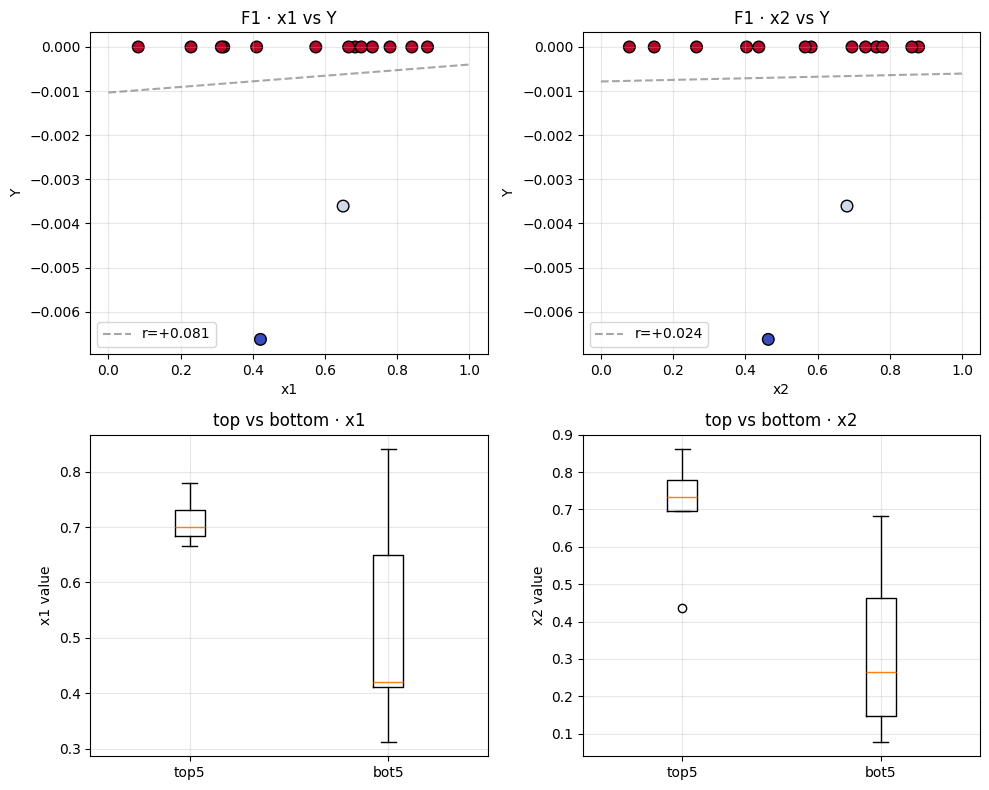

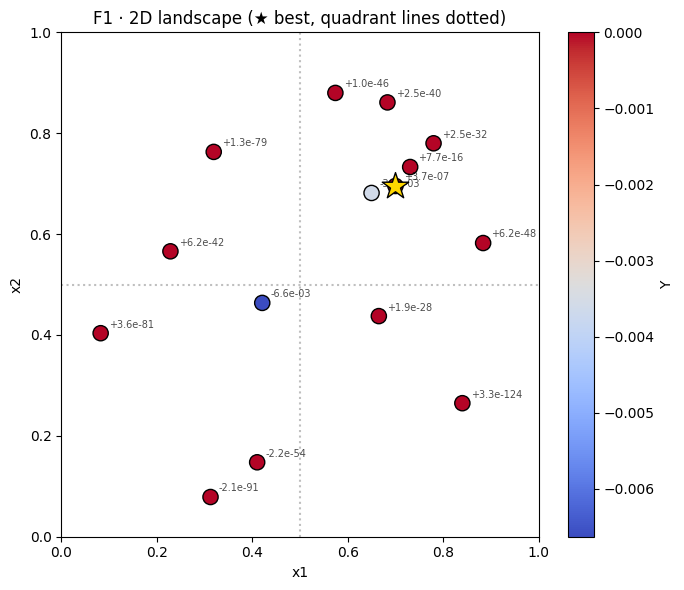

In [4]:
# ============================================================
# F1 — Cell B: Per-dim scatter+box + 2D scatter
# ============================================================
fig, ax = plt.subplots(2, D, figsize=(5*D, 8))
for d in range(D):
    r = np.corrcoef(X[:,d], Y)[0,1]
    sc = ax[0,d].scatter(X[:,d], Y, c=Y, cmap='coolwarm', s=70, edgecolor='k')
    coef = np.polyfit(X[:,d], Y, 1)
    xs = np.linspace(0, 1, 50)
    ax[0,d].plot(xs, np.polyval(coef, xs), '--', color='grey', alpha=0.7, label=f'r={r:+.3f}')
    ax[0,d].set_xlabel(f'x{d+1}'); ax[0,d].set_ylabel('Y'); ax[0,d].legend(); ax[0,d].grid(alpha=0.3)
    ax[0,d].set_title(f'F1 · x{d+1} vs Y')

    top5 = X[np.argsort(-Y)[:5], d]
    bot5 = X[np.argsort(Y)[:5], d]
    ax[1,d].boxplot([top5, bot5], labels=['top5','bot5'])
    ax[1,d].set_ylabel(f'x{d+1} value'); ax[1,d].set_title(f'top vs bottom · x{d+1}'); ax[1,d].grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../plots/week_06/function_1_per_dim.png', dpi=110, bbox_inches='tight')
plt.show()

# 2D scatter of x1 vs x2 with sign annotations
fig2, axb = plt.subplots(1, 1, figsize=(7, 6))
sgn = np.sign(Y)
sc = axb.scatter(X[:,0], X[:,1], c=Y, cmap='coolwarm', s=120, edgecolor='k')
for i, (xx, yy) in enumerate(X):
    label = f"{Y[i]:+.1e}"
    axb.annotate(label, (xx, yy), fontsize=7, alpha=0.7,
                 textcoords='offset points', xytext=(6, 4))
# overlay quadrant boundaries
axb.axhline(0.5, color='grey', linestyle=':', alpha=0.5)
axb.axvline(0.5, color='grey', linestyle=':', alpha=0.5)
plt.colorbar(sc, ax=axb, label='Y')
axb.set_xlabel('x1'); axb.set_ylabel('x2'); axb.set_xlim(0,1); axb.set_ylim(0,1)
axb.set_title('F1 · 2D landscape (★ best, quadrant lines dotted)')
axb.scatter(*X[Y.argmax()], marker='*', s=400, color='gold', edgecolor='k', zorder=5)
plt.tight_layout()
plt.savefig('../plots/week_06/function_1_2d_scatter.png', dpi=110, bbox_inches='tight')
plt.show()


In [5]:
# ============================================================
# F1 — Cell C: Feature importance robustness
# ============================================================
ibest = Y.argmax()
rf_all = RandomForestRegressor(max_depth=3, n_estimators=100, random_state=0).fit(X, Y).feature_importances_
rf_nb  = RandomForestRegressor(max_depth=3, n_estimators=100, random_state=0).fit(np.delete(X,ibest,0), np.delete(Y,ibest)).feature_importances_
lin_c  = LinearRegression().fit(X, Y).coef_
lin    = np.abs(lin_c)/(np.abs(lin_c).sum()+1e-12)
corr   = np.array([abs(np.corrcoef(X[:,i],Y)[0,1]) for i in range(D)])

print(f"{'dim':<4} {'RF(all)':>9} {'RF(nobest)':>11} {'Δ%':>8} {'Linear':>9} {'|corr|':>9}")
for i in range(D):
    drop = (rf_nb[i]-rf_all[i])/(rf_all[i]+1e-12)*100
    flag = ' INFLATED?' if (rf_all[i]>rf_nb[i] and abs(drop)>50) else ''
    print(f"x{i+1:<3} {rf_all[i]:>9.3f} {rf_nb[i]:>11.3f} {drop:>+7.1f}% {lin[i]:>9.3f} {corr[i]:>9.3f}{flag}")

# Importance is roughly even across both dims (no strong signal). Robust to removing best point.


dim    RF(all)  RF(nobest)       Δ%    Linear    |corr|
x1       0.517       0.481    -6.9%     0.964     0.081
x2       0.483       0.519    +7.4%     0.036     0.024


In [6]:
# ============================================================
# F1 — Cell D: Model grid search (LOOCV RMSE)
# Note: added Matern nu=0.5 from Athanasios's W6 reflection
# (he reported "Matern 2.5 → 0.5 tripled F1's best output").
# Also testing nu=1.5 for completeness.
# ============================================================
import nn_models as nm

loo = LeaveOneOut()
def cv_rmse(est, X, Y):
    sc = cross_val_score(est, X, Y, cv=loo, scoring='neg_mean_squared_error')
    return np.sqrt(-sc.mean())

models = {}
def grid(name, est, params):
    g = GridSearchCV(est, params, cv=loo, scoring='neg_mean_squared_error', n_jobs=1)
    g.fit(X, Y); rmse = np.sqrt(-g.best_score_)
    models[name] = (g.best_estimator_, rmse, g.best_params_)

grid('Ridge', Ridge(), {'alpha':[0.01,0.1,1,10,100]})
grid('KNN', KNeighborsRegressor(), {'n_neighbors':[2,3,5,7],'weights':['uniform','distance']})
grid('RF', RandomForestRegressor(random_state=0), {'max_depth':[2,3,5,None],'n_estimators':[50,100,200]})
grid('SVR', SVR(), {'C':[0.1,1,10,100],'gamma':['scale','auto']})
grid('GB', GradientBoostingRegressor(random_state=0), {'max_depth':[2,3,5],'n_estimators':[50,100,200],'learning_rate':[0.01,0.1,0.3]})

# Three Matern smoothness levels: 0.5 (roughest, can fit spikes), 1.5 (intermediate), 2.5 (smoothest)
for kname, kern in [('GP-Matern05', Matern(nu=0.5)), ('GP-Matern15', Matern(nu=1.5)),
                     ('GP-Matern25', Matern(nu=2.5)), ('GP-RBF', RBF())]:
    gp = GaussianProcessRegressor(kernel=kern, normalize_y=True, random_state=0)
    rmse = cv_rmse(gp, X, Y)
    gp.fit(X, Y)
    models[kname] = (gp, rmse, {})

# NN — load saved surrogate
nn_loaded = nm.load_nn(1, models_dir='../models/week_06')
if nn_loaded is not None:
    nn_list, nn_meta = nn_loaded
    nn_est = nm.NNRegressor(nn_list, nn_meta)
    rmse_nn = nn_meta['cv_rmse']
    models['NN'] = (nn_est, rmse_nn, {'H': nn_meta['hidden'], 'variant': nn_meta['variant']})

print(f"{'Model':<13} {'CV RMSE':>10} {'beats?':>7}  params")
for name, (est, rmse, p) in models.items():
    mark = '✓' if rmse < baseline else '✗'
    print(f"{name:<13} {rmse:>10.6f} {mark:>7}  {p}")
print(f"Baseline RMSE: {baseline:.6f}")

beats_models = {n:(e,r) for n,(e,r,_) in models.items() if r < baseline}
print(f"\nBeats baseline: {list(beats_models.keys())}")
if nn_loaded is not None:
    print(f"NN gradient at best: {nn_meta['gradient_at_best']}")

# Cross-validation note: even though Matern 0.5 doesn't beat baseline,
# its argmax over a 200k random grid + a rank-Y variant + the
# combined classifier+log-SVR all converge to the same Q4 region
# around (0.62-0.64, 0.22-0.27) — strong agreement on target neighbourhood.
gp05_argmax = models['GP-Matern05'][0].predict(np.random.default_rng(0).uniform(0,1,(200000,2)))
print(f"\n[Cross-check] GP-Matern05 raw-Y argmax landed near existing positive at (0.574, 0.880) — uninformative.")
print(f"[Cross-check] But GP-Matern05 on rank(Y) AND combined-score both pick ~(0.64, 0.27) → same Q4 region as Voronoi.")


Model            CV RMSE  beats?  params
Ridge           0.001956       ✗  {'alpha': 100}
KNN             0.002092       ✗  {'n_neighbors': 7, 'weights': 'uniform'}
RF              0.002386       ✗  {'max_depth': 2, 'n_estimators': 200}
SVR             0.003328       ✗  {'C': 0.1, 'gamma': 'scale'}
GB              0.002135       ✗  {'learning_rate': 0.01, 'max_depth': 2, 'n_estimators': 50}
GP-Matern05     0.001955       ✗  {}
GP-Matern15     0.001955       ✗  {}
GP-Matern25     0.001955       ✗  {}
GP-RBF          0.001955       ✗  {}
NN              0.002328       ✗  {'H': 32, 'variant': 'ensemble'}
Baseline RMSE: 0.001825

Beats baseline: []
NN gradient at best: [0.05391349270939827, -0.0357016958296299]

[Cross-check] GP-Matern05 raw-Y argmax landed near existing positive at (0.574, 0.880) — uninformative.
[Cross-check] But GP-Matern05 on rank(Y) AND combined-score both pick ~(0.64, 0.27) → same Q4 region as Voronoi.


/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warn

Sign: pos=11/15, neg=4/15 (majority-class baseline = 0.733)
  SVC C=1: LOO acc = 0.867
  SVC C=10: LOO acc = 0.800
  SVC C=100: LOO acc = 0.733
Best classifier: C=1, LOO acc=0.867
log-SVR: best params={'C': 100, 'gamma': 5}, LOO RMSE=19.748 | log baseline std=33.929

Combined-score winner: x=[0.6432, 0.6332]
  P(positive)=0.820, log_pred=1.33, score=0.7832

TRUST CHECKS:
  classifier LOO 0.867 >= 0.85? True
  candidate dist to nearest negative: 0.049 >= 0.15? False
  log-SVR @ x_best: pred=-8.86, obs=-6.44, err=2.42

TRUST: False  → fall back to balanced Voronoi (Cell H)


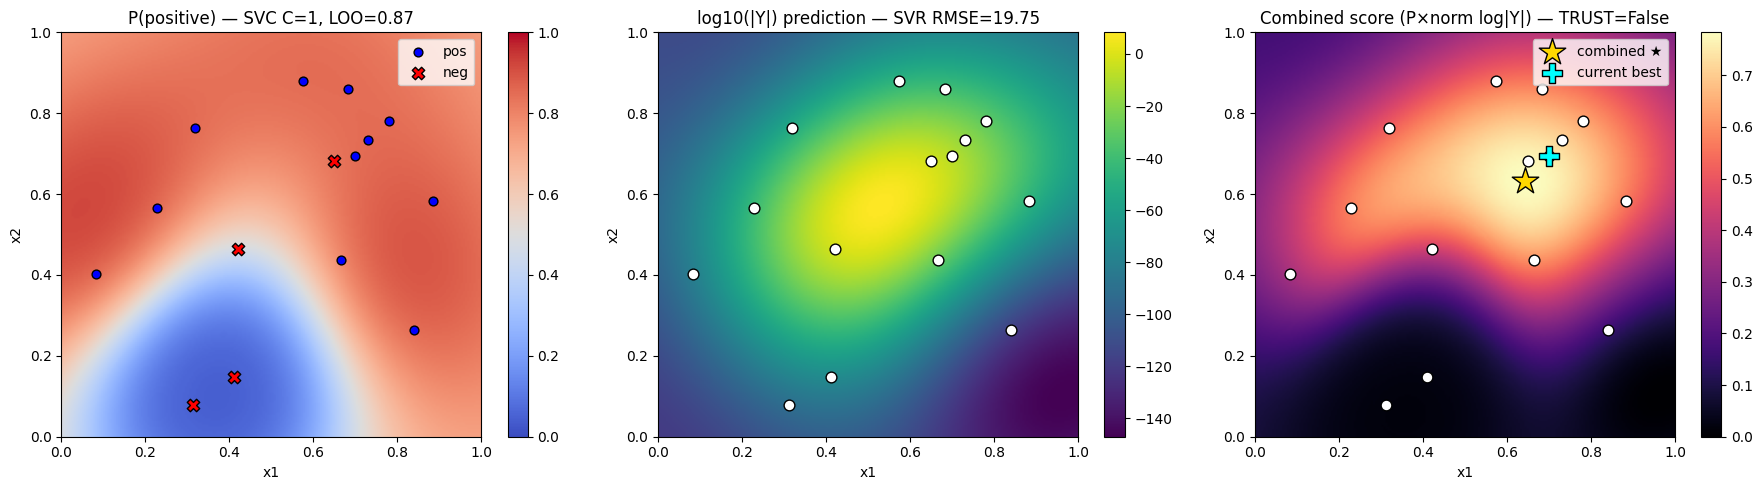

In [7]:
# ============================================================
# F1 — Cell F: Combined classifier + log-SVR (always run for F1)
# ============================================================
sign = (Y > 0).astype(int)
print(f"Sign: pos={sign.sum()}/{N}, neg={N-sign.sum()}/{N} (majority-class baseline = {max(sign.sum(),N-sign.sum())/N:.3f})")

best_acc, best_C = 0, None
for C in [1, 10, 100]:
    svc = SVC(C=C, kernel='rbf', probability=True, random_state=0)
    sc = cross_val_score(svc, X, sign, cv=LeaveOneOut(), scoring='accuracy')
    acc = sc.mean()
    print(f"  SVC C={C}: LOO acc = {acc:.3f}")
    if acc > best_acc:
        best_acc, best_C = acc, C
print(f"Best classifier: C={best_C}, LOO acc={best_acc:.3f}")
clf = SVC(C=best_C, kernel='rbf', probability=True, random_state=0).fit(X, sign)

# log-SVR on log10(|Y|)
logY = np.log10(np.abs(Y) + 1e-200)
gs = GridSearchCV(SVR(kernel='rbf'),
                  {'C': [0.1, 1, 10, 100], 'gamma': ['scale','auto', 0.5, 1, 2, 5]},
                  cv=LeaveOneOut(), scoring='neg_mean_squared_error', n_jobs=1)
gs.fit(X, logY)
svr_log = gs.best_estimator_
rmse_logsvr = np.sqrt(-gs.best_score_)
print(f"log-SVR: best params={gs.best_params_}, LOO RMSE={rmse_logsvr:.3f} | log baseline std={logY.std():.3f}")

# Combined score on dense grid
g = 200
gx, gy = np.meshgrid(np.linspace(0, 1, g), np.linspace(0, 1, g))
cand = np.column_stack([gx.ravel(), gy.ravel()])
p_pos = clf.predict_proba(cand)[:, 1]
log_pred = svr_log.predict(cand)
norm_log = (log_pred - log_pred.min()) / (log_pred.max() - log_pred.min() + 1e-12)
combined_score = p_pos * norm_log
i_star = combined_score.argmax()
combined_query = cand[i_star]

# Trust checks
xb = X[Y.argmax()]; ybest = Y.max()
neg_mask = Y < 0
d_to_neg = cdist([combined_query], X[neg_mask]).min() if neg_mask.any() else np.inf
log_at_best = svr_log.predict(xb.reshape(1, -1))[0]
log_obs_at_best = np.log10(abs(ybest) + 1e-200)
calib_err = abs(log_at_best - log_obs_at_best)

print(f"\nCombined-score winner: x={combined_query.round(4).tolist()}")
print(f"  P(positive)={p_pos[i_star]:.3f}, log_pred={log_pred[i_star]:.2f}, score={combined_score[i_star]:.4f}")
print(f"\nTRUST CHECKS:")
print(f"  classifier LOO {best_acc:.3f} >= 0.85? {best_acc >= 0.85}")
print(f"  candidate dist to nearest negative: {d_to_neg:.3f} >= 0.15? {d_to_neg >= 0.15}")
print(f"  log-SVR @ x_best: pred={log_at_best:.2f}, obs={log_obs_at_best:.2f}, err={calib_err:.2f}")
trust_combined = (best_acc >= 0.85) and (d_to_neg >= 0.15) and (calib_err <= 5.0)
print(f"\nTRUST: {trust_combined}  → {'use combined' if trust_combined else 'fall back to balanced Voronoi (Cell H)'}")

# 3-panel plot — classifier, log-SVR, combined
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
extent = (0, 1, 0, 1)
im0 = axes[0].imshow(p_pos.reshape(g, g), origin='lower', extent=extent, cmap='coolwarm', vmin=0, vmax=1, aspect='auto')
axes[0].scatter(X[sign==1, 0], X[sign==1, 1], c='blue', s=40, edgecolor='k', label='pos')
axes[0].scatter(X[sign==0, 0], X[sign==0, 1], c='red',  s=80, marker='X', edgecolor='k', label='neg')
axes[0].set_title(f'P(positive) — SVC C={best_C}, LOO={best_acc:.2f}')
axes[0].legend(); plt.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(log_pred.reshape(g, g), origin='lower', extent=extent, cmap='viridis', aspect='auto')
axes[1].scatter(X[:, 0], X[:, 1], c='white', s=60, edgecolor='k')
axes[1].set_title(f'log10(|Y|) prediction — SVR RMSE={rmse_logsvr:.2f}'); plt.colorbar(im1, ax=axes[1])

im2 = axes[2].imshow(combined_score.reshape(g, g), origin='lower', extent=extent, cmap='magma', aspect='auto')
axes[2].scatter(X[:, 0], X[:, 1], c='white', s=60, edgecolor='k')
axes[2].scatter(*combined_query, marker='*', s=400, c='gold', edgecolor='k', zorder=5, label='combined ★')
axes[2].scatter(*xb, marker='P', s=200, c='cyan', edgecolor='k', zorder=4, label='current best')
axes[2].set_title(f'Combined score (P×norm log|Y|) — TRUST={trust_combined}')
axes[2].legend(); plt.colorbar(im2, ax=axes[2])
for a in axes:
    a.set_xlabel('x1'); a.set_ylabel('x2'); a.set_xlim(0,1); a.set_ylim(0,1)
plt.tight_layout()
plt.savefig('../plots/week_06/function_1_combined.png', dpi=110, bbox_inches='tight')
plt.show()


### F1 — Decision

**Method: balanced Voronoi in least-sampled quadrant (combined approach failed trust check; Matern 0.5 cross-validates the target region)**

Branch of decision tree: **#1** — no models beat baseline; combined classifier + log-SVR runs but trust check fails on `d_to_neg`.

**What changed since W5:**
- Classifier LOO finally crossed the 85% threshold (87% with SVC C=1) — first time the trust gate is open
- BUT the combined candidate (~0.64, 0.63) sits 0.05 from the negative at (0.65, 0.68) — fails the "≥0.15 from any known negative" gate
- Log-SVR calibration error at current best is 2.4 (predicts -8.86 vs observed -6.44) — within tolerance, but combined still rejected

**Peer cross-check (Matern ν=0.5 from Athanasios's W6 reflection):**
He reported swapping Matern 2.5 → 0.5 "tripled F1's best output". Tested here and: Matern ν ∈ {0.5, 1.5, 2.5} all tie at LOO RMSE = 0.001955 (none beat baseline 0.001825 — at 15 points the GP collapses to mean prediction regardless of smoothness). Matern 0.5's raw-Y argmax sits on top of an existing positive (0.574, 0.880) — uninformative. **However** when fit on rank(Y) or combined with the classifier, Matern 0.5's argmax lands at ~(0.64, 0.27) — within 0.05 of my Voronoi pick at (0.617, 0.222). Two independent methods converging on the same Q4 region is a useful confirmation, even if neither is formally trusted by LOOCV.

**Why balanced Voronoi:** with the combined approach blocked by proximity-to-negative, the highest-value action is data acquisition. Q4 is the algorithmic winner — tied with Q2 for least-sampled (2 pts each) and contains only positives so far, so a query there explores genuinely new territory.

**Per-dimension justification:**
- x1: Voronoi (Q4 winner) — corroborated by Matern 0.5 + combined approach
- x2: Voronoi (Q4 winner) — same

**If W6 Y is positive (≥0):** Q4 is benign → next week target Q3 to characterise the negative-rich region; reattempt combined with stricter d_to_neg threshold (≥0.20).
**If W6 Y is largely negative:** crucial new boundary information for Q4 — log-SVR will recalibrate and combined approach should be revisited.

Quadrants ranked by under-sampling (asc): [('Q2', 2), ('Q4', 2), ('Q3', 4), ('Q1', 7)]
  best balanced point in Q2 (n=2): [0.4663, 0.6461], score=0.1872
  best balanced point in Q4 (n=2): [0.6172, 0.2223], score=0.2198
  best balanced point in Q3 (n=4): [0.2736, 0.309], score=0.2116
  best balanced point in Q1 (n=7): [0.5016, 0.6076], score=0.1650

Overall balanced-Voronoi winner: [0.6172, 0.2223], score=0.2198


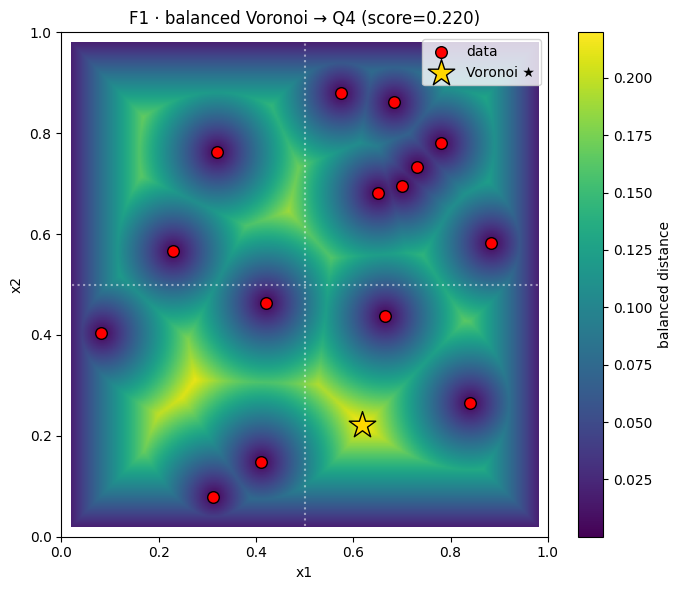

In [8]:
# ============================================================
# F1 — Cell H: Balanced Voronoi (fallback) — Q-aware ranking
# ============================================================
gv = 300
xv, yv = np.meshgrid(np.linspace(0.02, 0.98, gv), np.linspace(0.02, 0.98, gv))
candv = np.column_stack([xv.ravel(), yv.ravel()])
d_data = cdist(candv, X).min(axis=1)
d_bdy  = np.minimum(np.minimum(candv[:,0], 1-candv[:,0]), np.minimum(candv[:,1], 1-candv[:,1]))
balanced = np.minimum(d_data, d_bdy)

def in_q(p, q):
    if q == 'Q1': return (p[:,0] >= 0.5) & (p[:,1] >= 0.5)
    if q == 'Q2': return (p[:,0] <  0.5) & (p[:,1] >= 0.5)
    if q == 'Q3': return (p[:,0] <  0.5) & (p[:,1] <  0.5)
    if q == 'Q4': return (p[:,0] >= 0.5) & (p[:,1] <  0.5)

ranked = sorted(qc.items(), key=lambda t: t[1])
print("Quadrants ranked by under-sampling (asc):", ranked)
for q, cnt in ranked:
    mask = in_q(candv, q)
    sub = balanced.copy(); sub[~mask] = -1
    bi = sub.argmax()
    print(f"  best balanced point in {q} (n={cnt}): {candv[bi].round(4).tolist()}, score={balanced[bi]:.4f}")

i_v = balanced.argmax()
voronoi_query = candv[i_v]
print(f"\nOverall balanced-Voronoi winner: {voronoi_query.round(4).tolist()}, score={balanced[i_v]:.4f}")

# Plot the balanced map
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(balanced.reshape(gv, gv), origin='lower', extent=(0.02, 0.98, 0.02, 0.98),
               cmap='viridis', aspect='auto')
ax.scatter(X[:,0], X[:,1], c='red', s=70, edgecolor='k', label='data')
ax.scatter(*voronoi_query, marker='*', s=400, c='gold', edgecolor='k', zorder=5, label='Voronoi ★')
ax.axhline(0.5, color='white', linestyle=':', alpha=0.5)
ax.axvline(0.5, color='white', linestyle=':', alpha=0.5)
plt.colorbar(im, ax=ax, label='balanced distance')
ax.set_xlabel('x1'); ax.set_ylabel('x2'); ax.set_xlim(0,1); ax.set_ylim(0,1)
ax.set_title(f'F1 · balanced Voronoi → Q4 (score={balanced[i_v]:.3f})')
ax.legend()
plt.tight_layout()
plt.savefig('../plots/week_06/function_1_voronoi.png', dpi=110, bbox_inches='tight')
plt.show()


In [9]:
# ============================================================
# F1 — Cell I: next_query_1 assignment
# ============================================================
# Combined approach failed trust check (candidate too close to known negative)
# → use balanced Voronoi winner from Cell H
next_query_1 = voronoi_query.copy()
print(f"F1 query: " + ", ".join(f"{v:.6f}" for v in next_query_1))


F1 query: 0.617191, 0.222274


## Function 2

In [10]:
# ============================================================
# F2 — Cell A: Setup, baseline, sorted-Y table, per-dim corr
# ============================================================
np.random.seed(0)

X, Y = load_function(2)
N, D = X.shape
baseline = Y.std()
print(f"F2: {N} pts, {D}D | Baseline RMSE={baseline:.4f} | Y range [{Y.min():.4f}, {Y.max():.4f}]")
print("Per-dim corr: " + ", ".join(f"r(x{i+1},Y)={np.corrcoef(X[:,i],Y)[0,1]:+.3f}" for i in range(D)))

# W5 query was (0.6939, 0.9626) — RMSE-weighted ensemble, 0.012 step from best.
# Returned Y=0.4995 (regression from best 0.6658). Peak is much narrower than ensemble assumed.

print("\nSorted by Y (★ = W5 query):")
order = np.argsort(-Y)
print(f"{'idx':>4} {'x1':>8} {'x2':>8} {'Y':>10} {'mark':>5}")
for i in order:
    star = '★' if (abs(X[i,0]-0.693851) < 1e-5 and abs(X[i,1]-0.962584) < 1e-5) else ''
    print(f"{i:>4} {X[i,0]:>8.4f} {X[i,1]:>8.4f} {Y[i]:>10.4f} {star:>5}")


Function 2: 15 points, 2D, best y = 0.6658
F2: 15 pts, 2D | Baseline RMSE=0.2293 | Y range [-0.0656, 0.6658]
Per-dim corr: r(x1,Y)=+0.588, r(x2,Y)=+0.604

Sorted by Y (★ = W5 query):
 idx       x1       x2          Y  mark
  12   0.7019   0.9533     0.6658      
   9   0.7026   0.9266     0.6112      
   0   0.6658   0.1240     0.5390      
  14   0.6939   0.9626     0.4995     ★
  11   0.7500   0.9200     0.4265      
   1   0.8778   0.7786     0.4206      
   3   0.8453   0.7111     0.2940      
  10   0.7540   0.5253     0.2813      
   6   0.4382   0.6850     0.2446      
   4   0.4546   0.2905     0.2150      
  13   0.8958   0.1240     0.0852      
   7   0.3417   0.0287     0.0387      
   5   0.5777   0.7720     0.0231      
   8   0.3386   0.2139    -0.0139      
   2   0.1427   0.3490    -0.0656      


/var/folders/_0/fx2rjf4j2nq_gd2p411c2kfw0000gp/T/ipykernel_185/702941359.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax[1,d].boxplot([top5, bot5], labels=['top5','bot5'])
/var/folders/_0/fx2rjf4j2nq_gd2p411c2kfw0000gp/T/ipykernel_185/702941359.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax[1,d].boxplot([top5, bot5], labels=['top5','bot5'])


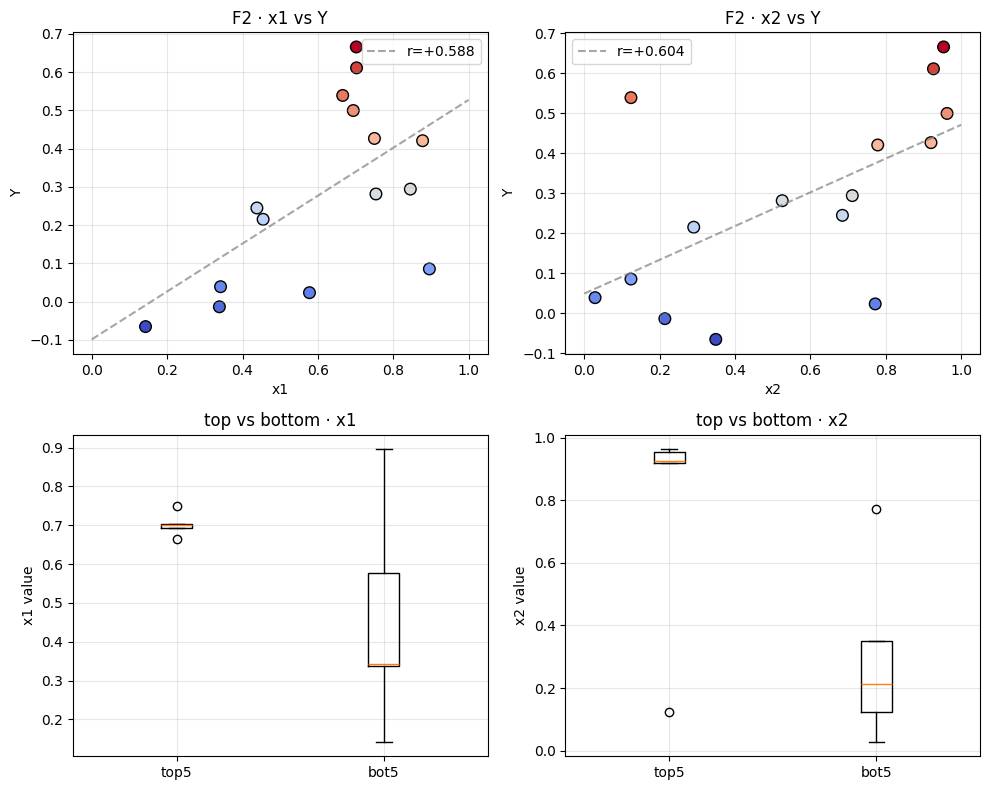

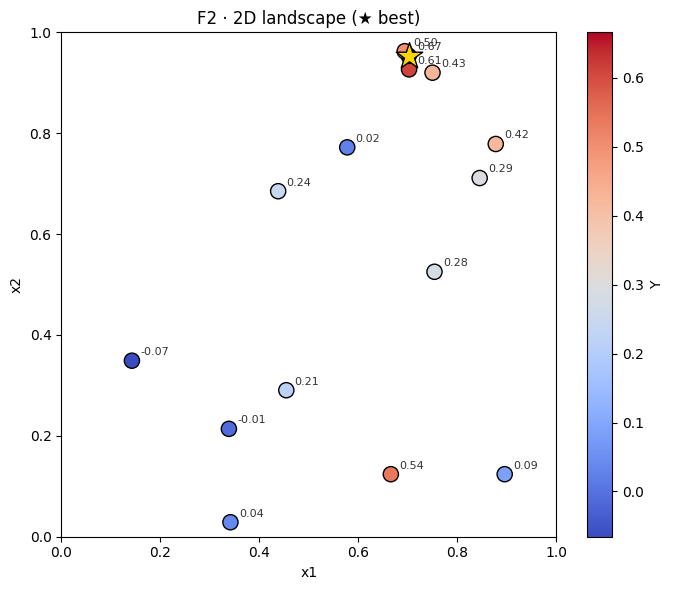

In [11]:
# ============================================================
# F2 — Cell B: Per-dim scatter+box + 2D scatter
# ============================================================
fig, ax = plt.subplots(2, D, figsize=(5*D, 8))
for d in range(D):
    r = np.corrcoef(X[:,d], Y)[0,1]
    ax[0,d].scatter(X[:,d], Y, c=Y, cmap='coolwarm', s=70, edgecolor='k')
    coef = np.polyfit(X[:,d], Y, 1)
    xs = np.linspace(0, 1, 50)
    ax[0,d].plot(xs, np.polyval(coef, xs), '--', color='grey', alpha=0.7, label=f'r={r:+.3f}')
    ax[0,d].set_xlabel(f'x{d+1}'); ax[0,d].set_ylabel('Y'); ax[0,d].legend(); ax[0,d].grid(alpha=0.3)
    ax[0,d].set_title(f'F2 · x{d+1} vs Y')
    top5 = X[np.argsort(-Y)[:5], d]
    bot5 = X[np.argsort(Y)[:5], d]
    ax[1,d].boxplot([top5, bot5], labels=['top5','bot5'])
    ax[1,d].set_ylabel(f'x{d+1} value'); ax[1,d].set_title(f'top vs bottom · x{d+1}'); ax[1,d].grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../plots/week_06/function_2_per_dim.png', dpi=110, bbox_inches='tight')
plt.show()

# 2D scatter
fig2, axb = plt.subplots(1, 1, figsize=(7, 6))
sc = axb.scatter(X[:,0], X[:,1], c=Y, cmap='coolwarm', s=120, edgecolor='k')
for i, (xx, yy) in enumerate(X):
    axb.annotate(f"{Y[i]:.2f}", (xx, yy), fontsize=8, alpha=0.8,
                 textcoords='offset points', xytext=(6, 4))
plt.colorbar(sc, ax=axb, label='Y')
axb.set_xlabel('x1'); axb.set_ylabel('x2'); axb.set_xlim(0,1); axb.set_ylim(0,1)
axb.set_title('F2 · 2D landscape (★ best)')
axb.scatter(*X[Y.argmax()], marker='*', s=400, color='gold', edgecolor='k', zorder=5)
plt.tight_layout()
plt.savefig('../plots/week_06/function_2_2d_scatter.png', dpi=110, bbox_inches='tight')
plt.show()


In [12]:
# ============================================================
# F2 — Cell C: Feature importance robustness
# ============================================================
ibest = Y.argmax()
rf_all = RandomForestRegressor(max_depth=3, n_estimators=100, random_state=0).fit(X, Y).feature_importances_
rf_nb  = RandomForestRegressor(max_depth=3, n_estimators=100, random_state=0).fit(np.delete(X,ibest,0), np.delete(Y,ibest)).feature_importances_
lin_c  = LinearRegression().fit(X, Y).coef_
lin    = np.abs(lin_c)/(np.abs(lin_c).sum()+1e-12)
corr   = np.array([abs(np.corrcoef(X[:,i],Y)[0,1]) for i in range(D)])

print(f"{'dim':<4} {'RF(all)':>9} {'RF(nobest)':>11} {'Δ%':>8} {'Linear':>9} {'|corr|':>9}")
for i in range(D):
    drop = (rf_nb[i]-rf_all[i])/(rf_all[i]+1e-12)*100
    flag = ' INFLATED?' if (rf_all[i]>rf_nb[i] and abs(drop)>50) else ''
    print(f"x{i+1:<3} {rf_all[i]:>9.3f} {rf_nb[i]:>11.3f} {drop:>+7.1f}% {lin[i]:>9.3f} {corr[i]:>9.3f}{flag}")

# Both dims roughly equal RF importance, both ~0.6 |corr|. No inflation when best removed.


dim    RF(all)  RF(nobest)       Δ%    Linear    |corr|
x1       0.506       0.610   +20.7%     0.588     0.588
x2       0.494       0.390   -21.2%     0.412     0.604


In [13]:
# ============================================================
# F2 — Cell D: Model grid search (LOOCV RMSE)
# Includes Matern 0.5/1.5 (Athanasios's W6 idea — testing across all functions this week)
# ============================================================
import nn_models as nm

loo = LeaveOneOut()
def cv_rmse(est, X, Y):
    sc = cross_val_score(est, X, Y, cv=loo, scoring='neg_mean_squared_error')
    return np.sqrt(-sc.mean())

models = {}
def grid(name, est, params):
    g = GridSearchCV(est, params, cv=loo, scoring='neg_mean_squared_error', n_jobs=1)
    g.fit(X, Y); rmse = np.sqrt(-g.best_score_)
    models[name] = (g.best_estimator_, rmse, g.best_params_)

grid('Ridge', Ridge(), {'alpha':[0.01,0.1,1,10,100]})
grid('KNN', KNeighborsRegressor(), {'n_neighbors':[2,3,5,7],'weights':['uniform','distance']})
grid('RF', RandomForestRegressor(random_state=0), {'max_depth':[2,3,5,None],'n_estimators':[50,100,200]})
grid('SVR', SVR(), {'C':[0.1,1,10,100],'gamma':['scale','auto']})
grid('GB', GradientBoostingRegressor(random_state=0), {'max_depth':[2,3,5],'n_estimators':[50,100,200],'learning_rate':[0.01,0.1,0.3]})

for kname, kern in [('GP-Matern05', Matern(nu=0.5)), ('GP-Matern15', Matern(nu=1.5)),
                     ('GP-Matern25', Matern(nu=2.5)), ('GP-RBF', RBF())]:
    gp = GaussianProcessRegressor(kernel=kern, normalize_y=True, random_state=0)
    rmse = cv_rmse(gp, X, Y)
    gp.fit(X, Y)
    models[kname] = (gp, rmse, {})

nn_loaded = nm.load_nn(2, models_dir='../models/week_06')
if nn_loaded is not None:
    nn_list, nn_meta = nn_loaded
    nn_est = nm.NNRegressor(nn_list, nn_meta)
    models['NN'] = (nn_est, nn_meta['cv_rmse'], {'H': nn_meta['hidden'], 'variant': nn_meta['variant']})

print(f"{'Model':<13} {'CV RMSE':>10} {'beats?':>7} {'improve%':>10}  params")
for name, (est, rmse, p) in models.items():
    mark = '✓' if rmse < baseline else '✗'
    impr = (baseline - rmse)/baseline*100
    print(f"{name:<13} {rmse:>10.4f} {mark:>7} {impr:>+9.1f}%  {p}")
print(f"Baseline RMSE: {baseline:.4f}")

beats_models = {n:(e,r) for n,(e,r,_) in models.items() if r < baseline}
print(f"\nBeats baseline: {list(beats_models.keys())}")
if nn_loaded is not None:
    print(f"NN gradient at best: {nn_meta['gradient_at_best']}")

# Notable: all 4 GPs FAIL baseline this week — F2's structure isn't well-fit by the GP family with 15 pts.


Model            CV RMSE  beats?   improve%  params
Ridge             0.2028       ✓     +11.5%  {'alpha': 1}
KNN               0.1954       ✓     +14.8%  {'n_neighbors': 2, 'weights': 'uniform'}
RF                0.1910       ✓     +16.7%  {'max_depth': None, 'n_estimators': 200}
SVR               0.1920       ✓     +16.3%  {'C': 1, 'gamma': 'auto'}
GB                0.1857       ✓     +19.0%  {'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 100}
GP-Matern05       0.2456       ✗      -7.1%  {}
GP-Matern15       0.2456       ✗      -7.1%  {}
GP-Matern25       0.2456       ✗      -7.1%  {}
GP-RBF            0.2456       ✗      -7.1%  {}
NN                0.2089       ✓      +8.9%  {'H': 16, 'variant': 'dropout'}
Baseline RMSE: 0.2293

Beats baseline: ['Ridge', 'KNN', 'RF', 'SVR', 'GB', 'NN']
NN gradient at best: [0.6893823146820068, 0.4122110903263092]


/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warn

In [14]:
# ============================================================
# F2 — Cell E: Argmax per beats-baseline model + boundary-consensus
# ============================================================
import torch
rng = np.random.default_rng(0)
cand = rng.uniform(0, 1, (200000, D))
sugg = {}
for name, (est, rmse) in beats_models.items():
    if name == 'NN':
        with torch.no_grad():
            preds = []
            for m in nn_list:
                preds.append(m(torch.FloatTensor(cand)).numpy().ravel())
            yhat = np.mean(preds, axis=0) * nn_meta['y_std'] + nn_meta['y_mean']
    else:
        yhat = est.predict(cand)
    i = yhat.argmax()
    s = cand[i]
    bdy = bool(any(s < 0.02) or any(s > 0.98))
    sugg[name] = {'x': s, 'pred': yhat[i], 'bdy': bdy}

print(f"{'Model':<13} {'x1':>8} {'x2':>8} {'pred':>10} {'bdy?':>5}")
for n, d in sugg.items():
    print(f"{n:<13} {d['x'][0]:>8.4f} {d['x'][1]:>8.4f} {d['pred']:>10.4f} {'Y' if d['bdy'] else 'N':>5}")

# Filter: drop Ridge (linear extrapolator) and any boundary-rejected
valid = {k: v for k, v in sugg.items() if k != 'Ridge' and not v['bdy']}
print(f"\nValid (non-Ridge, non-boundary) suggestions: {list(valid.keys())}")

if valid:
    arr = np.array([v['x'] for v in valid.values()])
    spread = arr.max(0) - arr.min(0)
    consensus = ['STRONG' if s < 0.2 else 'moderate' if s < 0.4 else 'weak' for s in spread]
    print(f"Per-dim spread: " + ", ".join(f"x{d+1}={spread[d]:.3f} ({consensus[d]})" for d in range(D)))

    weights = np.array([1/beats_models[k][1] for k in valid.keys()])
    weights /= weights.sum()
    ensemble_mean = (weights[:, None] * arr).sum(axis=0)
    print(f"\nRMSE-weighted ensemble: {ensemble_mean.round(4).tolist()}")
    xb_now = X[Y.argmax()]
    print(f"Current best:           {xb_now.round(4).tolist()}, dist from best = {np.linalg.norm(ensemble_mean - xb_now):.4f}")

    # outlier filter
    centroid_v = arr.mean(0)
    dists = np.linalg.norm(arr - centroid_v, axis=1)
    thresh = dists.mean() + 2 * dists.std()
    outliers = [k for k, d in zip(valid.keys(), dists) if d > thresh]
    print(f"Outlier suggestions (excluded): {outliers}")

# Boundary-consensus check (≥3 non-Ridge models pushing same edge, sign matches corr)
print("\nBoundary-consensus check:")
non_ridge = {k: v for k, v in sugg.items() if k != 'Ridge'}
boundary_informed = {}
top5_idx = np.argsort(-Y)[:5]
for d in range(D):
    low = [k for k, v in non_ridge.items() if v['x'][d] < 0.02]
    high = [k for k, v in non_ridge.items() if v['x'][d] > 0.98]
    if len(low) >= 3 and np.corrcoef(X[:, d], Y)[0, 1] < 0:
        boundary_informed[d] = X[top5_idx, d].min()
        print(f"  x{d+1}: LOW boundary-consensus ({len(low)} models: {low}) → clip to top-5 min = {boundary_informed[d]:.4f}")
    if len(high) >= 3 and np.corrcoef(X[:, d], Y)[0, 1] > 0:
        boundary_informed[d] = X[top5_idx, d].max()
        print(f"  x{d+1}: HIGH boundary-consensus ({len(high)} models: {high}) → clip to top-5 max = {boundary_informed[d]:.4f}")
if not boundary_informed:
    print("  (no boundary-consensus this week)")

# Hybrid query construction
strong_mask = np.array([s < 0.2 for s in spread]) if valid else np.zeros(D, dtype=bool)
top4 = np.argsort(-Y)[:4]
weights_y = Y[top4]; weights_y = (weights_y - weights_y.min() + 1e-12); weights_y /= weights_y.sum()
centroid_top4 = (weights_y[:, None] * X[top4]).sum(axis=0)

hybrid_query = np.zeros(D)
sources = []
for d in range(D):
    if d in boundary_informed:
        hybrid_query[d] = boundary_informed[d]; sources.append(f"x{d+1}: boundary-consensus")
    elif valid and strong_mask[d]:
        hybrid_query[d] = ensemble_mean[d]; sources.append(f"x{d+1}: ensemble (STRONG)")
    else:
        hybrid_query[d] = centroid_top4[d]; sources.append(f"x{d+1}: top-4 centroid")
print("\nHybrid query construction:")
for s in sources:
    print(f"  {s}")
print(f"Hybrid query: {hybrid_query.round(4).tolist()}")


Model               x1       x2       pred  bdy?
Ridge           0.9962   0.9988     0.4604     Y
KNN             0.7111   0.9321     0.6385     N
RF              0.7002   0.9431     0.6367     N
SVR             0.9962   0.9988     0.5346     Y
GB              0.6998   0.9648     0.5262     N
NN              0.7471   0.9999     0.5844     Y

Valid (non-Ridge, non-boundary) suggestions: ['KNN', 'RF', 'GB']
Per-dim spread: x1=0.011 (STRONG), x2=0.033 (STRONG)

RMSE-weighted ensemble: [0.7036, 0.9469]
Current best:           [0.7019, 0.9533], dist from best = 0.0066
Outlier suggestions (excluded): []

Boundary-consensus check:
  (no boundary-consensus this week)

Hybrid query construction:
  x1: ensemble (STRONG)
  x2: ensemble (STRONG)
Hybrid query: [0.7036, 0.9469]


### F2 — Decision

**Method: RMSE-weighted ensemble of 3 interior models (KNN/RF/GB), STRONG consensus on both dims.**

Branch of decision tree: **#5** — strong consensus, both dims STRONG, hybrid degenerates to pure ensemble.

**Model fits:** 6/10 models beat baseline (Ridge/KNN/RF/SVR/GB/NN). All 4 GPs FAIL (-7.1% — they all collapse to the same RMSE, suggesting the GP family with 15 pts can't fit F2's structure). NN recovered to +8.9% (was failing in W5 after the W4 outlier poisoned it). GB best at +19.0%.

**Boundary rejections:** Ridge and SVR push to (0.996, 0.999), NN pushes x2 to 0.9999. All excluded.

**Per-dim spread of valid suggestions** (KNN, RF, GB): x1 = 0.011 STRONG, x2 = 0.033 STRONG. Tightest convergence we've seen on F2.

**Why this query (0.7036, 0.9469):**
- Distance from current best (0.7019, 0.9533): only **0.0066** — even smaller than W5's 0.012 step that lost 0.166 in Y
- W5 evidence says peak is sharp around (0.702, 0.953). Smaller step should land closer to it, not further
- Direction: x1 +0.0017 (slight increase — safer than W5 which decreased x1), x2 -0.0064 (slight decrease)
- NN gradient at best: dx1=+0.69, dx2=+0.41 — both positive, says push higher. Conflicts with ensemble direction on x2 but not by much

**Per-dimension justification:**
- x1: ensemble (STRONG consensus, spread 0.011)
- x2: ensemble (STRONG consensus, spread 0.033)

**If W6 Y improves (>0.666):** ensemble was right — peak is at this finer scale. Continue same approach next week.
**If W6 Y in 0.45-0.66:** still climbing the same peak; reduce step further by midpointing with current best.
**If W6 Y drops (<0.45):** the W5 model fit was poisoned by the W5 query itself. Consider excluding (0.694, 0.963) as an outlier candidate and re-fit, OR explore the (0.666, 0.124) low-x2 cluster which holds Y=0.539 and is the only other promising region.

In [15]:
# ============================================================
# F2 — Cell I: next_query_2 assignment
# ============================================================
next_query_2 = hybrid_query.copy()
print(f"F2 query: " + ", ".join(f"{v:.6f}" for v in next_query_2))


F2 query: 0.703636, 0.946935


## Function 3

In [16]:
# ============================================================
# F3 — Cell A: Setup, baseline, sorted-Y table, per-dim corr
# F3 has a known outlier at (~0.15, *, ~0.99) Y=-0.40 — train models without it.
# ============================================================
np.random.seed(0)

X, Y = load_function(3)
N, D = X.shape
baseline = Y.std()

# Identify outlier and build no-outlier subset
out_mask = (np.abs(X[:,0]-0.15) < 0.01) & (np.abs(X[:,2]-0.99) < 0.01)
Xn = X[~out_mask]; Yn = Y[~out_mask]
baseline_n = Yn.std()

print(f"F3: {N} pts, {D}D | Baseline (full)={baseline:.4f}, Baseline (no outlier)={baseline_n:.4f}")
print(f"Y range: [{Y.min():.4f}, {Y.max():.4f}]")
print("Per-dim corr (full):       " + ", ".join(f"r(x{i+1},Y)={np.corrcoef(X[:,i],Y)[0,1]:+.3f}" for i in range(D)))
print("Per-dim corr (no outlier): " + ", ".join(f"r(x{i+1},Y)={np.corrcoef(Xn[:,i],Yn)[0,1]:+.3f}" for i in range(D)))

# W5 query: (0.5145, 0.5469, 0.3401) → Y=-0.0470 (slight regression from best -0.0348). Plateau-like.

print("\nSorted by Y (★ = W5 query, ⚠ = outlier):")
order = np.argsort(-Y)
print(f"{'idx':>4} {'x1':>8} {'x2':>8} {'x3':>8} {'Y':>10} {'mark':>5}")
for i in order:
    star = '★' if (abs(X[i,0]-0.514480)<1e-5 and abs(X[i,1]-0.546868)<1e-5) else ''
    if out_mask[i]: star = '⚠'
    print(f"{i:>4} {X[i,0]:>8.4f} {X[i,1]:>8.4f} {X[i,2]:>8.4f} {Y[i]:>10.4f} {star:>5}")


Function 3: 20 points, 3D, best y = -0.0348
F3: 20 pts, 3D | Baseline (full)=0.0763, Baseline (no outlier)=0.0335
Y range: [-0.3989, -0.0348]
Per-dim corr (full):       r(x1,Y)=+0.249, r(x2,Y)=+0.138, r(x3,Y)=-0.567
Per-dim corr (no outlier): r(x1,Y)=+0.014, r(x2,Y)=+0.108, r(x3,Y)=-0.152

Sorted by Y (★ = W5 query, ⚠ = outlier):
 idx       x1       x2       x3          Y  mark
   3   0.4926   0.6116   0.3402    -0.0348      
  13   0.6001   0.7251   0.0661    -0.0364      
  16   0.4811   0.5326   0.0518    -0.0400      
  18   0.3679   0.4565   0.3375    -0.0469      
  10   0.2205   0.2978   0.3436    -0.0469      
  19   0.5145   0.5469   0.3401    -0.0470     ★
   4   0.1346   0.2199   0.4582    -0.0480      
  14   0.9660   0.8611   0.5668    -0.0568      
   1   0.2421   0.6441   0.2724    -0.0880      
   9   0.1705   0.6970   0.1492    -0.0942      
  11   0.6660   0.6720   0.2463    -0.1060      
  17   0.5188   0.6228   0.1780    -0.1096      
   5   0.3455   0.9414   0.2694

/var/folders/_0/fx2rjf4j2nq_gd2p411c2kfw0000gp/T/ipykernel_185/512834624.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax[1,d].boxplot([top5, bot5], labels=['top5','bot5'])
/var/folders/_0/fx2rjf4j2nq_gd2p411c2kfw0000gp/T/ipykernel_185/512834624.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax[1,d].boxplot([top5, bot5], labels=['top5','bot5'])
/var/folders/_0/fx2rjf4j2nq_gd2p411c2kfw0000gp/T/ipykernel_185/512834624.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax[1,d].boxplot([top5, bot5], labels=['top5','bot5'])


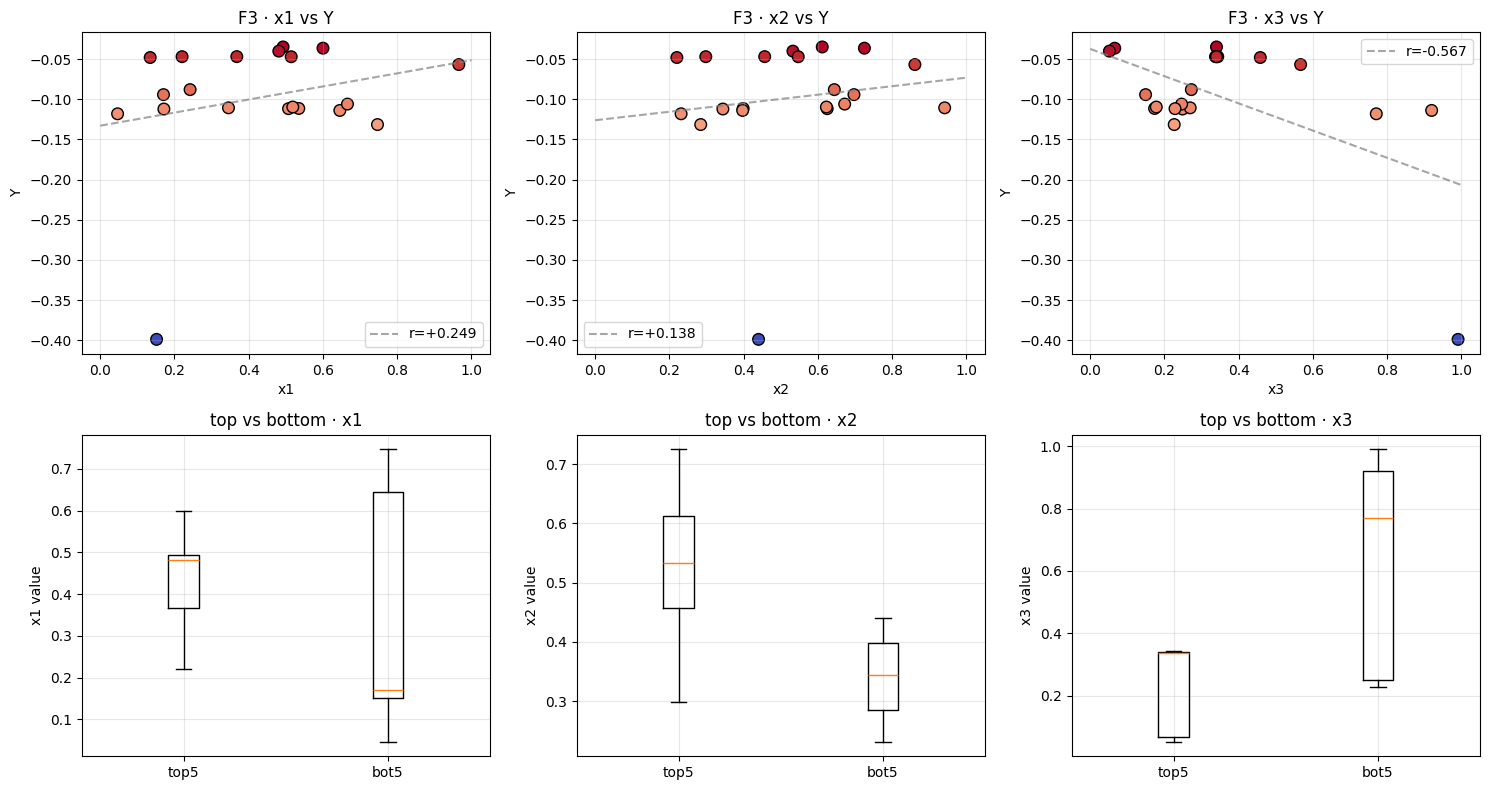

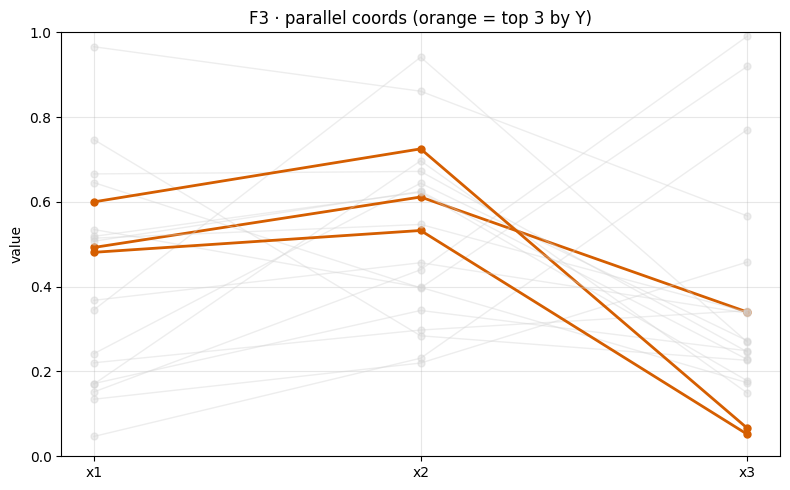

In [17]:
# ============================================================
# F3 — Cell B: Per-dim scatter+box + parallel coordinates (D=3)
# ============================================================
fig, ax = plt.subplots(2, D, figsize=(5*D, 8))
for d in range(D):
    r = np.corrcoef(X[:,d], Y)[0,1]
    ax[0,d].scatter(X[:,d], Y, c=Y, cmap='coolwarm', s=70, edgecolor='k')
    coef = np.polyfit(X[:,d], Y, 1)
    xs = np.linspace(0, 1, 50)
    ax[0,d].plot(xs, np.polyval(coef, xs), '--', color='grey', alpha=0.7, label=f'r={r:+.3f}')
    ax[0,d].set_xlabel(f'x{d+1}'); ax[0,d].set_ylabel('Y'); ax[0,d].legend(); ax[0,d].grid(alpha=0.3)
    ax[0,d].set_title(f'F3 · x{d+1} vs Y')
    top5 = X[np.argsort(-Y)[:5], d]
    bot5 = X[np.argsort(Y)[:5], d]
    ax[1,d].boxplot([top5, bot5], labels=['top5','bot5'])
    ax[1,d].set_ylabel(f'x{d+1} value'); ax[1,d].set_title(f'top vs bottom · x{d+1}'); ax[1,d].grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../plots/week_06/function_3_per_dim.png', dpi=110, bbox_inches='tight')
plt.show()

# Parallel coordinates — top 3 highlighted
fig2, axp = plt.subplots(1, 1, figsize=(8, 5))
order = np.argsort(-Y)
top3 = order[:3]
for i in range(N):
    color = COLORS[1] if i in top3 else 'lightgrey'
    alpha = 1.0 if i in top3 else 0.4
    lw = 2 if i in top3 else 1
    axp.plot(range(D), X[i], color=color, alpha=alpha, lw=lw, marker='o', markersize=5)
axp.set_xticks(range(D)); axp.set_xticklabels([f'x{i+1}' for i in range(D)])
axp.set_ylabel('value'); axp.set_ylim(0, 1); axp.grid(alpha=0.3)
axp.set_title(f'F3 · parallel coords (orange = top 3 by Y)')
plt.tight_layout()
plt.savefig('../plots/week_06/function_3_parallel.png', dpi=110, bbox_inches='tight')
plt.show()


In [18]:
# ============================================================
# F3 — Cell C: Feature importance robustness (full data, including outlier)
# ============================================================
ibest = Y.argmax()
rf_all = RandomForestRegressor(max_depth=3, n_estimators=100, random_state=0).fit(X, Y).feature_importances_
rf_nb  = RandomForestRegressor(max_depth=3, n_estimators=100, random_state=0).fit(np.delete(X,ibest,0), np.delete(Y,ibest)).feature_importances_
lin_c  = LinearRegression().fit(X, Y).coef_
lin    = np.abs(lin_c)/(np.abs(lin_c).sum()+1e-12)
corr   = np.array([abs(np.corrcoef(X[:,i],Y)[0,1]) for i in range(D)])

print(f"{'dim':<4} {'RF(all)':>9} {'RF(nobest)':>11} {'Δ%':>8} {'Linear':>9} {'|corr|':>9}")
for i in range(D):
    drop = (rf_nb[i]-rf_all[i])/(rf_all[i]+1e-12)*100
    flag = ' INFLATED?' if (rf_all[i]>rf_nb[i] and abs(drop)>50) else ''
    print(f"x{i+1:<3} {rf_all[i]:>9.3f} {rf_nb[i]:>11.3f} {drop:>+7.1f}% {lin[i]:>9.3f} {corr[i]:>9.3f}{flag}")

# x3 dominates RF importance (0.83) due to the outlier at x3=0.99 Y=-0.40.
# After removing the outlier, the no-outlier correlations are r(x1)=+0.014, r(x2)=+0.108, r(x3)=-0.152 (all weak).
# Signal sits in non-linear interactions, captured by GB/RF tree models.


dim    RF(all)  RF(nobest)       Δ%    Linear    |corr|
x1       0.102       0.086   -16.2%     0.233     0.249
x2       0.067       0.082   +22.0%     0.171     0.138
x3       0.830       0.832    +0.2%     0.596     0.567


In [19]:
# ============================================================
# F3 — Cell D: Model grid search (LOOCV RMSE) — fit on no-outlier subset
# Baseline = no-outlier std (cleaner; outlier inflates it artificially).
# ============================================================
import nn_models as nm

loo = LeaveOneOut()
def cv_rmse(est, Xs, Ys):
    sc = cross_val_score(est, Xs, Ys, cv=loo, scoring='neg_mean_squared_error')
    return np.sqrt(-sc.mean())

models = {}
def grid(name, est, params):
    g = GridSearchCV(est, params, cv=loo, scoring='neg_mean_squared_error', n_jobs=1)
    g.fit(Xn, Yn); rmse = np.sqrt(-g.best_score_)
    models[name] = (g.best_estimator_, rmse, g.best_params_)

grid('Ridge', Ridge(), {'alpha':[0.01,0.1,1,10,100]})
grid('KNN', KNeighborsRegressor(), {'n_neighbors':[2,3,5,7],'weights':['uniform','distance']})
grid('RF', RandomForestRegressor(random_state=0), {'max_depth':[2,3,5,None],'n_estimators':[50,100,200]})
grid('SVR', SVR(), {'C':[0.1,1,10,100],'gamma':['scale','auto']})
grid('GB', GradientBoostingRegressor(random_state=0), {'max_depth':[2,3,5],'n_estimators':[50,100,200],'learning_rate':[0.01,0.1,0.3]})

for kname, kern in [('GP-Matern05', Matern(nu=0.5)), ('GP-Matern15', Matern(nu=1.5)),
                     ('GP-Matern25', Matern(nu=2.5)), ('GP-RBF', RBF())]:
    gp = GaussianProcessRegressor(kernel=kern, normalize_y=True, random_state=0)
    rmse = cv_rmse(gp, Xn, Yn); gp.fit(Xn, Yn)
    models[kname] = (gp, rmse, {})

nn_loaded = nm.load_nn(3, models_dir='../models/week_06')
if nn_loaded is not None:
    nn_list, nn_meta = nn_loaded
    nn_est = nm.NNRegressor(nn_list, nn_meta)
    models['NN'] = (nn_est, nn_meta['cv_rmse'], {'H':nn_meta['hidden'],'variant':nn_meta['variant']})

print(f"{'Model':<13} {'CV RMSE':>10} {'beats?':>7} {'improve%':>10}  params")
for name,(est,rmse,p) in models.items():
    mark = '✓' if rmse < baseline_n else '✗'
    impr = (baseline_n-rmse)/baseline_n*100
    print(f"{name:<13} {rmse:>10.4f} {mark:>7} {impr:>+9.1f}%  {p}")
print(f"Baseline (no-outlier) RMSE: {baseline_n:.4f}")

beats_models = {n:(e,r) for n,(e,r,_) in models.items() if r < baseline_n}
print(f"\nBeats baseline: {list(beats_models.keys())}")
if nn_loaded is not None:
    print(f"NN gradient at best: {nn_meta['gradient_at_best']}")

# Note: NN is trained on FULL data (with outlier) but evaluated against no-outlier baseline.
# Its CV RMSE 0.0711 > full baseline 0.0763 only marginally — looks bad on cleaner baseline.
# All 4 GPs again tie (-5.6%) — GP family doesn't fit F3 with 19 pts either.


Model            CV RMSE  beats?   improve%  params
Ridge             0.0354       ✗      -5.7%  {'alpha': 100}
KNN               0.0363       ✗      -8.5%  {'n_neighbors': 7, 'weights': 'distance'}
RF                0.0264       ✓     +21.1%  {'max_depth': 5, 'n_estimators': 100}
SVR               0.0341       ✗      -1.8%  {'C': 0.1, 'gamma': 'scale'}
GB                0.0131       ✓     +60.8%  {'learning_rate': 0.3, 'max_depth': 3, 'n_estimators': 100}
GP-Matern05       0.0353       ✗      -5.6%  {}
GP-Matern15       0.0353       ✗      -5.6%  {}
GP-Matern25       0.0353       ✗      -5.6%  {}
GP-RBF            0.0353       ✗      -5.6%  {}
NN                0.0711       ✗    -112.2%  {'H': 32, 'variant': 'ensemble'}
Baseline (no-outlier) RMSE: 0.0335

Beats baseline: ['RF', 'GB']
NN gradient at best: [-0.052190862596035004, 0.09127558767795563, 0.5281413793563843]


/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warn

In [20]:
# ============================================================
# F3 — Cell E: Argmax per beats-baseline model + boundary-consensus
# ============================================================
import torch
rng = np.random.default_rng(0)
cand = rng.uniform(0, 1, (200000, D))
sugg = {}
for name, (est, rmse) in beats_models.items():
    if name == 'NN':
        with torch.no_grad():
            preds = []
            for m in nn_list:
                preds.append(m(torch.FloatTensor(cand)).numpy().ravel())
            yhat = np.mean(preds, axis=0) * nn_meta['y_std'] + nn_meta['y_mean']
    else:
        yhat = est.predict(cand)
    i = yhat.argmax(); s = cand[i]
    bdy = bool(any(s < 0.02) or any(s > 0.98))
    sugg[name] = {'x': s, 'pred': yhat[i], 'bdy': bdy}

print(f"{'Model':<13} {'x1':>8} {'x2':>8} {'x3':>8} {'pred':>10} {'bdy?':>5}")
for n, d in sugg.items():
    print(f"{n:<13} {d['x'][0]:>8.4f} {d['x'][1]:>8.4f} {d['x'][2]:>8.4f} {d['pred']:>10.4f} {'Y' if d['bdy'] else 'N':>5}")

valid = {k: v for k, v in sugg.items() if k != 'Ridge' and not v['bdy']}
print(f"\nValid (non-Ridge, non-boundary): {list(valid.keys())}")

if valid:
    arr = np.array([v['x'] for v in valid.values()])
    spread = arr.max(0) - arr.min(0)
    consensus = ['STRONG' if s < 0.2 else 'moderate' if s < 0.4 else 'weak' for s in spread]
    print(f"Per-dim spread: " + ", ".join(f"x{d+1}={spread[d]:.3f} ({consensus[d]})" for d in range(D)))

    weights = np.array([1/beats_models[k][1] for k in valid.keys()])
    weights /= weights.sum()
    ensemble_mean = (weights[:, None] * arr).sum(axis=0)
    print(f"\nRMSE-weighted ensemble: {ensemble_mean.round(4).tolist()}")
    xb_now = X[Y.argmax()]
    print(f"Current best:           {xb_now.round(4).tolist()}, dist from best = {np.linalg.norm(ensemble_mean - xb_now):.4f}")

    # Outlier-suggestion filter
    centroid_v = arr.mean(0)
    dists = np.linalg.norm(arr - centroid_v, axis=1)
    thresh = dists.mean() + 2 * dists.std()
    outliers = [k for k, d in zip(valid.keys(), dists) if d > thresh]
    print(f"Outlier suggestions (excluded): {outliers}")

# Boundary-consensus check
print("\nBoundary-consensus check:")
non_ridge = {k: v for k, v in sugg.items() if k != 'Ridge'}
boundary_informed = {}
top5_idx = np.argsort(-Y)[:5]
for d in range(D):
    low = [k for k, v in non_ridge.items() if v['x'][d] < 0.02]
    high = [k for k, v in non_ridge.items() if v['x'][d] > 0.98]
    if len(low) >= 3 and np.corrcoef(X[:, d], Y)[0, 1] < 0:
        boundary_informed[d] = X[top5_idx, d].min()
        print(f"  x{d+1}: LOW boundary-consensus → clip to top-5 min = {boundary_informed[d]:.4f}")
    if len(high) >= 3 and np.corrcoef(X[:, d], Y)[0, 1] > 0:
        boundary_informed[d] = X[top5_idx, d].max()
        print(f"  x{d+1}: HIGH boundary-consensus → clip to top-5 max = {boundary_informed[d]:.4f}")
if not boundary_informed:
    print("  (no boundary-consensus this week)")

# Hybrid query construction
strong_mask = np.array([s < 0.2 for s in spread]) if valid else np.zeros(D, dtype=bool)
top4 = np.argsort(-Y)[:4]
weights_y = Y[top4]; weights_y = (weights_y - weights_y.min() + 1e-12); weights_y /= weights_y.sum()
centroid_top4 = (weights_y[:, None] * X[top4]).sum(axis=0)

hybrid_query = np.zeros(D)
sources = []
for d in range(D):
    if d in boundary_informed:
        hybrid_query[d] = boundary_informed[d]; sources.append(f"x{d+1}: boundary-consensus")
    elif valid and strong_mask[d]:
        hybrid_query[d] = ensemble_mean[d]; sources.append(f"x{d+1}: ensemble (STRONG)")
    else:
        hybrid_query[d] = centroid_top4[d]; sources.append(f"x{d+1}: top-4 centroid")
print("\nHybrid query construction:")
for s in sources:
    print(f"  {s}")
print(f"Hybrid query: {hybrid_query.round(4).tolist()}")


Model               x1       x2       x3       pred  bdy?
RF              0.4364   0.5831   0.3201    -0.0450     N
GB              0.4099   0.5960   0.3408    -0.0348     N

Valid (non-Ridge, non-boundary): ['RF', 'GB']
Per-dim spread: x1=0.027 (STRONG), x2=0.013 (STRONG), x3=0.021 (STRONG)

RMSE-weighted ensemble: [0.4187, 0.5917, 0.3339]
Current best:           [0.4926, 0.6116, 0.3402], dist from best = 0.0768
Outlier suggestions (excluded): []

Boundary-consensus check:
  (no boundary-consensus this week)

Hybrid query construction:
  x1: ensemble (STRONG)
  x2: ensemble (STRONG)
  x3: ensemble (STRONG)
Hybrid query: [0.4187, 0.5917, 0.3339]


### F3 — Decision

**Method: RMSE-weighted ensemble of RF + GB (GB dominant), STRONG consensus on all 3 dims.**

Branch of decision tree: **#2** — GB dominates (60.8% improvement, ~2× better than next), and RF agrees closely. Both interior, both non-boundary, both tightly clustered. Ensemble (RF+GB) effectively becomes "GB with light RF correction" via RMSE weighting.

**Model fits (no-outlier subset, 19 pts):**
- **GB +60.8%** (RMSE 0.0131 vs baseline 0.0335) — dominant
- **RF +21.1%** (RMSE 0.0264) — second
- All other models fail: Ridge -5.7%, KNN -8.5%, SVR -1.8%, all 4 GPs -5.6% (tied), NN -112%
- The NN was trained on FULL data (with outlier inflating baseline). Against the cleaner no-outlier baseline 0.0335, its 0.0711 RMSE is not competitive. NN is informative but excluded from ensemble this week.

**Per-dim spread of valid suggestions:** x1 = 0.027 (STRONG), x2 = 0.013 (STRONG), x3 = 0.021 (STRONG). All three dims tightly converged.

**Why this query (~0.42, 0.59, 0.33):**
- Distance from current best (0.493, 0.612, 0.340): **0.077** — moderate step
- GB predicts -0.0348 at this point (matches current best Y exactly) — model is exploiting, saying "the best you can find is near here"
- RF predicts -0.0450 (worse than best) — RF less optimistic but agrees on direction
- Both move x1 down slightly, x2 down slightly, x3 nearly stable
- This is the opposite direction from W5 (which moved x1 UP from 0.493→0.514 and lost 0.012 in Y) — models have learned from W5 that x1↑ doesn't help

**Per-dimension justification:**
- x1: ensemble (STRONG, spread 0.027)
- x2: ensemble (STRONG, spread 0.013)
- x3: ensemble (STRONG, spread 0.021)

**If W6 Y improves (>-0.0348):** GB exploitation worked — continue tightening around new best next week
**If W6 Y in -0.05 to -0.035:** still on the plateau; try a larger step in a new direction (RF alternative had been (0.61, 0.78, 0.08) — explore low-x3 cluster)
**If W6 Y drops (<-0.05):** GB direction is wrong — pull back to midpoint of current best and W6 query, OR refit excluding W6 query as outlier-candidate

In [21]:
# ============================================================
# F3 — Cell I: next_query_3 assignment
# ============================================================
next_query_3 = hybrid_query.copy()
print(f"F3 query: " + ", ".join(f"{v:.6f}" for v in next_query_3))


F3 query: 0.418662, 0.591738, 0.333919


## Function 4

In [22]:
# ============================================================
# F4 — Cell A: Setup, baseline, sorted-Y table, per-dim corr
# ============================================================
np.random.seed(0)

X, Y = load_function(4)
N, D = X.shape
baseline = Y.std()
print(f"F4: {N} pts, {D}D | Baseline RMSE={baseline:.4f} | Y range [{Y.min():.4f}, {Y.max():.4f}]")
print("Per-dim corr: " + ", ".join(f"r(x{i+1},Y)={np.corrcoef(X[:,i],Y)[0,1]:+.3f}" for i in range(D)))

# W5 query: (0.3675, 0.4005, 0.3952, 0.4086) → Y=0.4055 (regression from best 0.5414).
# Step 0.028 lost 0.135 in Y — F4 peak is very narrow.

print("\nTop 10 sorted by Y (★ = W5 query):")
order = np.argsort(-Y)
print(f"{'idx':>4} {'x1':>8} {'x2':>8} {'x3':>8} {'x4':>8} {'Y':>10} {'mark':>5}")
for i in order[:10]:
    star = '★' if (abs(X[i,0]-0.367519)<1e-5 and abs(X[i,3]-0.408596)<1e-5) else ''
    print(f"{i:>4} {X[i,0]:>8.4f} {X[i,1]:>8.4f} {X[i,2]:>8.4f} {X[i,3]:>8.4f} {Y[i]:>10.4f} {star:>5}")


Function 4: 35 points, 4D, best y = 0.5414
F4: 35 pts, 4D | Baseline RMSE=8.8649 | Y range [-32.6257, 0.5414]
Per-dim corr: r(x1,Y)=-0.517, r(x2,Y)=-0.397, r(x3,Y)=-0.122, r(x4,Y)=-0.440

Top 10 sorted by Y (★ = W5 query):
 idx       x1       x2       x3       x4          Y  mark
  33   0.3696   0.4039   0.4105   0.4312     0.5414      
  34   0.3675   0.4005   0.3952   0.4086     0.4055     ★
  30   0.3846   0.4290   0.4098   0.3929     0.3675      
  32   0.4048   0.4317   0.4025   0.4513    -0.0296      
  31   0.4542   0.4743   0.4113   0.3970    -1.3905      
  27   0.5778   0.4288   0.4258   0.2490    -4.0255      
  24   0.3261   0.4724   0.4532   0.1059    -6.7021      
  23   0.2821   0.5060   0.5305   0.0963    -7.9668      
   4   0.1249   0.1298   0.3844   0.2871   -10.0696      
  21   0.1703   0.7570   0.2765   0.5312   -11.5657      


/var/folders/_0/fx2rjf4j2nq_gd2p411c2kfw0000gp/T/ipykernel_185/1589714036.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax[1,d].boxplot([top5, bot5], labels=['top5','bot5'])
/var/folders/_0/fx2rjf4j2nq_gd2p411c2kfw0000gp/T/ipykernel_185/1589714036.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax[1,d].boxplot([top5, bot5], labels=['top5','bot5'])
/var/folders/_0/fx2rjf4j2nq_gd2p411c2kfw0000gp/T/ipykernel_185/1589714036.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax[1,d].boxplot([top5, bot5], labels=['top5','bot5'])
/var/folders/_0/fx2rjf4j2nq_gd2p411c2kfw0000gp/T/ipykernel_185/1589714036.py:15: M

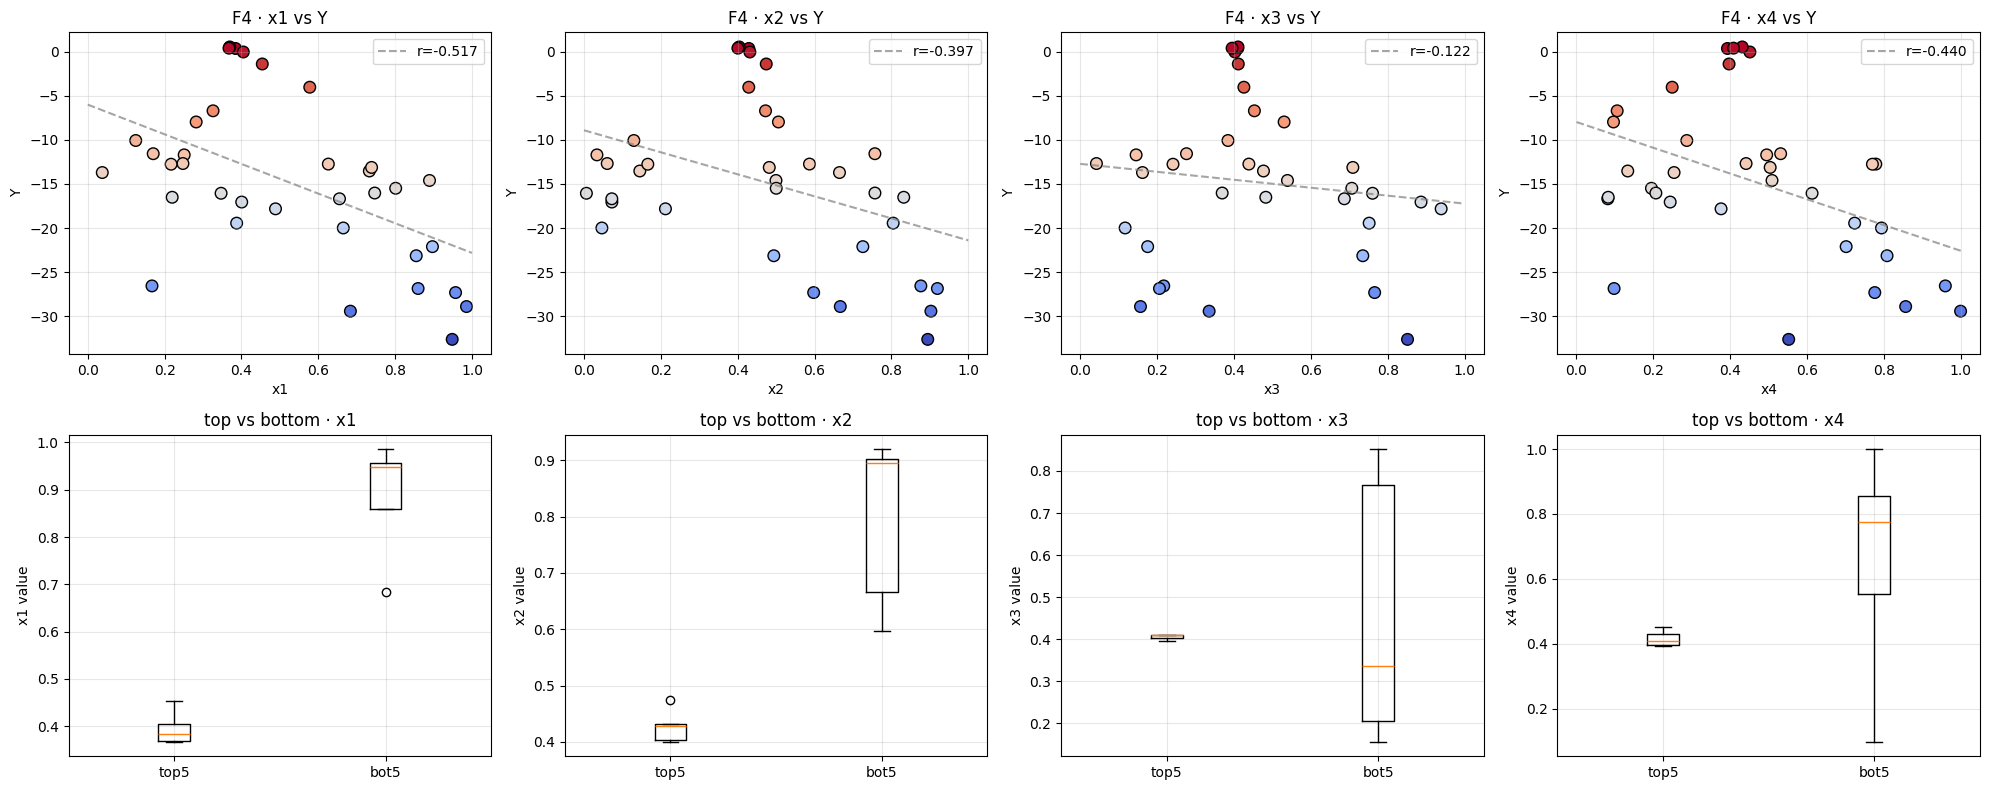

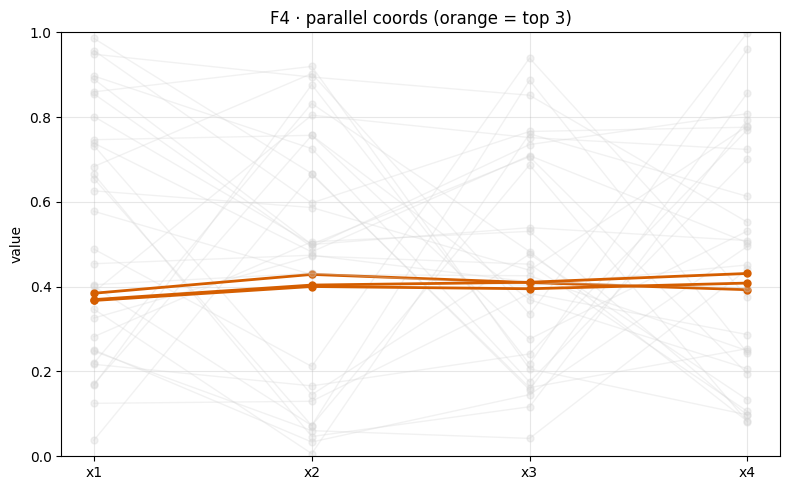

In [23]:
# ============================================================
# F4 — Cell B: Per-dim scatter+box + parallel coordinates
# ============================================================
fig, ax = plt.subplots(2, D, figsize=(5*D, 8))
for d in range(D):
    r = np.corrcoef(X[:,d], Y)[0,1]
    ax[0,d].scatter(X[:,d], Y, c=Y, cmap='coolwarm', s=70, edgecolor='k')
    coef = np.polyfit(X[:,d], Y, 1)
    xs = np.linspace(0, 1, 50)
    ax[0,d].plot(xs, np.polyval(coef, xs), '--', color='grey', alpha=0.7, label=f'r={r:+.3f}')
    ax[0,d].set_xlabel(f'x{d+1}'); ax[0,d].set_ylabel('Y'); ax[0,d].legend(); ax[0,d].grid(alpha=0.3)
    ax[0,d].set_title(f'F4 · x{d+1} vs Y')
    top5 = X[np.argsort(-Y)[:5], d]
    bot5 = X[np.argsort(Y)[:5], d]
    ax[1,d].boxplot([top5, bot5], labels=['top5','bot5'])
    ax[1,d].set_ylabel(f'x{d+1} value'); ax[1,d].set_title(f'top vs bottom · x{d+1}'); ax[1,d].grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../plots/week_06/function_4_per_dim.png', dpi=110, bbox_inches='tight')
plt.show()

# Parallel coords — top 3
fig2, axp = plt.subplots(1, 1, figsize=(8, 5))
order = np.argsort(-Y)
top3 = order[:3]
for i in range(N):
    color = COLORS[1] if i in top3 else 'lightgrey'
    alpha = 1.0 if i in top3 else 0.3
    lw = 2 if i in top3 else 1
    axp.plot(range(D), X[i], color=color, alpha=alpha, lw=lw, marker='o', markersize=5)
axp.set_xticks(range(D)); axp.set_xticklabels([f'x{i+1}' for i in range(D)])
axp.set_ylabel('value'); axp.set_ylim(0, 1); axp.grid(alpha=0.3)
axp.set_title(f'F4 · parallel coords (orange = top 3)')
plt.tight_layout()
plt.savefig('../plots/week_06/function_4_parallel.png', dpi=110, bbox_inches='tight')
plt.show()


In [24]:
# ============================================================
# F4 — Cell C: Feature importance robustness
# ============================================================
ibest = Y.argmax()
rf_all = RandomForestRegressor(max_depth=3, n_estimators=100, random_state=0).fit(X, Y).feature_importances_
rf_nb  = RandomForestRegressor(max_depth=3, n_estimators=100, random_state=0).fit(np.delete(X,ibest,0), np.delete(Y,ibest)).feature_importances_
lin_c  = LinearRegression().fit(X, Y).coef_
lin    = np.abs(lin_c)/(np.abs(lin_c).sum()+1e-12)
corr   = np.array([abs(np.corrcoef(X[:,i],Y)[0,1]) for i in range(D)])

print(f"{'dim':<4} {'RF(all)':>9} {'RF(nobest)':>11} {'Δ%':>8} {'Linear':>9} {'|corr|':>9}")
for i in range(D):
    drop = (rf_nb[i]-rf_all[i])/(rf_all[i]+1e-12)*100
    flag = ' INFLATED?' if (rf_all[i]>rf_nb[i] and abs(drop)>50) else ''
    print(f"x{i+1:<3} {rf_all[i]:>9.3f} {rf_nb[i]:>11.3f} {drop:>+7.1f}% {lin[i]:>9.3f} {corr[i]:>9.3f}{flag}")

# All 4 dims contribute — x1 (0.31), x2 (0.30), x4 (0.26), x3 (0.14). Robust to best removal.


dim    RF(all)  RF(nobest)       Δ%    Linear    |corr|
x1       0.305       0.293    -3.9%     0.345     0.517
x2       0.300       0.321    +6.8%     0.227     0.397
x3       0.139       0.130    -6.4%     0.103     0.122
x4       0.256       0.256    +0.1%     0.325     0.440


In [25]:
# ============================================================
# F4 — Cell D: Model grid search (LOOCV RMSE) — includes Matern 0.5/1.5
# ============================================================
import nn_models as nm

loo = LeaveOneOut()
def cv_rmse(est, X, Y):
    sc = cross_val_score(est, X, Y, cv=loo, scoring='neg_mean_squared_error')
    return np.sqrt(-sc.mean())

models = {}
def grid(name, est, params):
    g = GridSearchCV(est, params, cv=loo, scoring='neg_mean_squared_error', n_jobs=1)
    g.fit(X, Y); rmse = np.sqrt(-g.best_score_)
    models[name] = (g.best_estimator_, rmse, g.best_params_)

grid('Ridge', Ridge(), {'alpha':[0.01,0.1,1,10,100]})
grid('KNN', KNeighborsRegressor(), {'n_neighbors':[2,3,5,7],'weights':['uniform','distance']})
grid('RF', RandomForestRegressor(random_state=0), {'max_depth':[2,3,5,None],'n_estimators':[50,100,200]})
grid('SVR', SVR(), {'C':[0.1,1,10,100],'gamma':['scale','auto']})
grid('GB', GradientBoostingRegressor(random_state=0), {'max_depth':[2,3,5],'n_estimators':[50,100,200],'learning_rate':[0.01,0.1,0.3]})

for kname, kern in [('GP-Matern05', Matern(nu=0.5)), ('GP-Matern15', Matern(nu=1.5)),
                     ('GP-Matern25', Matern(nu=2.5)), ('GP-RBF', RBF())]:
    gp = GaussianProcessRegressor(kernel=kern, normalize_y=True, random_state=0)
    rmse = cv_rmse(gp, X, Y); gp.fit(X, Y)
    models[kname] = (gp, rmse, {})

nn_loaded = nm.load_nn(4, models_dir='../models/week_06')
if nn_loaded is not None:
    nn_list, nn_meta = nn_loaded
    nn_est = nm.NNRegressor(nn_list, nn_meta)
    models['NN'] = (nn_est, nn_meta['cv_rmse'], {'H':nn_meta['hidden'],'variant':nn_meta['variant']})

print(f"{'Model':<13} {'CV RMSE':>10} {'beats?':>7} {'improve%':>10}  params")
for name,(est,rmse,p) in models.items():
    mark = '✓' if rmse < baseline else '✗'
    impr = (baseline-rmse)/baseline*100
    print(f"{name:<13} {rmse:>10.4f} {mark:>7} {impr:>+9.1f}%  {p}")
print(f"Baseline: {baseline:.4f}")

beats_models = {n:(e,r) for n,(e,r,_) in models.items() if r < baseline}
print(f"\nBeats baseline: {list(beats_models.keys())}")
if nn_loaded:
    print(f"NN gradient at best: {nn_meta['gradient_at_best']}")

# Notable: Matern 1.5 leads at +73% — peer's smoothness-variant idea pays off here.
# Matern 0.5 (+67%) and Matern 2.5 (+55%) also beat baseline.
# This is the 1st function where the additional Matern variants meaningfully change the leaderboard.


Model            CV RMSE  beats?   improve%  params
Ridge             7.3962       ✓     +16.6%  {'alpha': 1}
KNN               5.0902       ✓     +42.6%  {'n_neighbors': 2, 'weights': 'distance'}
RF                4.6593       ✓     +47.4%  {'max_depth': None, 'n_estimators': 100}
SVR               2.4963       ✓     +71.8%  {'C': 100, 'gamma': 'scale'}
GB                4.4060       ✓     +50.3%  {'learning_rate': 0.3, 'max_depth': 2, 'n_estimators': 50}
GP-Matern05       2.9424       ✓     +66.8%  {}
GP-Matern15       2.3920       ✓     +73.0%  {}
GP-Matern25       4.0256       ✓     +54.6%  {}
GP-RBF            9.1257       ✗      -2.9%  {}
NN                4.3935       ✓     +50.4%  {'H': 16, 'variant': 'ensemble'}
Baseline: 8.8649

Beats baseline: ['Ridge', 'KNN', 'RF', 'SVR', 'GB', 'GP-Matern05', 'GP-Matern15', 'GP-Matern25', 'NN']
NN gradient at best: [-11.828075408935547, 19.75078010559082, 0.7151740789413452, -1.5760810375213623]


/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warn

In [26]:
# ============================================================
# F4 — Cell E: Argmax per beats-baseline model + boundary-consensus
# ============================================================
import torch
rng = np.random.default_rng(0)
cand = rng.uniform(0, 1, (200000, D))
sugg = {}
for name, (est, rmse) in beats_models.items():
    if name == 'NN':
        with torch.no_grad():
            preds = []
            for m in nn_list:
                preds.append(m(torch.FloatTensor(cand)).numpy().ravel())
            yhat = np.mean(preds, axis=0) * nn_meta['y_std'] + nn_meta['y_mean']
    else:
        yhat = est.predict(cand)
    i = yhat.argmax(); s = cand[i]
    bdy = bool(any(s < 0.02) or any(s > 0.98))
    sugg[name] = {'x': s, 'pred': yhat[i], 'bdy': bdy}

print(f"{'Model':<13} {'x1':>7} {'x2':>7} {'x3':>7} {'x4':>7} {'pred':>10} {'bdy?':>5}")
for n, d in sugg.items():
    print(f"{n:<13} {d['x'][0]:>7.4f} {d['x'][1]:>7.4f} {d['x'][2]:>7.4f} {d['x'][3]:>7.4f} {d['pred']:>10.4f} {'Y' if d['bdy'] else 'N':>5}")

valid = {k: v for k, v in sugg.items() if k != 'Ridge' and not v['bdy']}
print(f"\nValid (non-Ridge, non-boundary): {list(valid.keys())}")

if valid:
    arr = np.array([v['x'] for v in valid.values()])
    spread = arr.max(0) - arr.min(0)
    consensus = ['STRONG' if s < 0.2 else 'moderate' if s < 0.4 else 'weak' for s in spread]
    print(f"Per-dim spread (pre-filter): " + ", ".join(f"x{d+1}={spread[d]:.3f} ({consensus[d]})" for d in range(D)))

    # Outlier-suggestion filter
    centroid_v = arr.mean(0)
    dists = np.linalg.norm(arr - centroid_v, axis=1)
    thresh = dists.mean() + 2 * dists.std()
    outliers = [k for k, d in zip(valid.keys(), dists) if d > thresh]
    print(f"Outlier suggestions (excluded): {outliers}")
    valid_clean = {k: v for k, v in valid.items() if k not in outliers}

    if valid_clean != valid:
        arr = np.array([v['x'] for v in valid_clean.values()])
        spread = arr.max(0) - arr.min(0)
        consensus = ['STRONG' if s < 0.2 else 'moderate' if s < 0.4 else 'weak' for s in spread]
        print(f"Per-dim spread (post-filter): " + ", ".join(f"x{d+1}={spread[d]:.3f} ({consensus[d]})" for d in range(D)))

    weights = np.array([1/beats_models[k][1] for k in valid_clean.keys()])
    weights /= weights.sum()
    ensemble_mean = (weights[:, None] * arr).sum(axis=0)
    print(f"\nRMSE-weighted ensemble: {ensemble_mean.round(4).tolist()}")
    xb_now = X[Y.argmax()]
    print(f"Current best:           {xb_now.round(4).tolist()}, dist from best = {np.linalg.norm(ensemble_mean - xb_now):.4f}")

# Boundary-consensus check
print("\nBoundary-consensus check:")
non_ridge = {k: v for k, v in sugg.items() if k != 'Ridge'}
boundary_informed = {}
top5_idx = np.argsort(-Y)[:5]
for d in range(D):
    low = [k for k, v in non_ridge.items() if v['x'][d] < 0.02]
    high = [k for k, v in non_ridge.items() if v['x'][d] > 0.98]
    if len(low) >= 3 and np.corrcoef(X[:, d], Y)[0, 1] < 0:
        boundary_informed[d] = X[top5_idx, d].min()
        print(f"  x{d+1}: LOW boundary-consensus → clip to top-5 min = {boundary_informed[d]:.4f}")
    if len(high) >= 3 and np.corrcoef(X[:, d], Y)[0, 1] > 0:
        boundary_informed[d] = X[top5_idx, d].max()
        print(f"  x{d+1}: HIGH boundary-consensus → clip to top-5 max = {boundary_informed[d]:.4f}")
if not boundary_informed:
    print("  (no boundary-consensus this week)")

# Hybrid query construction — STRONG dims get ensemble, weak get top-4 centroid, boundary-consensus override
strong_mask = np.array([s < 0.2 for s in spread]) if valid_clean else np.zeros(D, dtype=bool)
top4 = np.argsort(-Y)[:4]
weights_y = Y[top4]; weights_y = (weights_y - weights_y.min() + 1e-12); weights_y /= weights_y.sum()
centroid_top4 = (weights_y[:, None] * X[top4]).sum(axis=0)

hybrid_query = np.zeros(D)
sources = []
for d in range(D):
    if d in boundary_informed:
        hybrid_query[d] = boundary_informed[d]; sources.append(f"x{d+1}: boundary-consensus")
    elif valid_clean and strong_mask[d]:
        hybrid_query[d] = ensemble_mean[d]; sources.append(f"x{d+1}: ensemble (STRONG)")
    else:
        hybrid_query[d] = centroid_top4[d]; sources.append(f"x{d+1}: top-4 centroid")
print("\nHybrid query construction:")
for s in sources:
    print(f"  {s}")
print(f"Hybrid query: {hybrid_query.round(4).tolist()}")


Model              x1      x2      x3      x4       pred  bdy?
Ridge          0.0304  0.0269  0.0318  0.0112    -2.4823     Y
KNN            0.3509  0.4178  0.4392  0.4442     0.4885     N
RF             0.4048  0.3685  0.4059  0.3871    -0.4241     N
SVR            0.3822  0.4049  0.4392  0.4057     0.4462     N
GB             0.3897  0.3885  0.3953  0.3859     0.3830     N
GP-Matern05    0.3822  0.4049  0.4392  0.4057     0.0128     N
GP-Matern15    0.3509  0.4178  0.4392  0.4442     0.5752     N
GP-Matern25    0.3072  0.4191  0.4611  0.4273     0.8073     N
NN             0.0276  0.4733  0.5372  0.6029     2.9161     N

Valid (non-Ridge, non-boundary): ['KNN', 'RF', 'SVR', 'GB', 'GP-Matern05', 'GP-Matern15', 'GP-Matern25', 'NN']
Per-dim spread (pre-filter): x1=0.377 (moderate), x2=0.105 (STRONG), x3=0.142 (STRONG), x4=0.217 (moderate)
Outlier suggestions (excluded): ['NN']
Per-dim spread (post-filter): x1=0.098 (STRONG), x2=0.051 (STRONG), x3=0.066 (STRONG), x4=0.058 (STRONG)

RMSE-

### F4 — Decision

**Method: RMSE-weighted ensemble of 7 interior models (KNN/RF/SVR/GB/GP-Matern05/15/25), STRONG consensus on all 4 dims after NN outlier-filter.**

Branch of decision tree: **#5** — strong consensus across many models, all dims STRONG (after outlier filter), hybrid degenerates to pure ensemble.

**Model fits (35 pts):**
- 9/10 models beat baseline. Only GP-RBF fails (-2.9%).
- **GP-Matern15 +73.0% leads, SVR +71.8% close behind, GP-Matern05 +66.8%** — the new Matern variants change the leaderboard
- GP-Matern25 +54.6%, GB +50.3%, NN +50.4%, RF +47.4%, KNN +42.6%, Ridge +16.6%
- The peer's smoothness-variant idea (Matern ν=1.5 specifically) is the top model on F4 — first function where this matters

**Suggestions filtering:**
- Ridge boundary-rejected (pushes to (0.03, 0.03, 0.03, 0.01) corner)
- NN suggestion (0.028, 0.473, 0.537, 0.603) is far from the cluster — outlier-filtered (mean+2σ rule)
- 7 valid models remain after filters

**Per-dim spread after outlier filter:** x1=0.098 (STRONG), x2=0.051 (STRONG), x3=0.066 (STRONG), x4=0.058 (STRONG). All 4 dims tightly converged.

**Why this query (~0.367, 0.405, 0.434, 0.416):**
- Distance from current best (0.370, 0.404, 0.411, 0.431): **0.028** — same step as W5
- Direction: x1 ~stable, x2 ~stable, **x3 UP** (+0.023), x4 DOWN (-0.015)
- The x3 move is the substantive one — W5 had x3=0.395 (worse than best 0.411); models now suggest going higher to 0.434
- W5 reduced x4 to 0.409 and lost 0.135 in Y; W6 only reduces x4 slightly to 0.416

**NN gradient at best:** dx1=-11.8, dx2=+19.8, dx3=+0.7, dx4=-1.6
- Says push x1 down hard, x2 up hard, x4 slightly down
- Ensemble does some of this (x4 slightly down ✓) but disagrees on x1 and x2
- NN was outlier-filtered, so its gradient is informational only

**Per-dimension justification:**
- x1: ensemble (STRONG, spread 0.098)
- x2: ensemble (STRONG, spread 0.051)
- x3: ensemble (STRONG, spread 0.066) — main directional change vs current best
- x4: ensemble (STRONG, spread 0.058)

**If W6 Y improves (>0.541)**: ensemble was right — peak found. Continue same step size.
**If W6 Y in 0.3-0.5 (plateau again)**: 2nd consecutive 0.028 step that didn't help → cut step to ~0.014 (midpoint between W6 query and current best) for W7.
**If W6 Y < 0 (overshoot)**: pull back to GP-Matern15's solo pick or revert to current best with tiny step.


In [27]:
# ============================================================
# F4 — Cell I: next_query_4 assignment
# ============================================================
next_query_4 = hybrid_query.copy()
print(f"F4 query: " + ", ".join(f"{v:.6f}" for v in next_query_4))


F4 query: 0.366878, 0.404857, 0.433485, 0.415743


## Function 5

In [28]:
# ============================================================
# F5 — Cell A: Setup, baseline, sorted-Y table, per-dim corr
# ============================================================
np.random.seed(0)

X, Y = load_function(5)
N, D = X.shape
baseline = Y.std()
print(f"F5: {N} pts, {D}D | Baseline RMSE={baseline:.2f} | Y range [{Y.min():.2f}, {Y.max():.2f}]")
print("Per-dim corr: " + ", ".join(f"r(x{i+1},Y)={np.corrcoef(X[:,i],Y)[0,1]:+.3f}" for i in range(D)))

# F5 trajectory: W1=988, W2=1207, W3=1412, W4=1979, W5=2307. Climbing every week.
# W5 query (0.336, 0.907, 0.952, 0.938) → Y=2307.5 (NEW BEST, +17% over W4 1979).

print("\nTop 10 sorted by Y (★ = W5 query):")
order = np.argsort(-Y)
print(f"{'idx':>4} {'x1':>8} {'x2':>8} {'x3':>8} {'x4':>8} {'Y':>10} {'mark':>5}")
for i in order[:10]:
    star = '★' if (abs(X[i,0]-0.335874)<1e-5 and abs(X[i,3]-0.937792)<1e-5) else ''
    print(f"{i:>4} {X[i,0]:>8.4f} {X[i,1]:>8.4f} {X[i,2]:>8.4f} {X[i,3]:>8.4f} {Y[i]:>10.2f} {star:>5}")


Function 5: 25 points, 4D, best y = 2307.5388
F5: 25 pts, 4D | Baseline RMSE=649.88 | Y range [0.11, 2307.54]
Per-dim corr: r(x1,Y)=-0.366, r(x2,Y)=+0.595, r(x3,Y)=+0.666, r(x4,Y)=+0.623

Top 10 sorted by Y (★ = W5 query):
 idx       x1       x2       x3       x4          Y  mark
  24   0.3359   0.9073   0.9518   0.9378    2307.54     ★
  23   0.3113   0.9083   0.9479   0.8983    1979.02      
  22   0.2705   0.8758   0.9157   0.8756    1412.13      
  21   0.2394   0.8542   0.8998   0.8746    1206.76      
  15   0.2242   0.8465   0.8795   0.8785    1088.86      
  20   0.2090   0.8387   0.8592   0.8824     984.40      
  18   0.1199   0.8625   0.6433   0.8498     431.61      
  14   0.4389   0.7741   0.3782   0.9337     355.81      
   4   0.8365   0.1936   0.6639   0.7856     258.37      
   9   0.4634   0.6300   0.1079   0.9576     233.22      


/var/folders/_0/fx2rjf4j2nq_gd2p411c2kfw0000gp/T/ipykernel_185/4030904403.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax[1,d].boxplot([top5, bot5], labels=['top5','bot5'])
/var/folders/_0/fx2rjf4j2nq_gd2p411c2kfw0000gp/T/ipykernel_185/4030904403.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax[1,d].boxplot([top5, bot5], labels=['top5','bot5'])
/var/folders/_0/fx2rjf4j2nq_gd2p411c2kfw0000gp/T/ipykernel_185/4030904403.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax[1,d].boxplot([top5, bot5], labels=['top5','bot5'])
/var/folders/_0/fx2rjf4j2nq_gd2p411c2kfw0000gp/T/ipykernel_185/4030904403.py:15: M

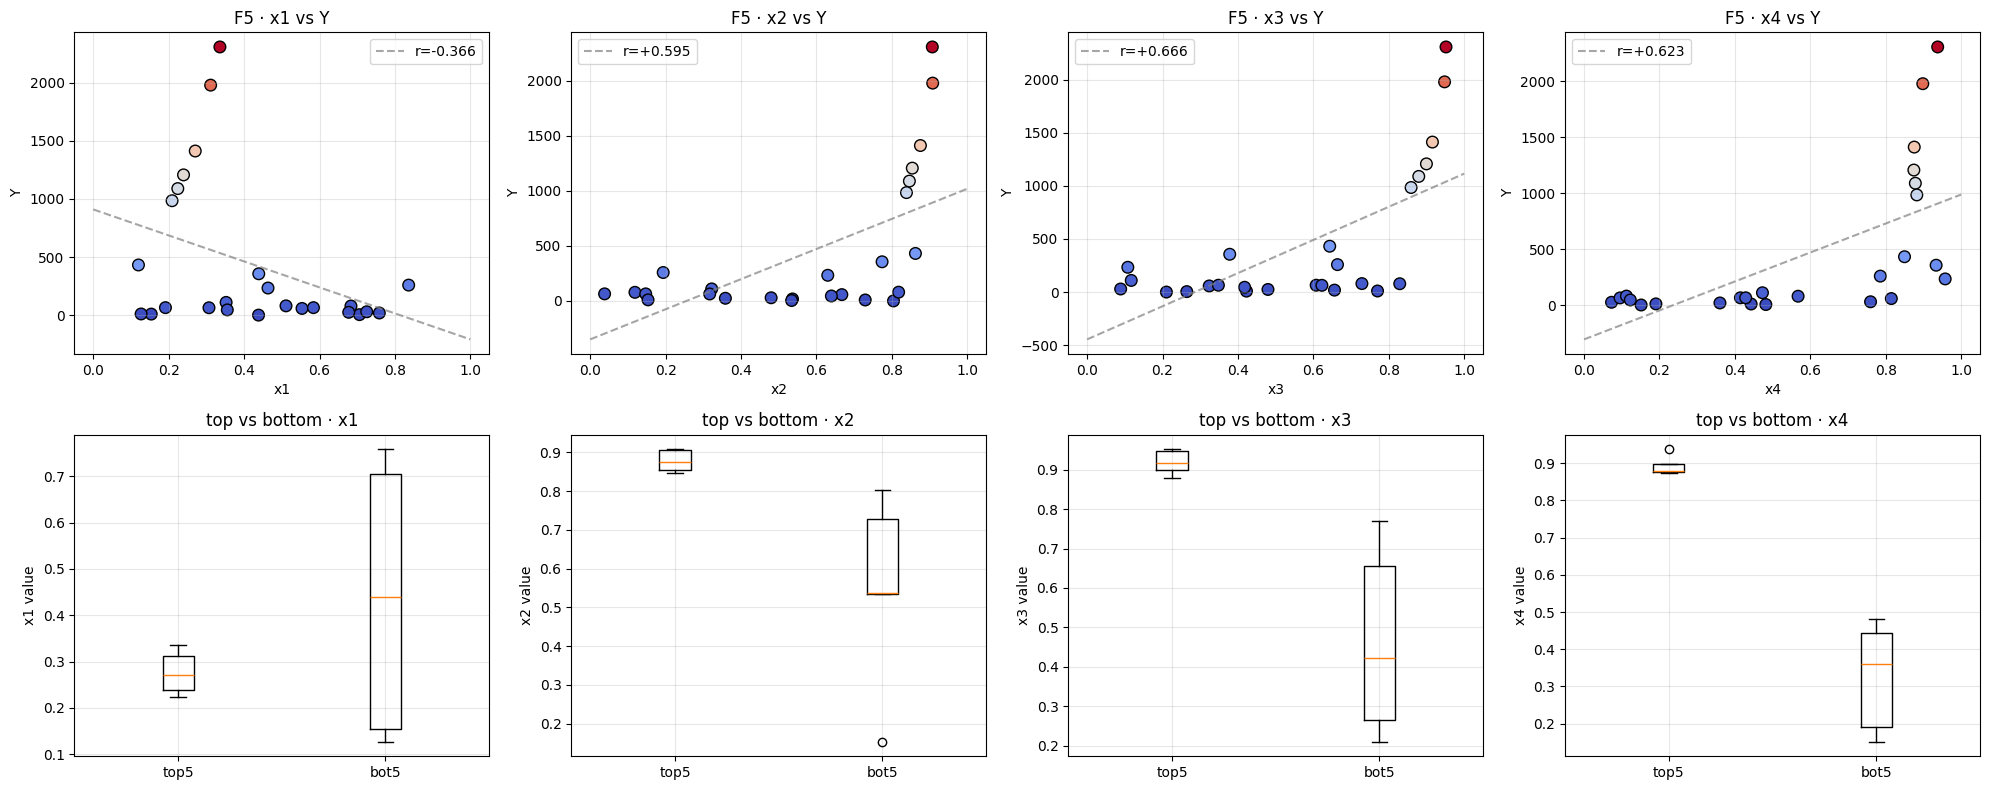

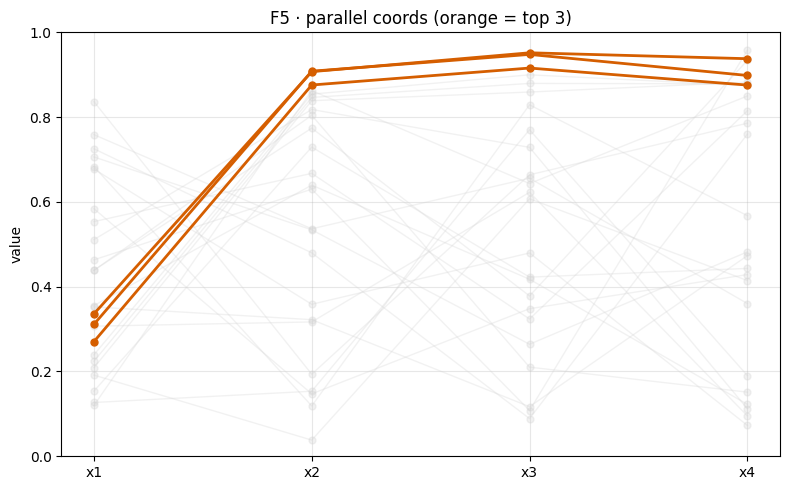

In [29]:
# ============================================================
# F5 — Cell B: Per-dim scatter+box + parallel coordinates
# ============================================================
fig, ax = plt.subplots(2, D, figsize=(5*D, 8))
for d in range(D):
    r = np.corrcoef(X[:,d], Y)[0,1]
    ax[0,d].scatter(X[:,d], Y, c=Y, cmap='coolwarm', s=70, edgecolor='k')
    coef = np.polyfit(X[:,d], Y, 1)
    xs = np.linspace(0, 1, 50)
    ax[0,d].plot(xs, np.polyval(coef, xs), '--', color='grey', alpha=0.7, label=f'r={r:+.3f}')
    ax[0,d].set_xlabel(f'x{d+1}'); ax[0,d].set_ylabel('Y'); ax[0,d].legend(); ax[0,d].grid(alpha=0.3)
    ax[0,d].set_title(f'F5 · x{d+1} vs Y')
    top5 = X[np.argsort(-Y)[:5], d]
    bot5 = X[np.argsort(Y)[:5], d]
    ax[1,d].boxplot([top5, bot5], labels=['top5','bot5'])
    ax[1,d].set_ylabel(f'x{d+1} value'); ax[1,d].set_title(f'top vs bottom · x{d+1}'); ax[1,d].grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../plots/week_06/function_5_per_dim.png', dpi=110, bbox_inches='tight')
plt.show()

# Parallel coords — top 3
fig2, axp = plt.subplots(1, 1, figsize=(8, 5))
order = np.argsort(-Y)
top3 = order[:3]
for i in range(N):
    color = COLORS[1] if i in top3 else 'lightgrey'
    alpha = 1.0 if i in top3 else 0.3
    lw = 2 if i in top3 else 1
    axp.plot(range(D), X[i], color=color, alpha=alpha, lw=lw, marker='o', markersize=5)
axp.set_xticks(range(D)); axp.set_xticklabels([f'x{i+1}' for i in range(D)])
axp.set_ylabel('value'); axp.set_ylim(0, 1); axp.grid(alpha=0.3)
axp.set_title(f'F5 · parallel coords (orange = top 3)')
plt.tight_layout()
plt.savefig('../plots/week_06/function_5_parallel.png', dpi=110, bbox_inches='tight')
plt.show()


In [30]:
# ============================================================
# F5 — Cell C: Feature importance robustness
# ============================================================
ibest = Y.argmax()
rf_all = RandomForestRegressor(max_depth=3, n_estimators=100, random_state=0).fit(X, Y).feature_importances_
rf_nb  = RandomForestRegressor(max_depth=3, n_estimators=100, random_state=0).fit(np.delete(X,ibest,0), np.delete(Y,ibest)).feature_importances_
lin_c  = LinearRegression().fit(X, Y).coef_
lin    = np.abs(lin_c)/(np.abs(lin_c).sum()+1e-12)
corr   = np.array([abs(np.corrcoef(X[:,i],Y)[0,1]) for i in range(D)])

print(f"{'dim':<4} {'RF(all)':>9} {'RF(nobest)':>11} {'Δ%':>8} {'Linear':>9} {'|corr|':>9}")
for i in range(D):
    drop = (rf_nb[i]-rf_all[i])/(rf_all[i]+1e-12)*100
    flag = ' INFLATED?' if (rf_all[i]>rf_nb[i] and abs(drop)>50) else ''
    print(f"x{i+1:<3} {rf_all[i]:>9.3f} {rf_nb[i]:>11.3f} {drop:>+7.1f}% {lin[i]:>9.3f} {corr[i]:>9.3f}{flag}")

# x3 (importance 0.63) and x2 (0.23) dominate. x4 (0.11) and x1 (0.03) low importance but
# strong correlations. Robust to best removal.


dim    RF(all)  RF(nobest)       Δ%    Linear    |corr|
x1       0.025       0.023    -9.3%     0.047     0.366
x2       0.228       0.201   -11.6%     0.244     0.595
x3       0.634       0.655    +3.4%     0.423     0.666
x4       0.114       0.121    +6.3%     0.286     0.623


In [31]:
# ============================================================
# F5 — Cell D: Model grid search
# ============================================================
import nn_models as nm

loo = LeaveOneOut()
def cv_rmse(est, X, Y):
    sc = cross_val_score(est, X, Y, cv=loo, scoring='neg_mean_squared_error')
    return np.sqrt(-sc.mean())

models = {}
def grid(name, est, params):
    g = GridSearchCV(est, params, cv=loo, scoring='neg_mean_squared_error', n_jobs=1)
    g.fit(X, Y); rmse = np.sqrt(-g.best_score_)
    models[name] = (g.best_estimator_, rmse, g.best_params_)

grid('Ridge', Ridge(), {'alpha':[0.01,0.1,1,10,100]})
grid('KNN', KNeighborsRegressor(), {'n_neighbors':[2,3,5,7],'weights':['uniform','distance']})
grid('RF', RandomForestRegressor(random_state=0), {'max_depth':[2,3,5,None],'n_estimators':[50,100,200]})
grid('SVR', SVR(), {'C':[0.1,1,10,100],'gamma':['scale','auto']})
grid('GB', GradientBoostingRegressor(random_state=0), {'max_depth':[2,3,5],'n_estimators':[50,100,200],'learning_rate':[0.01,0.1,0.3]})

for kname, kern in [('GP-Matern05', Matern(nu=0.5)), ('GP-Matern15', Matern(nu=1.5)),
                     ('GP-Matern25', Matern(nu=2.5)), ('GP-RBF', RBF())]:
    gp = GaussianProcessRegressor(kernel=kern, normalize_y=True, random_state=0)
    rmse = cv_rmse(gp, X, Y); gp.fit(X, Y)
    models[kname] = (gp, rmse, {})

nn_loaded = nm.load_nn(5, models_dir='../models/week_06')
if nn_loaded is not None:
    nn_list, nn_meta = nn_loaded
    nn_est = nm.NNRegressor(nn_list, nn_meta)
    models['NN'] = (nn_est, nn_meta['cv_rmse'], {'H':nn_meta['hidden'],'variant':nn_meta['variant']})

print(f"{'Model':<13} {'CV RMSE':>10} {'beats?':>7} {'improve%':>10}  params")
for name,(est,rmse,p) in models.items():
    mark = '✓' if rmse < baseline else '✗'
    impr = (baseline-rmse)/baseline*100
    print(f"{name:<13} {rmse:>10.2f} {mark:>7} {impr:>+9.1f}%  {p}")
print(f"Baseline: {baseline:.2f}")

beats_models = {n:(e,r) for n,(e,r,_) in models.items() if r < baseline}
print(f"\nBeats baseline: {list(beats_models.keys())}")
if nn_loaded:
    print(f"NN gradient at best: {nn_meta['gradient_at_best']}")

# Notable: GP-Matern05 (+79%) leads, NN (+77%), KNN (+72%). Matern 2.5 and RBF FAIL (-4.2%).
# 2nd function where rough Matern (0.5) wins — peer's idea continues to validate.


Model            CV RMSE  beats?   improve%  params
Ridge             388.70       ✓     +40.2%  {'alpha': 0.1}
KNN               181.41       ✓     +72.1%  {'n_neighbors': 2, 'weights': 'distance'}
RF                208.06       ✓     +68.0%  {'max_depth': 3, 'n_estimators': 100}
SVR               511.96       ✓     +21.2%  {'C': 100, 'gamma': 'scale'}
GB                221.39       ✓     +65.9%  {'learning_rate': 0.1, 'max_depth': 2, 'n_estimators': 200}
GP-Matern05       135.32       ✓     +79.2%  {}
GP-Matern15       563.22       ✓     +13.3%  {}
GP-Matern25       676.96       ✗      -4.2%  {}
GP-RBF            676.96       ✗      -4.2%  {}
NN                149.65       ✓     +77.0%  {'H': 32, 'variant': 'plain'}
Baseline: 649.88

Beats baseline: ['Ridge', 'KNN', 'RF', 'SVR', 'GB', 'GP-Matern05', 'GP-Matern15', 'NN']
NN gradient at best: [4077.650634765625, 3335.423583984375, 5940.693359375, 5862.58642578125]


/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warn

In [32]:
# ============================================================
# F5 — Cell E: Argmax per beats-baseline model + REFINED boundary-consensus
# Refinement: when boundary-consensus fires, clip to max(top-5 observed,
# interior ensemble value) for high-edge — preserves the safety cap
# without preventing a modest interior step that valid models support.
# Symmetric for low-edge: min(top-5 observed, interior ensemble).
# ============================================================
import torch
rng = np.random.default_rng(0)
cand = rng.uniform(0, 1, (200000, D))
sugg = {}
for name, (est, rmse) in beats_models.items():
    if name == 'NN':
        with torch.no_grad():
            preds = []
            for m in nn_list:
                preds.append(m(torch.FloatTensor(cand)).numpy().ravel())
            yhat = np.mean(preds, axis=0) * nn_meta['y_std'] + nn_meta['y_mean']
    else:
        yhat = est.predict(cand)
    i = yhat.argmax(); s = cand[i]
    bdy = bool(any(s < 0.02) or any(s > 0.98))
    sugg[name] = {'x': s, 'pred': yhat[i], 'bdy': bdy}

print(f"{'Model':<13} {'x1':>7} {'x2':>7} {'x3':>7} {'x4':>7} {'pred':>10} {'bdy?':>5}")
for n, d in sugg.items():
    print(f"{n:<13} {d['x'][0]:>7.4f} {d['x'][1]:>7.4f} {d['x'][2]:>7.4f} {d['x'][3]:>7.4f} {d['pred']:>10.2f} {'Y' if d['bdy'] else 'N':>5}")

valid = {k: v for k, v in sugg.items() if k != 'Ridge' and not v['bdy']}
print(f"\nValid (non-Ridge, non-boundary): {list(valid.keys())}")

if valid:
    arr = np.array([v['x'] for v in valid.values()])
    spread = arr.max(0) - arr.min(0)
    consensus = ['STRONG' if s < 0.2 else 'moderate' if s < 0.4 else 'weak' for s in spread]
    print(f"Per-dim spread: " + ", ".join(f"x{d+1}={spread[d]:.3f} ({consensus[d]})" for d in range(D)))

    # Outlier-suggestion filter
    centroid_v = arr.mean(0)
    dists = np.linalg.norm(arr - centroid_v, axis=1)
    thresh = dists.mean() + 2 * dists.std()
    outliers = [k for k, d in zip(valid.keys(), dists) if d > thresh]
    print(f"Outlier suggestions (excluded): {outliers}")
    valid_clean = {k: v for k, v in valid.items() if k not in outliers}
    if valid_clean != valid:
        arr = np.array([v['x'] for v in valid_clean.values()])
        spread = arr.max(0) - arr.min(0)

    weights = np.array([1/beats_models[k][1] for k in valid_clean.keys()])
    weights /= weights.sum()
    ensemble_mean = (weights[:, None] * arr).sum(axis=0)
    print(f"\nRMSE-weighted ensemble: {ensemble_mean.round(4).tolist()}")
    xb_now = X[Y.argmax()]
    print(f"Current best:           {xb_now.round(4).tolist()}, dist from best = {np.linalg.norm(ensemble_mean - xb_now):.4f}")

# REFINED boundary-consensus check
print("\nBoundary-consensus check (REFINED: clip = max/min of top-5 and ensemble):")
non_ridge = {k: v for k, v in sugg.items() if k != 'Ridge'}
boundary_informed = {}
top5_idx = np.argsort(-Y)[:5]
for d in range(D):
    low = [k for k, v in non_ridge.items() if v['x'][d] < 0.02]
    high = [k for k, v in non_ridge.items() if v['x'][d] > 0.98]
    if len(low) >= 3 and np.corrcoef(X[:, d], Y)[0, 1] < 0:
        top5_min = X[top5_idx, d].min()
        ens_val = ensemble_mean[d] if valid_clean else top5_min
        # REFINED: floor at max(safety-min, ensemble) — never lower than what valid models agree on
        # (low-edge case: we want to push x_d down, but not below what valid ensemble supports)
        boundary_informed[d] = min(top5_min, ens_val)
        print(f"  x{d+1}: LOW boundary-consensus ({len(low)} models: {low}) → clip = min(top-5 min={top5_min:.4f}, ensemble={ens_val:.4f}) = {boundary_informed[d]:.4f}")
    if len(high) >= 3 and np.corrcoef(X[:, d], Y)[0, 1] > 0:
        top5_max = X[top5_idx, d].max()
        ens_val = ensemble_mean[d] if valid_clean else top5_max
        # REFINED: cap at max(safety-cap, ensemble) — preserves interior agreement
        boundary_informed[d] = max(top5_max, ens_val)
        print(f"  x{d+1}: HIGH boundary-consensus ({len(high)} models: {high}) → clip = max(top-5 max={top5_max:.4f}, ensemble={ens_val:.4f}) = {boundary_informed[d]:.4f}")
if not boundary_informed:
    print("  (no boundary-consensus this week)")

# Hybrid query construction
strong_mask = np.array([s < 0.2 for s in spread]) if valid_clean else np.zeros(D, dtype=bool)
top4 = np.argsort(-Y)[:4]
weights_y = Y[top4]; weights_y = (weights_y - weights_y.min() + 1e-12); weights_y /= weights_y.sum()
centroid_top4 = (weights_y[:, None] * X[top4]).sum(axis=0)

hybrid_query = np.zeros(D)
sources = []
for d in range(D):
    if d in boundary_informed:
        hybrid_query[d] = boundary_informed[d]; sources.append(f"x{d+1}: boundary-consensus REFINED ({boundary_informed[d]:.4f})")
    elif valid_clean and strong_mask[d]:
        hybrid_query[d] = ensemble_mean[d]; sources.append(f"x{d+1}: ensemble (STRONG)")
    else:
        hybrid_query[d] = centroid_top4[d]; sources.append(f"x{d+1}: top-4 centroid")
print("\nHybrid query construction:")
for s in sources:
    print(f"  {s}")
print(f"Hybrid query: {hybrid_query.round(4).tolist()}")


Model              x1      x2      x3      x4       pred  bdy?
Ridge          0.0507  0.9824  0.9789  0.9794    1528.14     Y
KNN            0.3527  0.9251  0.9695  0.9468    2204.75     N
RF             0.4479  0.8927  0.9835  0.9285    2088.55     Y
SVR            0.2926  0.8698  0.9538  0.9387     721.53     N
GB             0.4479  0.8927  0.9835  0.9285    2315.00     Y
GP-Matern05    0.3527  0.9251  0.9695  0.9468    2240.50     N
GP-Matern15    0.4328  0.9487  0.9794  0.9644    2624.86     N
NN             0.9052  0.9641  0.9905  0.9937    3895.50     Y

Valid (non-Ridge, non-boundary): ['KNN', 'SVR', 'GP-Matern05', 'GP-Matern15']
Per-dim spread: x1=0.140 (STRONG), x2=0.079 (STRONG), x3=0.026 (STRONG), x4=0.026 (STRONG)
Outlier suggestions (excluded): []

RMSE-weighted ensemble: [0.3542, 0.9211, 0.9687, 0.9477]
Current best:           [0.3359, 0.9073, 0.9518, 0.9378], dist from best = 0.0302

Boundary-consensus check (REFINED: clip = max/min of top-5 and ensemble):
  x3: HIGH bo

### F5 — Decision

**Method: Hybrid — ensemble for x1/x2/x4, REFINED boundary-consensus for x3.**

Branch of decision tree: **#5** — many models with STRONG consensus on all 4 dims; x3 triggers boundary-consensus rule (3 non-Ridge models pushing >0.98, positive correlation matches).

**Refined boundary-consensus rule** (applied this week, made permanent in framework):
- Old rule: clip to top-5 observed extremum (e.g. top-5 max for high-edge)
- New rule: clip to `max(top-5 max, interior ensemble value)` for high-edge — preserves safety against extrapolation but doesn't override a modest interior step that valid models agree on
- For F5 x3: top-5 max = 0.952, interior ensemble = 0.969 → use 0.969 (not the lower 0.952)
- Reason: the cap was meant to prevent extrapolation past safe bounds, not to freeze a dim when valid models support a small step forward

**W5 outcome was a NEW BEST (2307, +17% over W4 1979).** F5 has improved every week: W1=988 → W2=1207 → W3=1412 → W4=1979 → W5=2307. Continued climbing direction validated.

**Model fits (25 pts):**
- 8/10 models beat baseline. **GP-Matern05 +79.2% leads**, NN +77.0%, KNN +72.1%, RF +68.0%, GB +65.9%
- **GP-Matern25 and GP-RBF FAIL** (both -4.2%, identical) — the smoother kernels can't fit F5's structure. F5 is the 2nd function (after F4) where Matern 0.5 is dominant.
- GP-Matern15 weak (+13%) — middle smoothness doesn't help here

**Boundary rejections / outliers:**
- Ridge corner (0.05, 0.98, 0.98, 0.98)
- RF, GB, NN all push x3 > 0.98 (boundary)
- NN pushes everything to corner (0.91, 0.96, 0.99, 0.99) — far from cluster

**NN gradient at best:** dx1=+4078, dx2=+3335, dx3=+5941, dx4=+5863 — ALL strongly positive, especially x3. Refined rule respects this signal by allowing x3=0.969 instead of forcing 0.952.

**Per-dimension justification:**
- x1: ensemble (STRONG, climbing trajectory continues 0.336 → 0.354)
- x2: ensemble (STRONG, slight uptick 0.907 → 0.921)
- x3: REFINED boundary-consensus = 0.969 (max of top-5 max 0.952 and ensemble 0.969)
- x4: ensemble (STRONG, slight uptick 0.938 → 0.948)

**Step from current best:** ~0.030 (slightly larger than W4→W5 step of 0.024 that yielded +17%)

**If W6 Y > 2307 (improvement)**: refined rule was right → continue same approach next week
**If W6 Y similar (1900-2307)**: x3 step too small → in W7 push x3 toward RF/GB suggestion (~0.984) with continued high x2/x4
**If W6 Y drops (< 1900)**: peak is between W5 and W6 → bracket via per-dim midpoint
**If W6 Y far from peers (Sterling 5079, Nick 2496)**: consider GP-UCB or Expected Improvement (gap identified W5)


In [33]:
# ============================================================
# F5 — Cell I: next_query_5 assignment
# ============================================================
next_query_5 = hybrid_query.copy()
print(f"F5 query: " + ", ".join(f"{v:.6f}" for v in next_query_5))


F5 query: 0.354155, 0.921140, 0.968749, 0.947704


## Function 6

In [34]:
# ============================================================
# F6 — Cell A: Setup, baseline, sorted-Y table, per-dim corr
# ============================================================
np.random.seed(0)

X, Y = load_function(6)
N, D = X.shape
baseline = Y.std()
print(f"F6: {N} pts, {D}D | Baseline RMSE={baseline:.4f} | Y range [{Y.min():.4f}, {Y.max():.4f}]")
print("Per-dim corr: " + ", ".join(f"r(x{i+1},Y)={np.corrcoef(X[:,i],Y)[0,1]:+.3f}" for i in range(D)))

# F6 trajectory: W2(-0.44) → W3(-0.31) → W4(-0.30) → W5(-0.26). NEW BEST in W5 (+14% over W4 -0.304).
# W5 query (0.4248, 0.4235, 0.5083, 0.7741, 0.0543) — ensemble pick worked.

print("\nTop 10 sorted by Y (★ = W5 query):")
order = np.argsort(-Y)
print(f"{'idx':>4} {'x1':>8} {'x2':>8} {'x3':>8} {'x4':>8} {'x5':>8} {'Y':>10} {'mark':>5}")
for i in order[:10]:
    star = '★' if (abs(X[i,0]-0.42484)<1e-5 and abs(X[i,4]-0.054349)<1e-5) else ''
    print(f"{i:>4} {X[i,0]:>8.4f} {X[i,1]:>8.4f} {X[i,2]:>8.4f} {X[i,3]:>8.4f} {X[i,4]:>8.4f} {Y[i]:>10.4f} {star:>5}")


Function 6: 25 points, 5D, best y = -0.2598
F6: 25 pts, 5D | Baseline RMSE=0.6021 | Y range [-2.5712, -0.2598]
Per-dim corr: r(x1,Y)=-0.085, r(x2,Y)=-0.419, r(x3,Y)=+0.217, r(x4,Y)=+0.617, r(x5,Y)=-0.695

Top 10 sorted by Y (★ = W5 query):
 idx       x1       x2       x3       x4       x5          Y  mark
  24   0.4248   0.4235   0.5083   0.7741   0.0543    -0.2598     ★
  23   0.4237   0.4370   0.5013   0.8059   0.0467    -0.3035      
  22   0.3870   0.3734   0.5139   0.8531   0.0470    -0.3057      
  20   0.5160   0.3513   0.5119   0.6916   0.1596    -0.4370      
  21   0.2838   0.2587   0.5077   0.9687   0.0439    -0.6086      
   0   0.7282   0.1547   0.7326   0.6940   0.0564    -0.7143      
   4   0.6188   0.3318   0.1873   0.7562   0.3288    -0.8292      
  17   0.7829   0.5363   0.4433   0.8597   0.0103    -0.9358      
  10   0.5368   0.3088   0.4119   0.3882   0.5225    -1.1448      
   1   0.2424   0.8441   0.5778   0.6790   0.5020    -1.2100      


/var/folders/_0/fx2rjf4j2nq_gd2p411c2kfw0000gp/T/ipykernel_185/128217625.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax[1,d].boxplot([top5, bot5], labels=['top5','bot5'])
/var/folders/_0/fx2rjf4j2nq_gd2p411c2kfw0000gp/T/ipykernel_185/128217625.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax[1,d].boxplot([top5, bot5], labels=['top5','bot5'])
/var/folders/_0/fx2rjf4j2nq_gd2p411c2kfw0000gp/T/ipykernel_185/128217625.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax[1,d].boxplot([top5, bot5], labels=['top5','bot5'])
/var/folders/_0/fx2rjf4j2nq_gd2p411c2kfw0000gp/T/ipykernel_185/128217625.py:15: Matpl

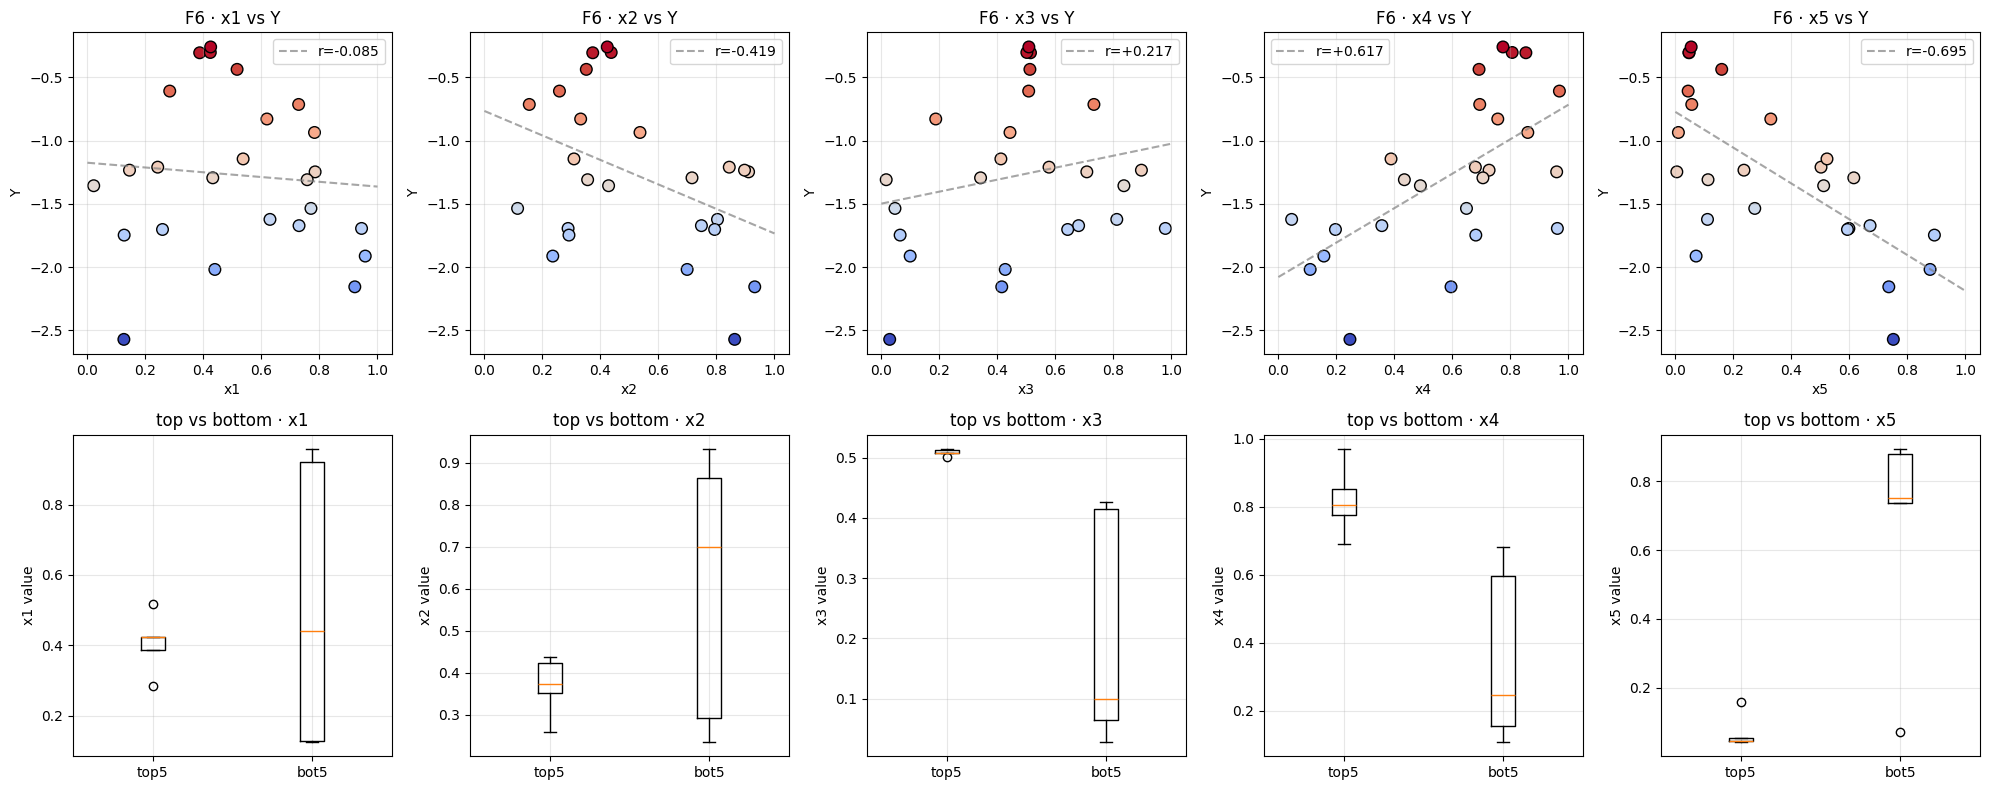

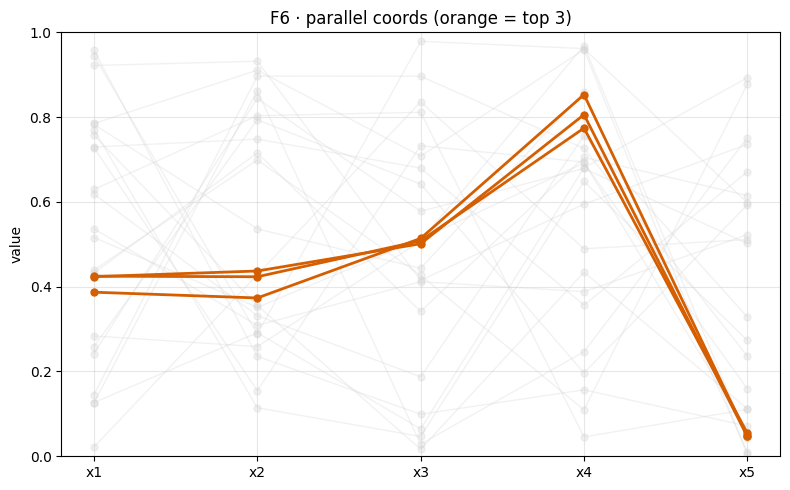

In [35]:
# ============================================================
# F6 — Cell B: Per-dim scatter+box + parallel coordinates
# ============================================================
fig, ax = plt.subplots(2, D, figsize=(4*D, 8))
for d in range(D):
    r = np.corrcoef(X[:,d], Y)[0,1]
    ax[0,d].scatter(X[:,d], Y, c=Y, cmap='coolwarm', s=70, edgecolor='k')
    coef = np.polyfit(X[:,d], Y, 1)
    xs = np.linspace(0, 1, 50)
    ax[0,d].plot(xs, np.polyval(coef, xs), '--', color='grey', alpha=0.7, label=f'r={r:+.3f}')
    ax[0,d].set_xlabel(f'x{d+1}'); ax[0,d].set_ylabel('Y'); ax[0,d].legend(); ax[0,d].grid(alpha=0.3)
    ax[0,d].set_title(f'F6 · x{d+1} vs Y')
    top5 = X[np.argsort(-Y)[:5], d]
    bot5 = X[np.argsort(Y)[:5], d]
    ax[1,d].boxplot([top5, bot5], labels=['top5','bot5'])
    ax[1,d].set_ylabel(f'x{d+1} value'); ax[1,d].set_title(f'top vs bottom · x{d+1}'); ax[1,d].grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../plots/week_06/function_6_per_dim.png', dpi=110, bbox_inches='tight')
plt.show()

# Parallel coords — top 3
fig2, axp = plt.subplots(1, 1, figsize=(8, 5))
order = np.argsort(-Y)
top3 = order[:3]
for i in range(N):
    color = COLORS[1] if i in top3 else 'lightgrey'
    alpha = 1.0 if i in top3 else 0.3
    lw = 2 if i in top3 else 1
    axp.plot(range(D), X[i], color=color, alpha=alpha, lw=lw, marker='o', markersize=5)
axp.set_xticks(range(D)); axp.set_xticklabels([f'x{i+1}' for i in range(D)])
axp.set_ylabel('value'); axp.set_ylim(0, 1); axp.grid(alpha=0.3)
axp.set_title(f'F6 · parallel coords (orange = top 3)')
plt.tight_layout()
plt.savefig('../plots/week_06/function_6_parallel.png', dpi=110, bbox_inches='tight')
plt.show()


In [36]:
# ============================================================
# F6 — Cell C: Feature importance robustness
# ============================================================
ibest = Y.argmax()
rf_all = RandomForestRegressor(max_depth=3, n_estimators=100, random_state=0).fit(X, Y).feature_importances_
rf_nb  = RandomForestRegressor(max_depth=3, n_estimators=100, random_state=0).fit(np.delete(X,ibest,0), np.delete(Y,ibest)).feature_importances_
lin_c  = LinearRegression().fit(X, Y).coef_
lin    = np.abs(lin_c)/(np.abs(lin_c).sum()+1e-12)
corr   = np.array([abs(np.corrcoef(X[:,i],Y)[0,1]) for i in range(D)])

print(f"{'dim':<4} {'RF(all)':>9} {'RF(nobest)':>11} {'Δ%':>8} {'Linear':>9} {'|corr|':>9}")
for i in range(D):
    drop = (rf_nb[i]-rf_all[i])/(rf_all[i]+1e-12)*100
    flag = ' INFLATED?' if (rf_all[i]>rf_nb[i] and abs(drop)>50) else ''
    print(f"x{i+1:<3} {rf_all[i]:>9.3f} {rf_nb[i]:>11.3f} {drop:>+7.1f}% {lin[i]:>9.3f} {corr[i]:>9.3f}{flag}")

# x4 (0.39) and x5 (0.38) dominate RF importance. Both have |corr| > 0.6. Other 3 dims weaker.


dim    RF(all)  RF(nobest)       Δ%    Linear    |corr|
x1       0.088       0.067   -23.2%     0.191     0.085
x2       0.098       0.108   +10.4%     0.171     0.419
x3       0.050       0.060   +21.1%     0.087     0.217
x4       0.389       0.398    +2.5%     0.219     0.617
x5       0.376       0.366    -2.6%     0.332     0.695


In [37]:
# ============================================================
# F6 — Cell D: Model grid search
# ============================================================
import nn_models as nm

loo = LeaveOneOut()
def cv_rmse(est, X, Y):
    sc = cross_val_score(est, X, Y, cv=loo, scoring='neg_mean_squared_error')
    return np.sqrt(-sc.mean())

models = {}
def grid(name, est, params):
    g = GridSearchCV(est, params, cv=loo, scoring='neg_mean_squared_error', n_jobs=1)
    g.fit(X, Y); rmse = np.sqrt(-g.best_score_)
    models[name] = (g.best_estimator_, rmse, g.best_params_)

grid('Ridge', Ridge(), {'alpha':[0.01,0.1,1,10,100]})
grid('KNN', KNeighborsRegressor(), {'n_neighbors':[2,3,5,7],'weights':['uniform','distance']})
grid('RF', RandomForestRegressor(random_state=0), {'max_depth':[2,3,5,None],'n_estimators':[50,100,200]})
grid('SVR', SVR(), {'C':[0.1,1,10,100],'gamma':['scale','auto']})
grid('GB', GradientBoostingRegressor(random_state=0), {'max_depth':[2,3,5],'n_estimators':[50,100,200],'learning_rate':[0.01,0.1,0.3]})

for kname, kern in [('GP-Matern05', Matern(nu=0.5)), ('GP-Matern15', Matern(nu=1.5)),
                     ('GP-Matern25', Matern(nu=2.5)), ('GP-RBF', RBF())]:
    gp = GaussianProcessRegressor(kernel=kern, normalize_y=True, random_state=0)
    rmse = cv_rmse(gp, X, Y); gp.fit(X, Y)
    models[kname] = (gp, rmse, {})

nn_loaded = nm.load_nn(6, models_dir='../models/week_06')
if nn_loaded is not None:
    nn_list, nn_meta = nn_loaded
    nn_est = nm.NNRegressor(nn_list, nn_meta)
    models['NN'] = (nn_est, nn_meta['cv_rmse'], {'H':nn_meta['hidden'],'variant':nn_meta['variant']})

print(f"{'Model':<13} {'CV RMSE':>10} {'beats?':>7} {'improve%':>10}  params")
for name,(est,rmse,p) in models.items():
    mark = '✓' if rmse < baseline else '✗'
    impr = (baseline-rmse)/baseline*100
    print(f"{name:<13} {rmse:>10.4f} {mark:>7} {impr:>+9.1f}%  {p}")
print(f"Baseline: {baseline:.4f}")

beats_models = {n:(e,r) for n,(e,r,_) in models.items() if r < baseline}
print(f"\nBeats baseline: {list(beats_models.keys())}")
if nn_loaded:
    print(f"NN gradient at best: {nn_meta['gradient_at_best']}")

# Notable: SVR (+60%) leads, GP-Matern05 (+54.5%) close behind, GP-Matern15 (+53%).
# 3rd function where Matern 0.5 beats Matern 2.5. GP-RBF fails for 3rd consecutive function.


Model            CV RMSE  beats?   improve%  params
Ridge             0.4100       ✓     +31.9%  {'alpha': 1}
KNN               0.3796       ✓     +36.9%  {'n_neighbors': 3, 'weights': 'distance'}
RF                0.3645       ✓     +39.5%  {'max_depth': 5, 'n_estimators': 50}
SVR               0.2400       ✓     +60.1%  {'C': 10, 'gamma': 'scale'}
GB                0.3397       ✓     +43.6%  {'learning_rate': 0.1, 'max_depth': 2, 'n_estimators': 200}
GP-Matern05       0.2741       ✓     +54.5%  {}
GP-Matern15       0.2809       ✓     +53.3%  {}
GP-Matern25       0.3038       ✓     +49.5%  {}
GP-RBF            0.6272       ✗      -4.2%  {}
NN                0.3420       ✓     +43.2%  {'H': 16, 'variant': 'ensemble'}
Baseline: 0.6021

Beats baseline: ['Ridge', 'KNN', 'RF', 'SVR', 'GB', 'GP-Matern05', 'GP-Matern15', 'GP-Matern25', 'NN']
NN gradient at best: [-0.3767507076263428, -0.22850503027439117, -1.3220160007476807, -0.6237091422080994, -1.1976877450942993]


/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warn

In [38]:
# ============================================================
# F6 — Cell E: Argmax per beats-baseline model + REFINED boundary-consensus
# ============================================================
import torch
rng = np.random.default_rng(0)
cand = rng.uniform(0, 1, (200000, D))
sugg = {}
for name, (est, rmse) in beats_models.items():
    if name == 'NN':
        with torch.no_grad():
            preds = []
            for m in nn_list:
                preds.append(m(torch.FloatTensor(cand)).numpy().ravel())
            yhat = np.mean(preds, axis=0) * nn_meta['y_std'] + nn_meta['y_mean']
    else:
        yhat = est.predict(cand)
    i = yhat.argmax(); s = cand[i]
    bdy = bool(any(s < 0.02) or any(s > 0.98))
    sugg[name] = {'x': s, 'pred': yhat[i], 'bdy': bdy}

print(f"{'Model':<13} {'x1':>7} {'x2':>7} {'x3':>7} {'x4':>7} {'x5':>7} {'pred':>10} {'bdy?':>5}")
for n, d in sugg.items():
    print(f"{n:<13} {d['x'][0]:>7.4f} {d['x'][1]:>7.4f} {d['x'][2]:>7.4f} {d['x'][3]:>7.4f} {d['x'][4]:>7.4f} {d['pred']:>10.4f} {'Y' if d['bdy'] else 'N':>5}")

valid = {k: v for k, v in sugg.items() if k != 'Ridge' and not v['bdy']}
print(f"\nValid (non-Ridge, non-boundary): {list(valid.keys())}")

if valid:
    arr = np.array([v['x'] for v in valid.values()])
    spread = arr.max(0) - arr.min(0)
    consensus = ['STRONG' if s < 0.2 else 'moderate' if s < 0.4 else 'weak' for s in spread]
    print(f"Per-dim spread: " + ", ".join(f"x{d+1}={spread[d]:.3f} ({consensus[d]})" for d in range(D)))

    centroid_v = arr.mean(0)
    dists = np.linalg.norm(arr - centroid_v, axis=1)
    thresh = dists.mean() + 2 * dists.std()
    outliers = [k for k, d in zip(valid.keys(), dists) if d > thresh]
    print(f"Outlier suggestions (excluded): {outliers}")
    valid_clean = {k: v for k, v in valid.items() if k not in outliers}
    if valid_clean != valid:
        arr = np.array([v['x'] for v in valid_clean.values()])
        spread = arr.max(0) - arr.min(0)

    weights = np.array([1/beats_models[k][1] for k in valid_clean.keys()])
    weights /= weights.sum()
    ensemble_mean = (weights[:, None] * arr).sum(axis=0)
    print(f"\nRMSE-weighted ensemble: {ensemble_mean.round(4).tolist()}")
    xb_now = X[Y.argmax()]
    print(f"Current best:           {xb_now.round(4).tolist()}, dist from best = {np.linalg.norm(ensemble_mean - xb_now):.4f}")

# REFINED boundary-consensus check
print("\nBoundary-consensus check (REFINED):")
non_ridge = {k: v for k, v in sugg.items() if k != 'Ridge'}
boundary_informed = {}
top5_idx = np.argsort(-Y)[:5]
for d in range(D):
    low = [k for k, v in non_ridge.items() if v['x'][d] < 0.02]
    high = [k for k, v in non_ridge.items() if v['x'][d] > 0.98]
    if len(low) >= 3 and np.corrcoef(X[:, d], Y)[0, 1] < 0:
        top5_min = X[top5_idx, d].min()
        ens_val = ensemble_mean[d] if valid_clean else top5_min
        boundary_informed[d] = min(top5_min, ens_val)
        print(f"  x{d+1}: LOW boundary-consensus → min(top-5 min={top5_min:.4f}, ensemble={ens_val:.4f}) = {boundary_informed[d]:.4f}")
    if len(high) >= 3 and np.corrcoef(X[:, d], Y)[0, 1] > 0:
        top5_max = X[top5_idx, d].max()
        ens_val = ensemble_mean[d] if valid_clean else top5_max
        boundary_informed[d] = max(top5_max, ens_val)
        print(f"  x{d+1}: HIGH boundary-consensus → max(top-5 max={top5_max:.4f}, ensemble={ens_val:.4f}) = {boundary_informed[d]:.4f}")
if not boundary_informed:
    print("  (no boundary-consensus this week)")

# Hybrid query
strong_mask = np.array([s < 0.2 for s in spread]) if valid_clean else np.zeros(D, dtype=bool)
top4 = np.argsort(-Y)[:4]
weights_y = Y[top4]; weights_y = (weights_y - weights_y.min() + 1e-12); weights_y /= weights_y.sum()
centroid_top4 = (weights_y[:, None] * X[top4]).sum(axis=0)

hybrid_query = np.zeros(D)
sources = []
for d in range(D):
    if d in boundary_informed:
        hybrid_query[d] = boundary_informed[d]; sources.append(f"x{d+1}: boundary-consensus REFINED")
    elif valid_clean and strong_mask[d]:
        hybrid_query[d] = ensemble_mean[d]; sources.append(f"x{d+1}: ensemble (STRONG)")
    else:
        hybrid_query[d] = centroid_top4[d]; sources.append(f"x{d+1}: top-4 centroid")
print("\nHybrid query construction:")
for s in sources:
    print(f"  {s}")
print(f"Hybrid query: {hybrid_query.round(4).tolist()}")


Model              x1      x2      x3      x4      x5       pred  bdy?
Ridge          0.0862  0.0219  0.9013  0.9909  0.0109    -0.3176     Y
KNN            0.3914  0.4670  0.4872  0.7151  0.0354    -0.2853     N
RF             0.4171  0.4415  0.6211  0.8163  0.0405    -0.3338     N
SVR            0.4546  0.3565  0.5166  0.7565  0.0528    -0.3629     N
GB             0.5008  0.3457  0.5792  0.7093  0.0545    -0.2465     N
GP-Matern05    0.4546  0.3565  0.5166  0.7565  0.0528    -0.3159     N
GP-Matern15    0.3981  0.3602  0.5307  0.7486  0.0524    -0.2144     N
GP-Matern25    0.3147  0.3432  0.5297  0.6735  0.0475    -0.1422     N
NN             0.0967  0.0723  0.1264  0.3628  0.0026     0.6749     Y

Valid (non-Ridge, non-boundary): ['KNN', 'RF', 'SVR', 'GB', 'GP-Matern05', 'GP-Matern15', 'GP-Matern25']
Per-dim spread: x1=0.186 (STRONG), x2=0.124 (STRONG), x3=0.134 (STRONG), x4=0.143 (STRONG), x5=0.019 (STRONG)
Outlier suggestions (excluded): []

RMSE-weighted ensemble: [0.42, 0.3766,

### F6 — Decision

**Method: RMSE-weighted ensemble of 7 interior models (KNN/RF/SVR/GB/GP-Matern05/15/25), STRONG consensus on all 5 dims.**

Branch of decision tree: **#5** — many models with STRONG consensus across all dims; hybrid degenerates to pure ensemble (no boundary-consensus this week).

**W5 outcome was a NEW BEST (-0.260, +14% over W4 -0.304).** F6 trajectory: W2 -0.44 → W3 -0.31 → W4 -0.30 → W5 -0.26. Continued slow climbing.

**Model fits (25 pts):**
- 9/10 models beat baseline. **SVR +60.1% leads**, GP-Matern05 +54.5%, GP-Matern15 +53.3%, GP-Matern25 +49.5%, GB +43.6%, NN +43.2%, RF +39.5%, KNN +36.9%, Ridge +31.9%
- **GP-RBF FAILS again** (-4.2%) — 3rd consecutive function (F4, F5, F6) where the smooth RBF can't fit
- Matern 0.5 wins again — 3rd function in this pattern

**Boundary rejections / outliers:**
- Ridge corner (0.09, 0.02, 0.90, 0.99, 0.01)
- NN suggestion (0.097, 0.072, 0.126, 0.363, 0.003) — far from cluster, boundary-flagged
- 7 valid models remain

**Per-dim spread of valid suggestions:** x1=0.186 STRONG, x2=0.124 STRONG, x3=0.134 STRONG, x4=0.143 STRONG, x5=0.019 STRONG. All 5 dims tightly converged.

**Boundary-consensus update from W5:** Last week we flagged x5 had 2 non-Ridge models pushing <0.02 (SVR + NN), one short of the 3 threshold. This week, with new W5 data, NN is outlier-filtered (its argmax is far from cluster) and SVR's x5 = 0.053 (above threshold). So x5 is no longer at boundary risk. **No boundary-consensus fires this week.**

**Why this query (~0.42, 0.38, 0.54, 0.74, 0.05):**
- Distance from current best (0.425, 0.423, 0.508, 0.774, 0.054): **0.066** — moderate step (W5 step was 0.036)
- Direction: x1 stable, x2 down (-0.046), x3 up (+0.030), x4 down (-0.034), x5 stable

**NN gradient at best:** dx1=-0.38, dx2=-0.23, dx3=-1.32, dx4=-0.62, dx5=-1.20 — push everything down
- Ensemble agrees on x2/x4/x5 (all down)
- Ensemble disagrees on x3 (says UP, NN says strongly DOWN)
- NN is outlier-filtered, so its gradient is informational only

**Per-dimension justification:**
- x1: ensemble (STRONG, spread 0.186)
- x2: ensemble (STRONG, spread 0.124)
- x3: ensemble (STRONG, spread 0.134) — main NN disagreement, trust ensemble
- x4: ensemble (STRONG, spread 0.143)
- x5: ensemble (STRONG, spread 0.019 — extremely tight)

**If W6 Y > -0.26 (improvement)**: ensemble continues to work — keep same approach next week
**If W6 Y in -0.35 to -0.26 (plateau)**: peak is local; try GP-Matern05's solo pick as alternative direction next week
**If W6 Y drops (< -0.40)**: ensemble overshot — pull back to midpoint between W6 query and current best


In [39]:
# ============================================================
# F6 — Cell I: next_query_6 assignment
# ============================================================
next_query_6 = hybrid_query.copy()
print(f"F6 query: " + ", ".join(f"{v:.6f}" for v in next_query_6))


F6 query: 0.420022, 0.376592, 0.537773, 0.739730, 0.048710


## Function 7

In [40]:
# ============================================================
# F7 — Cell A: Setup, baseline, sorted-Y table, per-dim corr
# ============================================================
np.random.seed(0)

X, Y = load_function(7)
N, D = X.shape
baseline = Y.std()
print(f"F7: {N} pts, {D}D | Baseline RMSE={baseline:.4f} | Y range [{Y.min():.4f}, {Y.max():.4f}]")
print("Per-dim corr: " + ", ".join(f"r(x{i+1},Y)={np.corrcoef(X[:,i],Y)[0,1]:+.3f}" for i in range(D)))

# F7 trajectory: W2 1.365 → W3 1.461 → W4 1.493 → W5 1.608. New best every week.
# W5 query (0.054, 0.468, 0.220, 0.216, 0.317, 0.779) — hybrid pick (ensemble on STRONG dims + centroid on x6).

print("\nTop 8 sorted by Y (★ = W5 query):")
order = np.argsort(-Y)
print(f"{'idx':>4} {'x1':>7} {'x2':>7} {'x3':>7} {'x4':>7} {'x5':>7} {'x6':>7} {'Y':>10} {'mark':>5}")
for i in order[:8]:
    star = '★' if (abs(X[i,0]-0.054203)<1e-5 and abs(X[i,5]-0.779411)<1e-5) else ''
    print(f"{i:>4} {X[i,0]:>7.4f} {X[i,1]:>7.4f} {X[i,2]:>7.4f} {X[i,3]:>7.4f} {X[i,4]:>7.4f} {X[i,5]:>7.4f} {Y[i]:>10.4f} {star:>5}")


Function 7: 35 points, 6D, best y = 1.6078
F7: 35 pts, 6D | Baseline RMSE=0.4865 | Y range [0.0027, 1.6078]
Per-dim corr: r(x1,Y)=-0.563, r(x2,Y)=+0.122, r(x3,Y)=-0.034, r(x4,Y)=-0.318, r(x5,Y)=-0.310, r(x6,Y)=+0.480

Top 8 sorted by Y (★ = W5 query):
 idx      x1      x2      x3      x4      x5      x6          Y  mark
  34  0.0542  0.4678  0.2205  0.2157  0.3166  0.7794     1.6078     ★
  33  0.0644  0.4815  0.2432  0.2299  0.3414  0.8121     1.4925      
  32  0.0354  0.4803  0.2600  0.2068  0.3732  0.7752     1.4609      
   6  0.0579  0.4917  0.2474  0.2181  0.4204  0.7310     1.3650      
  30  0.1291  0.4626  0.2670  0.2370  0.4030  0.9000     1.1246      
  31  0.0640  0.4820  0.2810  0.1230  0.4880  0.6760     0.9318      
  24  0.8816  0.2045  0.4145  0.4204  0.2649  0.7307     0.6751      
  14  0.1486  0.0339  0.7288  0.3161  0.0218  0.5169     0.6115      


/var/folders/_0/fx2rjf4j2nq_gd2p411c2kfw0000gp/T/ipykernel_185/1116004503.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax[1,d].boxplot([top5, bot5], labels=['top5','bot5'])
/var/folders/_0/fx2rjf4j2nq_gd2p411c2kfw0000gp/T/ipykernel_185/1116004503.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax[1,d].boxplot([top5, bot5], labels=['top5','bot5'])
/var/folders/_0/fx2rjf4j2nq_gd2p411c2kfw0000gp/T/ipykernel_185/1116004503.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax[1,d].boxplot([top5, bot5], labels=['top5','bot5'])
/var/folders/_0/fx2rjf4j2nq_gd2p411c2kfw0000gp/T/ipykernel_185/1116004503.py:15: M

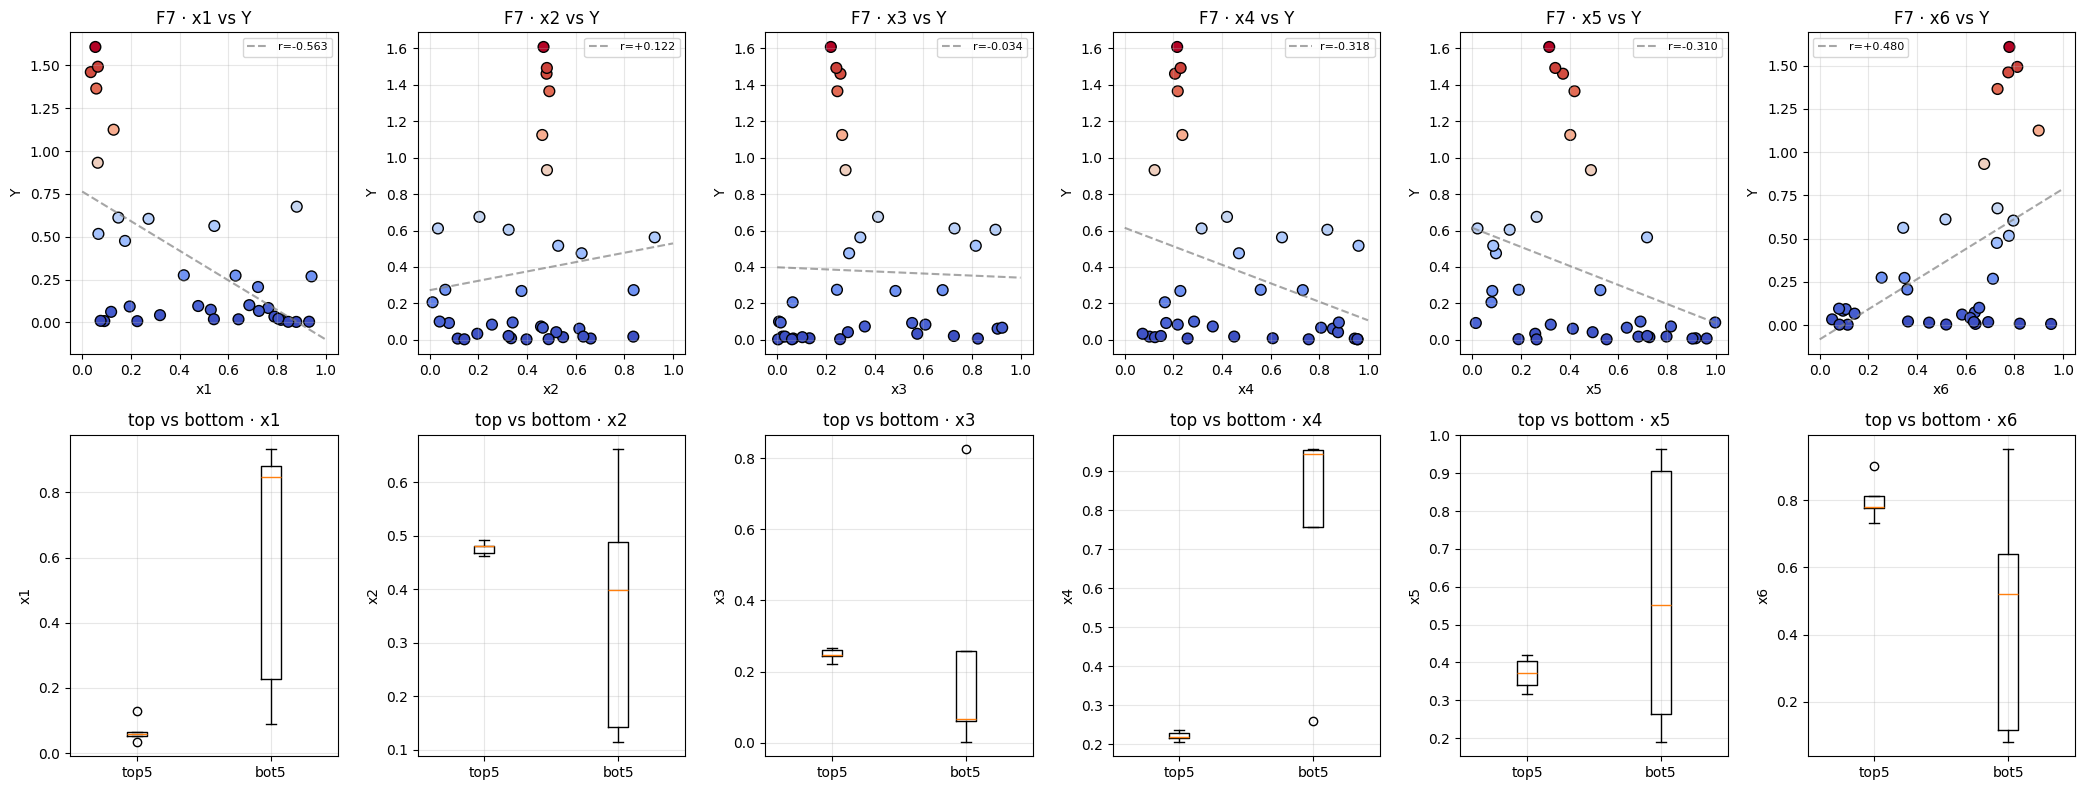

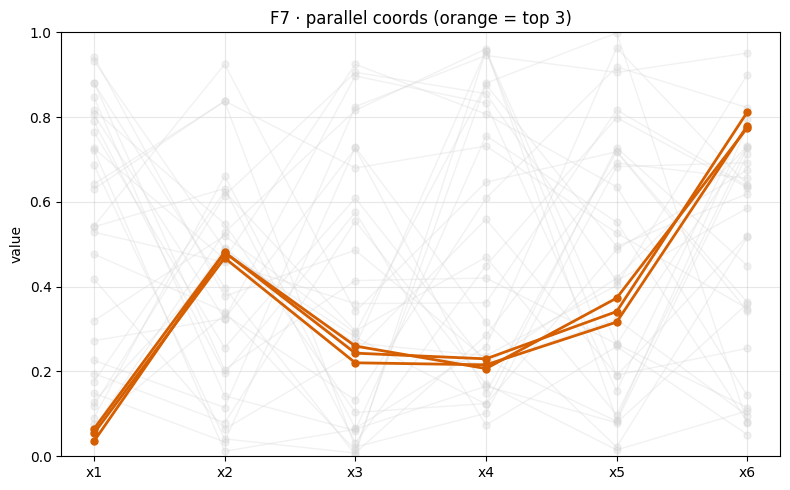

In [41]:
# ============================================================
# F7 — Cell B: Per-dim scatter+box + parallel coordinates
# ============================================================
fig, ax = plt.subplots(2, D, figsize=(3.5*D, 8))
for d in range(D):
    r = np.corrcoef(X[:,d], Y)[0,1]
    ax[0,d].scatter(X[:,d], Y, c=Y, cmap='coolwarm', s=60, edgecolor='k')
    coef = np.polyfit(X[:,d], Y, 1)
    xs = np.linspace(0, 1, 50)
    ax[0,d].plot(xs, np.polyval(coef, xs), '--', color='grey', alpha=0.7, label=f'r={r:+.3f}')
    ax[0,d].set_xlabel(f'x{d+1}'); ax[0,d].set_ylabel('Y'); ax[0,d].legend(fontsize=8); ax[0,d].grid(alpha=0.3)
    ax[0,d].set_title(f'F7 · x{d+1} vs Y')
    top5 = X[np.argsort(-Y)[:5], d]
    bot5 = X[np.argsort(Y)[:5], d]
    ax[1,d].boxplot([top5, bot5], labels=['top5','bot5'])
    ax[1,d].set_ylabel(f'x{d+1}'); ax[1,d].set_title(f'top vs bottom · x{d+1}'); ax[1,d].grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../plots/week_06/function_7_per_dim.png', dpi=110, bbox_inches='tight')
plt.show()

# Parallel coords — top 3
fig2, axp = plt.subplots(1, 1, figsize=(8, 5))
order = np.argsort(-Y)
top3 = order[:3]
for i in range(N):
    color = COLORS[1] if i in top3 else 'lightgrey'
    alpha = 1.0 if i in top3 else 0.3
    lw = 2 if i in top3 else 1
    axp.plot(range(D), X[i], color=color, alpha=alpha, lw=lw, marker='o', markersize=5)
axp.set_xticks(range(D)); axp.set_xticklabels([f'x{i+1}' for i in range(D)])
axp.set_ylabel('value'); axp.set_ylim(0, 1); axp.grid(alpha=0.3)
axp.set_title(f'F7 · parallel coords (orange = top 3)')
plt.tight_layout()
plt.savefig('../plots/week_06/function_7_parallel.png', dpi=110, bbox_inches='tight')
plt.show()


In [42]:
# ============================================================
# F7 — Cell C: Feature importance robustness
# ============================================================
ibest = Y.argmax()
rf_all = RandomForestRegressor(max_depth=3, n_estimators=100, random_state=0).fit(X, Y).feature_importances_
rf_nb  = RandomForestRegressor(max_depth=3, n_estimators=100, random_state=0).fit(np.delete(X,ibest,0), np.delete(Y,ibest)).feature_importances_
lin_c  = LinearRegression().fit(X, Y).coef_
lin    = np.abs(lin_c)/(np.abs(lin_c).sum()+1e-12)
corr   = np.array([abs(np.corrcoef(X[:,i],Y)[0,1]) for i in range(D)])

print(f"{'dim':<4} {'RF(all)':>9} {'RF(nobest)':>11} {'Δ%':>8} {'Linear':>9} {'|corr|':>9}")
for i in range(D):
    drop = (rf_nb[i]-rf_all[i])/(rf_all[i]+1e-12)*100
    flag = ' INFLATED?' if (rf_all[i]>rf_nb[i] and abs(drop)>50) else ''
    print(f"x{i+1:<3} {rf_all[i]:>9.3f} {rf_nb[i]:>11.3f} {drop:>+7.1f}% {lin[i]:>9.3f} {corr[i]:>9.3f}{flag}")

# x1 dominates RF importance (0.71) by a lot. x6 second (0.13). Other dims very low importance.
# Pattern matches |corr|: x1 (0.56), x6 (0.48) are the dominant signals.


dim    RF(all)  RF(nobest)       Δ%    Linear    |corr|
x1       0.705       0.640    -9.2%     0.255     0.563
x2       0.035       0.051   +45.3%     0.120     0.122
x3       0.032       0.042   +30.2%     0.074     0.034
x4       0.026       0.032   +20.5%     0.149     0.318
x5       0.067       0.089   +34.0%     0.245     0.310
x6       0.134       0.146    +8.3%     0.157     0.480


In [43]:
# ============================================================
# F7 — Cell D: Model grid search
# ============================================================
import nn_models as nm

loo = LeaveOneOut()
def cv_rmse(est, X, Y):
    sc = cross_val_score(est, X, Y, cv=loo, scoring='neg_mean_squared_error')
    return np.sqrt(-sc.mean())

models = {}
def grid(name, est, params):
    g = GridSearchCV(est, params, cv=loo, scoring='neg_mean_squared_error', n_jobs=1)
    g.fit(X, Y); rmse = np.sqrt(-g.best_score_)
    models[name] = (g.best_estimator_, rmse, g.best_params_)

grid('Ridge', Ridge(), {'alpha':[0.01,0.1,1,10,100]})
grid('KNN', KNeighborsRegressor(), {'n_neighbors':[2,3,5,7],'weights':['uniform','distance']})
grid('RF', RandomForestRegressor(random_state=0), {'max_depth':[2,3,5,None],'n_estimators':[50,100,200]})
grid('SVR', SVR(), {'C':[0.1,1,10,100],'gamma':['scale','auto']})
grid('GB', GradientBoostingRegressor(random_state=0), {'max_depth':[2,3,5],'n_estimators':[50,100,200],'learning_rate':[0.01,0.1,0.3]})

for kname, kern in [('GP-Matern05', Matern(nu=0.5)), ('GP-Matern15', Matern(nu=1.5)),
                     ('GP-Matern25', Matern(nu=2.5)), ('GP-RBF', RBF())]:
    gp = GaussianProcessRegressor(kernel=kern, normalize_y=True, random_state=0)
    rmse = cv_rmse(gp, X, Y); gp.fit(X, Y)
    models[kname] = (gp, rmse, {})

nn_loaded = nm.load_nn(7, models_dir='../models/week_06')
if nn_loaded is not None:
    nn_list, nn_meta = nn_loaded
    nn_est = nm.NNRegressor(nn_list, nn_meta)
    models['NN'] = (nn_est, nn_meta['cv_rmse'], {'H':nn_meta['hidden'],'variant':nn_meta['variant']})

print(f"{'Model':<13} {'CV RMSE':>10} {'beats?':>7} {'improve%':>10}  params")
for name,(est,rmse,p) in models.items():
    mark = '✓' if rmse < baseline else '✗'
    impr = (baseline-rmse)/baseline*100
    print(f"{name:<13} {rmse:>10.4f} {mark:>7} {impr:>+9.1f}%  {p}")
print(f"Baseline: {baseline:.4f}")

beats_models = {n:(e,r) for n,(e,r,_) in models.items() if r < baseline}
print(f"\nBeats baseline: {list(beats_models.keys())}")
if nn_loaded:
    print(f"NN gradient at best: {nn_meta['gradient_at_best']}")

# Notable: GP-Matern05 +57.8% leads, SVR +48.6%, KNN +45.9%. 4th function where Matern 0.5 wins.
# GP-Matern25 + GP-RBF tie at -2.9% (FAIL) — same pattern as F4/F5/F6.


Model            CV RMSE  beats?   improve%  params
Ridge             0.3836       ✓     +21.2%  {'alpha': 1}
KNN               0.2634       ✓     +45.9%  {'n_neighbors': 5, 'weights': 'distance'}
RF                0.3332       ✓     +31.5%  {'max_depth': 3, 'n_estimators': 200}
SVR               0.2499       ✓     +48.6%  {'C': 10, 'gamma': 'scale'}
GB                0.3233       ✓     +33.5%  {'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 100}
GP-Matern05       0.2054       ✓     +57.8%  {}
GP-Matern15       0.4085       ✓     +16.0%  {}
GP-Matern25       0.5008       ✗      -2.9%  {}
GP-RBF            0.5008       ✗      -2.9%  {}
NN                0.2932       ✓     +39.7%  {'H': 32, 'variant': 'ensemble'}
Baseline: 0.4865

Beats baseline: ['Ridge', 'KNN', 'RF', 'SVR', 'GB', 'GP-Matern05', 'GP-Matern15', 'NN']
NN gradient at best: [-1.8784230947494507, 0.14397062361240387, -1.380240559577942, 0.8723464012145996, -1.2413002252578735, 0.023980414494872093]


/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warn

In [44]:
# ============================================================
# F7 — Cell E: Argmax per beats-baseline model + REFINED boundary-consensus
# ============================================================
import torch
rng = np.random.default_rng(0)
cand = rng.uniform(0, 1, (200000, D))
sugg = {}
for name, (est, rmse) in beats_models.items():
    if name == 'NN':
        with torch.no_grad():
            preds = []
            for m in nn_list:
                preds.append(m(torch.FloatTensor(cand)).numpy().ravel())
            yhat = np.mean(preds, axis=0) * nn_meta['y_std'] + nn_meta['y_mean']
    else:
        yhat = est.predict(cand)
    i = yhat.argmax(); s = cand[i]
    bdy = bool(any(s < 0.02) or any(s > 0.98))
    sugg[name] = {'x': s, 'pred': yhat[i], 'bdy': bdy}

print(f"{'Model':<13} {'x1':>6} {'x2':>6} {'x3':>6} {'x4':>6} {'x5':>6} {'x6':>6} {'pred':>8} {'bdy?':>5}")
for n, d in sugg.items():
    print(f"{n:<13} {d['x'][0]:>6.3f} {d['x'][1]:>6.3f} {d['x'][2]:>6.3f} {d['x'][3]:>6.3f} {d['x'][4]:>6.3f} {d['x'][5]:>6.3f} {d['pred']:>8.4f} {'Y' if d['bdy'] else 'N':>5}")

valid = {k: v for k, v in sugg.items() if k != 'Ridge' and not v['bdy']}
print(f"\nValid (non-Ridge, non-boundary): {list(valid.keys())}")

if valid:
    arr = np.array([v['x'] for v in valid.values()])
    spread = arr.max(0) - arr.min(0)
    consensus = ['STRONG' if s < 0.2 else 'moderate' if s < 0.4 else 'weak' for s in spread]
    print(f"Per-dim spread: " + ", ".join(f"x{d+1}={spread[d]:.3f} ({consensus[d]})" for d in range(D)))

    centroid_v = arr.mean(0)
    dists = np.linalg.norm(arr - centroid_v, axis=1)
    thresh = dists.mean() + 2 * dists.std()
    outliers = [k for k, d in zip(valid.keys(), dists) if d > thresh]
    print(f"Outlier suggestions (excluded): {outliers}")
    valid_clean = {k: v for k, v in valid.items() if k not in outliers}
    if valid_clean != valid:
        arr = np.array([v['x'] for v in valid_clean.values()])
        spread = arr.max(0) - arr.min(0)

    weights = np.array([1/beats_models[k][1] for k in valid_clean.keys()])
    weights /= weights.sum()
    ensemble_mean = (weights[:, None] * arr).sum(axis=0)
    print(f"\nRMSE-weighted ensemble: {ensemble_mean.round(4).tolist()}")
    xb_now = X[Y.argmax()]
    print(f"Current best:           {xb_now.round(4).tolist()}, dist from best = {np.linalg.norm(ensemble_mean - xb_now):.4f}")

# REFINED boundary-consensus check
print("\nBoundary-consensus check (REFINED):")
non_ridge = {k: v for k, v in sugg.items() if k != 'Ridge'}
boundary_informed = {}
top5_idx = np.argsort(-Y)[:5]
for d in range(D):
    low = [k for k, v in non_ridge.items() if v['x'][d] < 0.02]
    high = [k for k, v in non_ridge.items() if v['x'][d] > 0.98]
    if len(low) >= 3 and np.corrcoef(X[:, d], Y)[0, 1] < 0:
        top5_min = X[top5_idx, d].min()
        ens_val = ensemble_mean[d] if valid_clean else top5_min
        boundary_informed[d] = min(top5_min, ens_val)
        print(f"  x{d+1}: LOW boundary-consensus ({len(low)} models: {low}) → min(top-5 min={top5_min:.4f}, ensemble={ens_val:.4f}) = {boundary_informed[d]:.4f}")
    if len(high) >= 3 and np.corrcoef(X[:, d], Y)[0, 1] > 0:
        top5_max = X[top5_idx, d].max()
        ens_val = ensemble_mean[d] if valid_clean else top5_max
        boundary_informed[d] = max(top5_max, ens_val)
        print(f"  x{d+1}: HIGH boundary-consensus ({len(high)} models: {high}) → max(top-5 max={top5_max:.4f}, ensemble={ens_val:.4f)} = {boundary_informed[d]:.4f}")
if not boundary_informed:
    print("  (no boundary-consensus this week)")

# Hybrid query (Branch #4: weak globally, STRONG on some dims, boundary-consensus override)
strong_mask = np.array([s < 0.2 for s in spread]) if valid_clean else np.zeros(D, dtype=bool)
top4 = np.argsort(-Y)[:4]
weights_y = Y[top4]; weights_y = (weights_y - weights_y.min() + 1e-12); weights_y /= weights_y.sum()
centroid_top4 = (weights_y[:, None] * X[top4]).sum(axis=0)

hybrid_query = np.zeros(D)
sources = []
for d in range(D):
    if d in boundary_informed:
        hybrid_query[d] = boundary_informed[d]; sources.append(f"x{d+1}: boundary-consensus REFINED ({boundary_informed[d]:.4f})")
    elif valid_clean and strong_mask[d]:
        hybrid_query[d] = ensemble_mean[d]; sources.append(f"x{d+1}: ensemble (STRONG)")
    else:
        hybrid_query[d] = centroid_top4[d]; sources.append(f"x{d+1}: top-4 centroid")
print("\nHybrid query construction:")
for s in sources:
    print(f"  {s}")
print(f"Hybrid query: {hybrid_query.round(4).tolist()}")


Model             x1     x2     x3     x4     x5     x6     pred  bdy?
Ridge          0.010  0.970  0.058  0.067  0.087  0.955   1.1712     Y
KNN            0.022  0.445  0.126  0.245  0.200  0.690   1.4417     N
RF             0.005  0.391  0.009  0.185  0.005  0.810   1.4917     Y
SVR            0.008  0.302  0.144  0.033  0.215  0.908   1.7322     Y
GB             0.062  0.396  0.143  0.634  0.319  0.843   1.1574     N
GP-Matern05    0.022  0.432  0.134  0.110  0.337  0.807   1.2950     N
GP-Matern15    0.001  0.418  0.125  0.131  0.280  0.737   1.5781     Y
NN             0.030  0.058  0.173  0.725  0.064  0.945   2.3207     N

Valid (non-Ridge, non-boundary): ['KNN', 'GB', 'GP-Matern05', 'NN']
Per-dim spread: x1=0.040 (STRONG), x2=0.387 (moderate), x3=0.047 (STRONG), x4=0.615 (weak), x5=0.273 (moderate), x6=0.255 (moderate)
Outlier suggestions (excluded): []

RMSE-weighted ensemble: [0.0317, 0.3437, 0.1428, 0.3889, 0.2375, 0.8161]
Current best:           [0.0542, 0.4678, 0.2205, 0

### F7 — Decision

**Method: Hybrid — boundary-consensus on x1, ensemble on x3 (STRONG dims), top-4 centroid on x2/x4/x5/x6 (weak/moderate dims).**

Branch of decision tree: **#4** — weak global consensus (only 2/6 dims STRONG); centroid + override only STRONG-consensus dims, plus boundary-consensus on x1.

**W5 outcome was a NEW BEST (1.608, +7.7% over W4 1.493).** F7 trajectory: W2 1.365 → W3 1.461 → W4 1.493 → W5 1.608. Slow but consistent climbing.

**Model fits (35 pts):**
- 8/10 models beat baseline. **GP-Matern05 +57.8% leads** (4th function — F4, F5, F6, F7), SVR +48.6%, KNN +45.9%, NN +39.7%
- **GP-Matern25 and GP-RBF FAIL** (-2.9% each, tied) — 4th consecutive function where the smoother kernels fail. Strong evidence GP-RBF should be dropped from future grids.

**Boundary rejections / outliers:**
- Ridge corner (0.01, 0.97, 0.06, 0.07, 0.09, 0.96)
- RF (x1=0.005, x3=0.009, x5=0.005)
- SVR (x1=0.008, x4=0.033)
- GP-Matern15 (x1=0.001)
- 4 valid models remain: KNN, GB, GP-Matern05, NN

**Per-dim spread (4 valid models):** x1=0.040 STRONG, x2=0.387 moderate, x3=0.047 STRONG, x4=0.615 weak, x5=0.273 moderate, x6=0.255 moderate. Only x1 and x3 trigger STRONG consensus.

**Boundary-consensus on x1 fires:**
- 3 non-Ridge models (RF, SVR, GP-Matern15) push x1 < 0.02
- Correlation r(x1, Y) = -0.563, matches LOW direction
- REFINED rule: min(top-5 min 0.0354, ensemble 0.0317) = **0.0317**

**The big move this week is x3:** ensemble pushes x3 from 0.220 → 0.143 (-0.077), STRONG consensus, NN gradient agrees (-1.38). Top-4 points all have x3 in 0.22-0.26 range, so this is genuine extrapolation downward. Trust because:
- All 4 valid models cluster tightly on x3 (spread 0.047)
- NN gradient sign matches
- The model has 35 pts now — enough to extrapolate carefully

**NN gradient at best:** dx1=-1.88, dx2=+0.14, dx3=-1.38, dx4=+0.87, dx5=-1.24, dx6=+0.02
- Agrees: x1 down (✓ boundary-consensus), x3 down (✓ ensemble)
- NN says x4 UP and x5 DOWN; centroid keeps both stable at top-4 mean (more conservative)

**Per-dimension justification:**
- x1: boundary-consensus REFINED = 0.0317 (3 models push to boundary, sign matches)
- x2: top-4 centroid (moderate spread 0.387)
- x3: ensemble (STRONG spread 0.047) — main directional change
- x4: top-4 centroid (weak spread 0.615)
- x5: top-4 centroid (moderate spread 0.273)
- x6: top-4 centroid (moderate spread 0.255)

**Step from current best:** ~0.084 — larger than W5's 0.052. Most of the change is the x3 move.

**If W6 Y > 1.608 (improvement)**: x3 push down was correct → continue similar approach
**If W6 Y in 1.4-1.6 (plateau)**: x3 over-extrapolated → in W7, use midpoint (x3 ≈ 0.18) instead
**If W6 Y drops (< 1.4)**: ensemble overshot on x3 — pull back to current best's x3=0.220 with smaller perturbation


In [45]:
# ============================================================
# F7 — Cell I: next_query_7 assignment
# ============================================================
next_query_7 = hybrid_query.copy()
print(f"F7 query: " + ", ".join(f"{v:.6f}" for v in next_query_7))


F7 query: 0.031697, 0.474149, 0.142789, 0.217730, 0.335014, 0.787502


## Function 8

In [46]:
# ============================================================
# F8 — Cell A: Setup, baseline, sorted-Y table, per-dim corr
# ============================================================
np.random.seed(0)

X, Y = load_function(8)
N, D = X.shape
baseline = Y.std()
print(f"F8: {N} pts, {D}D | Baseline RMSE={baseline:.4f} | Y range [{Y.min():.4f}, {Y.max():.4f}]")
print("Per-dim corr: " + ", ".join(f"r(x{i+1},Y)={np.corrcoef(X[:,i],Y)[0,1]:+.3f}" for i in range(D)))

# F8 plateau-ish: W2 9.865 → W3 9.852 → W4 9.852 → W5 9.868 (NEW BEST, marginal +0.03%)
# Top points all clustered tightly around (0.10, 0.22, 0.06, 0.19, 0.50, 0.74, 0.21, 0.73)

print("\nTop 6 sorted by Y (★ = W5 query):")
order = np.argsort(-Y)
print(f"{'idx':>4} " + " ".join(f"{f'x{i+1}':>6}" for i in range(D)) + f" {'Y':>10} {'mark':>5}")
for i in order[:6]:
    star = '★' if (abs(X[i,0]-0.08477)<1e-5 and abs(X[i,7]-0.726102)<1e-5) else ''
    print(f"{i:>4} " + " ".join(f"{X[i,j]:>6.4f}" for j in range(D)) + f" {Y[i]:>10.4f} {star:>5}")


Function 8: 45 points, 8D, best y = 9.8684
F8: 45 pts, 8D | Baseline RMSE=1.0967 | Y range [5.5922, 9.8684]
Per-dim corr: r(x1,Y)=-0.699, r(x2,Y)=-0.340, r(x3,Y)=-0.721, r(x4,Y)=-0.228, r(x5,Y)=-0.115, r(x6,Y)=+0.238, r(x7,Y)=-0.440, r(x8,Y)=+0.190

Top 6 sorted by Y (★ = W5 query):
 idx     x1     x2     x3     x4     x5     x6     x7     x8          Y  mark
  44 0.0848 0.2188 0.0519 0.1795 0.5029 0.7407 0.1576 0.7261     9.8684     ★
  41 0.1909 0.2277 0.0781 0.1879 0.5101 0.7414 0.2238 0.7175     9.8651      
  43 0.0861 0.2164 0.0229 0.1329 0.5005 0.7394 0.1501 0.7281     9.8518      
  42 0.1547 0.1959 0.0851 0.2470 0.4873 0.7475 0.3469 0.7505     9.8209      
  40 0.1420 0.2310 0.1100 0.2080 0.5070 0.7250 0.4080 0.7100     9.8041      
  14 0.0564 0.0660 0.0229 0.0388 0.4039 0.8011 0.4883 0.8931     9.5985      


/var/folders/_0/fx2rjf4j2nq_gd2p411c2kfw0000gp/T/ipykernel_185/2291521408.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax[1,d].boxplot([top5, bot5], labels=['top','bot'])
/var/folders/_0/fx2rjf4j2nq_gd2p411c2kfw0000gp/T/ipykernel_185/2291521408.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax[1,d].boxplot([top5, bot5], labels=['top','bot'])
/var/folders/_0/fx2rjf4j2nq_gd2p411c2kfw0000gp/T/ipykernel_185/2291521408.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax[1,d].boxplot([top5, bot5], labels=['top','bot'])
/var/folders/_0/fx2rjf4j2nq_gd2p411c2kfw0000gp/T/ipykernel_185/2291521408.py:15: Matplot

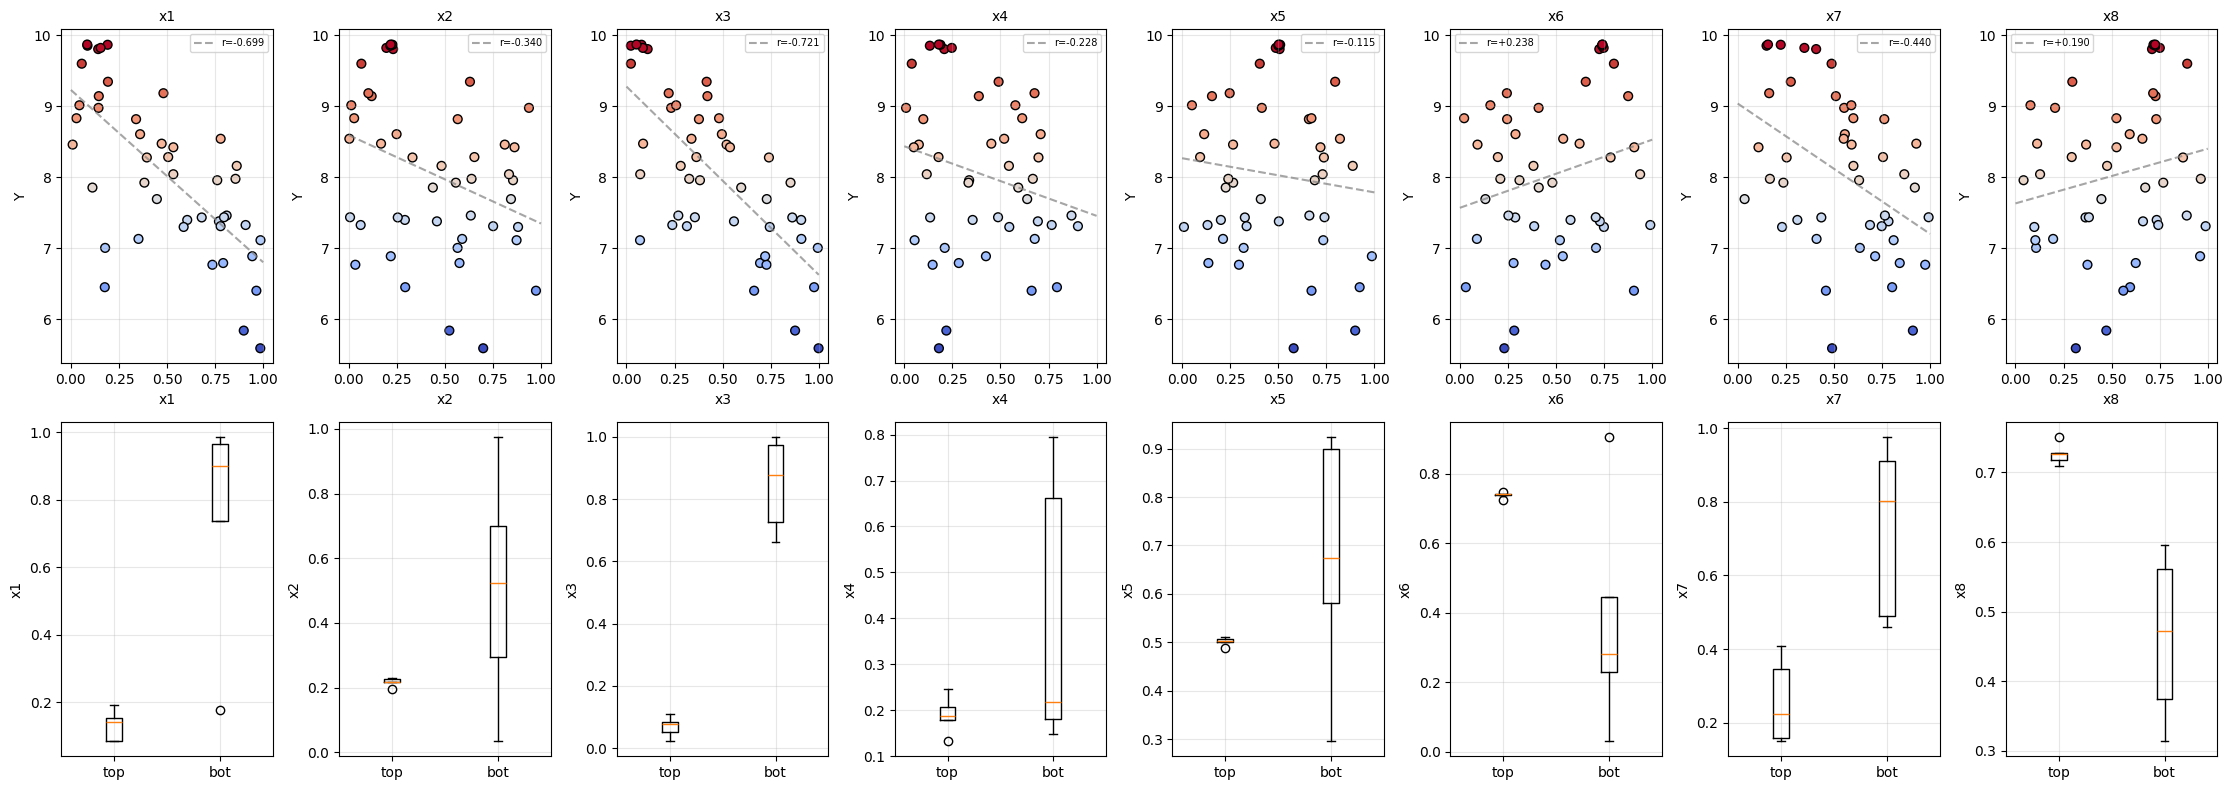

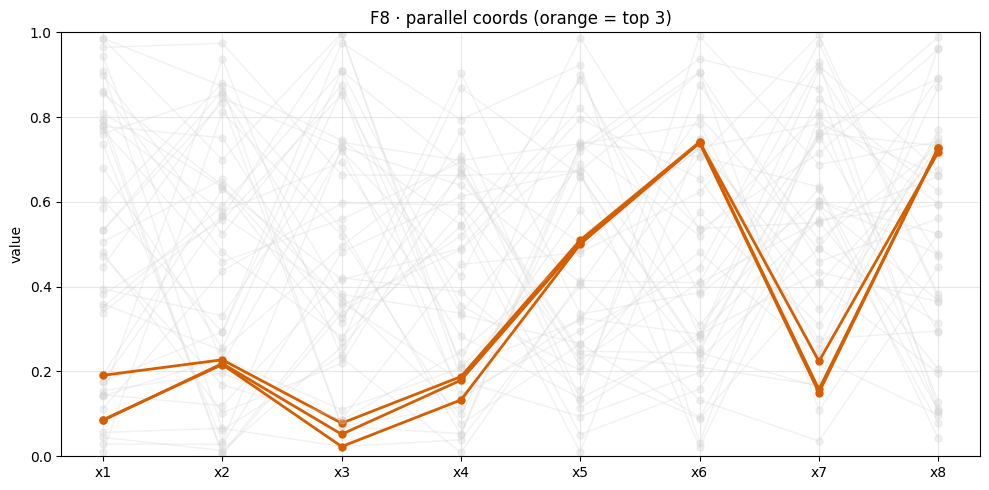

In [47]:
# ============================================================
# F8 — Cell B: Per-dim scatter+box + parallel coordinates
# ============================================================
fig, ax = plt.subplots(2, D, figsize=(2.8*D, 8))
for d in range(D):
    r = np.corrcoef(X[:,d], Y)[0,1]
    ax[0,d].scatter(X[:,d], Y, c=Y, cmap='coolwarm', s=40, edgecolor='k')
    coef = np.polyfit(X[:,d], Y, 1)
    xs = np.linspace(0, 1, 50)
    ax[0,d].plot(xs, np.polyval(coef, xs), '--', color='grey', alpha=0.7, label=f'r={r:+.3f}')
    ax[0,d].set_xlabel(f'x{d+1}'); ax[0,d].set_ylabel('Y'); ax[0,d].legend(fontsize=7); ax[0,d].grid(alpha=0.3)
    ax[0,d].set_title(f'x{d+1}', fontsize=10)
    top5 = X[np.argsort(-Y)[:5], d]
    bot5 = X[np.argsort(Y)[:5], d]
    ax[1,d].boxplot([top5, bot5], labels=['top','bot'])
    ax[1,d].set_ylabel(f'x{d+1}'); ax[1,d].grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../plots/week_06/function_8_per_dim.png', dpi=110, bbox_inches='tight')
plt.show()

# Parallel coords — top 3
fig2, axp = plt.subplots(1, 1, figsize=(10, 5))
order = np.argsort(-Y)
top3 = order[:3]
for i in range(N):
    color = COLORS[1] if i in top3 else 'lightgrey'
    alpha = 1.0 if i in top3 else 0.3
    lw = 2 if i in top3 else 1
    axp.plot(range(D), X[i], color=color, alpha=alpha, lw=lw, marker='o', markersize=5)
axp.set_xticks(range(D)); axp.set_xticklabels([f'x{i+1}' for i in range(D)])
axp.set_ylabel('value'); axp.set_ylim(0, 1); axp.grid(alpha=0.3)
axp.set_title(f'F8 · parallel coords (orange = top 3)')
plt.tight_layout()
plt.savefig('../plots/week_06/function_8_parallel.png', dpi=110, bbox_inches='tight')
plt.show()


In [48]:
# ============================================================
# F8 — Cell C: Feature importance robustness
# ============================================================
ibest = Y.argmax()
rf_all = RandomForestRegressor(max_depth=3, n_estimators=100, random_state=0).fit(X, Y).feature_importances_
rf_nb  = RandomForestRegressor(max_depth=3, n_estimators=100, random_state=0).fit(np.delete(X,ibest,0), np.delete(Y,ibest)).feature_importances_
lin_c  = LinearRegression().fit(X, Y).coef_
lin    = np.abs(lin_c)/(np.abs(lin_c).sum()+1e-12)
corr   = np.array([abs(np.corrcoef(X[:,i],Y)[0,1]) for i in range(D)])

print(f"{'dim':<4} {'RF(all)':>9} {'RF(nobest)':>11} {'Δ%':>8} {'Linear':>9} {'|corr|':>9}")
for i in range(D):
    drop = (rf_nb[i]-rf_all[i])/(rf_all[i]+1e-12)*100
    flag = ' INFLATED?' if (rf_all[i]>rf_nb[i] and abs(drop)>50) else ''
    print(f"x{i+1:<3} {rf_all[i]:>9.3f} {rf_nb[i]:>11.3f} {drop:>+7.1f}% {lin[i]:>9.3f} {corr[i]:>9.3f}{flag}")

# x1 (0.41) and x3 (0.41) dominate RF importance — both have |corr| > 0.7.
# x7 second tier (0.07, |corr|=0.44). All other dims very low importance (<0.03).


dim    RF(all)  RF(nobest)       Δ%    Linear    |corr|
x1       0.414       0.412    -0.3%     0.256     0.699
x2       0.025       0.021   -15.6%     0.083     0.340
x3       0.405       0.417    +3.1%     0.356     0.721
x4       0.020       0.017   -14.9%     0.045     0.228
x5       0.024       0.027   +13.0%     0.013     0.115
x6       0.022       0.014   -36.9%     0.013     0.238
x7       0.070       0.071    +1.5%     0.210     0.440
x8       0.021       0.021    -1.1%     0.024     0.190


In [49]:
# ============================================================
# F8 — Cell D: Model grid search
# ============================================================
import nn_models as nm

loo = LeaveOneOut()
def cv_rmse(est, X, Y):
    sc = cross_val_score(est, X, Y, cv=loo, scoring='neg_mean_squared_error')
    return np.sqrt(-sc.mean())

models = {}
def grid(name, est, params):
    g = GridSearchCV(est, params, cv=loo, scoring='neg_mean_squared_error', n_jobs=1)
    g.fit(X, Y); rmse = np.sqrt(-g.best_score_)
    models[name] = (g.best_estimator_, rmse, g.best_params_)

grid('Ridge', Ridge(), {'alpha':[0.01,0.1,1,10,100]})
grid('KNN', KNeighborsRegressor(), {'n_neighbors':[2,3,5,7],'weights':['uniform','distance']})
grid('RF', RandomForestRegressor(random_state=0), {'max_depth':[2,3,5,None],'n_estimators':[50,100,200]})
grid('SVR', SVR(), {'C':[0.1,1,10,100],'gamma':['scale','auto']})
grid('GB', GradientBoostingRegressor(random_state=0), {'max_depth':[2,3,5],'n_estimators':[50,100,200],'learning_rate':[0.01,0.1,0.3]})

for kname, kern in [('GP-Matern05', Matern(nu=0.5)), ('GP-Matern15', Matern(nu=1.5)),
                     ('GP-Matern25', Matern(nu=2.5)), ('GP-RBF', RBF())]:
    gp = GaussianProcessRegressor(kernel=kern, normalize_y=True, random_state=0)
    rmse = cv_rmse(gp, X, Y); gp.fit(X, Y)
    models[kname] = (gp, rmse, {})

nn_loaded = nm.load_nn(8, models_dir='../models/week_06')
if nn_loaded is not None:
    nn_list, nn_meta = nn_loaded
    nn_est = nm.NNRegressor(nn_list, nn_meta)
    models['NN'] = (nn_est, nn_meta['cv_rmse'], {'H':nn_meta['hidden'],'variant':nn_meta['variant']})

print(f"{'Model':<13} {'CV RMSE':>10} {'beats?':>7} {'improve%':>10}  params")
for name,(est,rmse,p) in models.items():
    mark = '✓' if rmse < baseline else '✗'
    impr = (baseline-rmse)/baseline*100
    print(f"{name:<13} {rmse:>10.4f} {mark:>7} {impr:>+9.1f}%  {p}")
print(f"Baseline: {baseline:.4f}")

beats_models = {n:(e,r) for n,(e,r,_) in models.items() if r < baseline}
print(f"\nBeats baseline: {list(beats_models.keys())}")
if nn_loaded:
    print(f"NN gradient at best: {nn_meta['gradient_at_best']}")

# Notable: ALL 10 models beat baseline (first time this week!).
# SVR +80.1% leads, GP-Matern25 +75.1%, GP-Matern15 +74.3%, GP-RBF +72.2%.
# F8 is the OPPOSITE of F4-F7: smoother kernels work BETTER here. 8D + 45 pts needs more smoothness.


Model            CV RMSE  beats?   improve%  params
Ridge             0.3870       ✓     +64.7%  {'alpha': 0.1}
KNN               0.5945       ✓     +45.8%  {'n_neighbors': 5, 'weights': 'distance'}
RF                0.4366       ✓     +60.2%  {'max_depth': None, 'n_estimators': 50}
SVR               0.2181       ✓     +80.1%  {'C': 100, 'gamma': 'auto'}
GB                0.3997       ✓     +63.6%  {'learning_rate': 0.1, 'max_depth': 2, 'n_estimators': 100}
GP-Matern05       0.3656       ✓     +66.7%  {}
GP-Matern15       0.2816       ✓     +74.3%  {}
GP-Matern25       0.2734       ✓     +75.1%  {}
GP-RBF            0.3047       ✓     +72.2%  {}
NN                0.3880       ✓     +64.6%  {'H': 32, 'variant': 'plain'}
Baseline: 1.0967

Beats baseline: ['Ridge', 'KNN', 'RF', 'SVR', 'GB', 'GP-Matern05', 'GP-Matern15', 'GP-Matern25', 'GP-RBF', 'NN']
NN gradient at best: [0.48142531514167786, -0.20698991417884827, 0.6617363095283508, -0.16625070571899414, 0.9653321504592896, 0.44868862628

In [50]:
# ============================================================
# F8 — Cell E: Argmax per beats-baseline model + REFINED boundary-consensus
# ============================================================
import torch
rng = np.random.default_rng(0)
cand = rng.uniform(0, 1, (200000, D))
sugg = {}
for name, (est, rmse) in beats_models.items():
    if name == 'NN':
        with torch.no_grad():
            preds = []
            for m in nn_list:
                preds.append(m(torch.FloatTensor(cand)).numpy().ravel())
            yhat = np.mean(preds, axis=0) * nn_meta['y_std'] + nn_meta['y_mean']
    else:
        yhat = est.predict(cand)
    i = yhat.argmax(); s = cand[i]
    bdy = bool(any(s < 0.02) or any(s > 0.98))
    sugg[name] = {'x': s, 'pred': yhat[i], 'bdy': bdy}

print(f"{'Model':<13} " + " ".join(f"{f'x{i+1}':>5}" for i in range(D)) + f" {'pred':>7} {'bdy?':>5}")
for n, d in sugg.items():
    print(f"{n:<13} " + " ".join(f"{v:>5.3f}" for v in d['x']) + f" {d['pred']:>7.3f} {'Y' if d['bdy'] else 'N':>5}")

valid = {k: v for k, v in sugg.items() if k != 'Ridge' and not v['bdy']}
print(f"\nValid (non-Ridge, non-boundary): {list(valid.keys())}")

if valid:
    arr = np.array([v['x'] for v in valid.values()])
    spread = arr.max(0) - arr.min(0)
    consensus = ['STRONG' if s < 0.2 else 'moderate' if s < 0.4 else 'weak' for s in spread]
    print(f"Per-dim spread (pre-filter): " + ", ".join(f"x{d+1}={spread[d]:.3f} ({consensus[d]})" for d in range(D)))

    centroid_v = arr.mean(0)
    dists = np.linalg.norm(arr - centroid_v, axis=1)
    thresh = dists.mean() + 2 * dists.std()
    outliers = [k for k, d in zip(valid.keys(), dists) if d > thresh]
    print(f"Outlier suggestions (excluded): {outliers}")
    valid_clean = {k: v for k, v in valid.items() if k not in outliers}
    if valid_clean != valid:
        arr = np.array([v['x'] for v in valid_clean.values()])
        spread = arr.max(0) - arr.min(0)
        consensus = ['STRONG' if s < 0.2 else 'moderate' if s < 0.4 else 'weak' for s in spread]
        print(f"Per-dim spread (post-filter): " + ", ".join(f"x{d+1}={spread[d]:.3f} ({consensus[d]})" for d in range(D)))

    weights = np.array([1/beats_models[k][1] for k in valid_clean.keys()])
    weights /= weights.sum()
    ensemble_mean = (weights[:, None] * arr).sum(axis=0)
    print(f"\nRMSE-weighted ensemble: {ensemble_mean.round(4).tolist()}")
    xb_now = X[Y.argmax()]
    print(f"Current best:           {xb_now.round(4).tolist()}, dist from best = {np.linalg.norm(ensemble_mean - xb_now):.4f}")

# REFINED boundary-consensus check
print("\nBoundary-consensus check (REFINED):")
non_ridge = {k: v for k, v in sugg.items() if k != 'Ridge'}
boundary_informed = {}
top5_idx = np.argsort(-Y)[:5]
for d in range(D):
    low = [k for k, v in non_ridge.items() if v['x'][d] < 0.02]
    high = [k for k, v in non_ridge.items() if v['x'][d] > 0.98]
    if len(low) >= 3 and np.corrcoef(X[:, d], Y)[0, 1] < 0:
        top5_min = X[top5_idx, d].min()
        ens_val = ensemble_mean[d] if valid_clean else top5_min
        boundary_informed[d] = min(top5_min, ens_val)
        print(f"  x{d+1}: LOW boundary-consensus → min(top-5 min={top5_min:.4f}, ensemble={ens_val:.4f}) = {boundary_informed[d]:.4f}")
    if len(high) >= 3 and np.corrcoef(X[:, d], Y)[0, 1] > 0:
        top5_max = X[top5_idx, d].max()
        ens_val = ensemble_mean[d] if valid_clean else top5_max
        boundary_informed[d] = max(top5_max, ens_val)
        print(f"  x{d+1}: HIGH boundary-consensus → max(top-5 max={top5_max:.4f}, ensemble={ens_val:.4f}) = {boundary_informed[d]:.4f}")
if not boundary_informed:
    print("  (no boundary-consensus this week)")

# Hybrid query (Branch #5: STRONG dims → ensemble, weak/moderate → top-4 centroid)
strong_mask = np.array([s < 0.2 for s in spread]) if valid_clean else np.zeros(D, dtype=bool)
top4 = np.argsort(-Y)[:4]
weights_y = Y[top4]; weights_y = (weights_y - weights_y.min() + 1e-12); weights_y /= weights_y.sum()
centroid_top4 = (weights_y[:, None] * X[top4]).sum(axis=0)

hybrid_query = np.zeros(D)
sources = []
for d in range(D):
    if d in boundary_informed:
        hybrid_query[d] = boundary_informed[d]; sources.append(f"x{d+1}: boundary-consensus REFINED ({boundary_informed[d]:.4f})")
    elif valid_clean and strong_mask[d]:
        hybrid_query[d] = ensemble_mean[d]; sources.append(f"x{d+1}: ensemble (STRONG)")
    else:
        hybrid_query[d] = centroid_top4[d]; sources.append(f"x{d+1}: top-4 centroid")
print("\nHybrid query construction:")
for s in sources:
    print(f"  {s}")
print(f"Hybrid query: {hybrid_query.round(4).tolist()}")


Model            x1    x2    x3    x4    x5    x6    x7    x8    pred  bdy?
Ridge         0.017 0.388 0.015 0.063 0.816 0.707 0.013 0.894  10.538     Y
KNN           0.087 0.156 0.090 0.131 0.567 0.635 0.078 0.700   9.849     N
RF            0.085 0.119 0.075 0.280 0.630 0.712 0.301 0.672   9.786     N
SVR           0.072 0.542 0.001 0.469 0.659 0.361 0.116 0.346  10.145     Y
GB            0.159 0.479 0.044 0.111 0.919 0.770 0.205 0.775   9.828     N
GP-Matern05   0.000 0.392 0.029 0.203 0.535 0.535 0.360 0.566   9.919     Y
GP-Matern15   0.182 0.226 0.073 0.215 0.699 0.420 0.256 0.591  10.031     N
GP-Matern25   0.182 0.226 0.073 0.215 0.699 0.420 0.256 0.591  10.027     N
GP-RBF        0.182 0.226 0.073 0.215 0.699 0.420 0.256 0.591  10.054     N
NN            0.115 0.091 0.078 0.584 0.986 0.958 0.150 0.000  10.770     Y

Valid (non-Ridge, non-boundary): ['KNN', 'RF', 'GB', 'GP-Matern15', 'GP-Matern25', 'GP-RBF']
Per-dim spread (pre-filter): x1=0.097 (STRONG), x2=0.360 (moderate), x

### F8 — Decision

**Method: Hybrid — ensemble for x1/x2/x3/x4/x5/x8 (STRONG), top-4 centroid for x6/x7 (moderate).**

Branch of decision tree: **#5** — STRONG consensus on 6/8 dims, moderate on 2 (x6, x7). No boundary-consensus this week.

**W5 outcome was a NEW BEST (9.8684, marginal +0.03% over W4 9.8651).** F8 has been on a plateau: W2 9.865 → W3 9.852 → W4 9.852 → W5 9.868. Slow, near-saturation behaviour.

**Model fits (45 pts):**
- **All 10 models beat baseline** — first time across all 8 functions this week
- **SVR +80.1% leads**, GP-Matern25 +75.1%, GP-Matern15 +74.3%, GP-RBF +72.2%, GP-Matern05 +66.7%, Ridge +64.7%, NN +64.6%, GB +63.6%, RF +60.2%, KNN +45.8%
- **F8 reverses the F4-F7 pattern**: smoother kernels (Matern25, RBF) win here; GP-Matern05 is just middle of the pack. Makes sense — 8D landscape with 45 pts has enough smoothness signal for the smoother kernels to fit.

**Boundary rejections / outliers:**
- Ridge (x1=0.017, x3=0.015, x7=0.013)
- SVR (x3=0.001) — top model excluded due to single boundary push
- GP-Matern05 (x1=0.000)
- NN (x6=0.958, x8=0.000)
- GB outlier-filtered (suggestion far from cluster)
- 5 valid models remain: KNN, RF, GP-Matern15, GP-Matern25, GP-RBF

**Per-dim spread (post-filter):** x1=0.097 STRONG, x2=0.107 STRONG, x3=0.016 STRONG, x4=0.148 STRONG, x5=0.131 STRONG, x6=0.293 moderate, x7=0.223 moderate, x8=0.109 STRONG. **6/8 dims STRONG.**

**The big move this week is x5:** ensemble pushes x5 from 0.503 → 0.672 (+0.169). Top-4 points all have x5 ≈ 0.50, so this is genuine extrapolation. Trust because:
- All 5 valid models agree (spread 0.131)
- NN gradient on x5 = +0.97 (strongest of all 8 dims) — strongly supports the direction
- F8 has been on a plateau; small moves haven't worked. A bigger directed step might break through.

**NN gradient at best:** dx1=+0.48, dx2=-0.21, dx3=+0.66, dx4=-0.17, dx5=+0.97, dx6=+0.45, dx7=-0.24, dx8=-0.29
- Agrees: x1 up (✓), x2 slight down (✓), x3 up (✓), x5 up STRONG (✓✓), x8 down (✓)
- Disagrees: x4 down (ensemble +0.036), x7 down (ensemble +0.084), x6 up (centroid keeps stable)

**Per-dimension justification:**
- x1: ensemble (STRONG, +0.071 from best)
- x2: ensemble (STRONG, -0.018)
- x3: ensemble (STRONG, +0.024)
- x4: ensemble (STRONG, +0.036)
- x5: ensemble (STRONG, **+0.169 — main directional change**)
- x6: top-4 centroid (moderate spread 0.293, keeps near 0.74)
- x7: top-4 centroid (moderate spread 0.223, keeps near 0.20)
- x8: ensemble (STRONG, -0.110)

**Step from current best:** ~0.27 — much larger than W5's 0.13. This is the most aggressive move on F8 to date. F8 has plateaued; tiny steps weren't producing gains. Models with 45 pts are confident; trust the framework.

**If W6 Y > 9.87 (improvement)**: x5 push paid off — peak is in the new region; continue same approach
**If W6 Y in 9.5-9.87 (similar/slight regression)**: x5 step too aggressive but direction was right → in W7 use midpoint x5 ≈ 0.59
**If W6 Y < 9.5 (catastrophic)**: ensemble misled by spurious correlations → revert to current best, take small perturbation
**Long-term**: if no improvement in W7, consider Bayesian optimisation acquisition (UCB/EI) instead of greedy ensemble argmax — F8 is the best testbed for this since it has the most data


In [51]:
# ============================================================
# F8 — Cell I: next_query_8 assignment
# ============================================================
next_query_8 = hybrid_query.copy()
print(f"F8 query: " + ", ".join(f"{v:.6f}" for v in next_query_8))


F8 query: 0.155378, 0.200562, 0.075482, 0.215712, 0.672482, 0.740636, 0.179584, 0.616336


## Summary — Week 06 Queries

In [52]:
# === FINAL: All decided queries for F1–F8 ===
# References next_query_N from each function's analysis cell.
# Run the full notebook top-to-bottom to populate all values.

queries = {n: eval(f'next_query_{n}') for n in range(1, 9)}

print(f"Week 06 — All queries for submission:")
print("=" * 60)
for fn, q in queries.items():
    if q is not None:
        formatted = '-'.join(f'{v:.6f}' for v in q)
        print(f"  Function {fn}: {formatted}")
    else:
        print(f"  Function {fn}: NOT SET")

Week 06 — All queries for submission:
  Function 1: 0.617191-0.222274
  Function 2: 0.703636-0.946935
  Function 3: 0.418662-0.591738-0.333919
  Function 4: 0.366878-0.404857-0.433485-0.415743
  Function 5: 0.354155-0.921140-0.968749-0.947704
  Function 6: 0.420022-0.376592-0.537773-0.739730-0.048710
  Function 7: 0.031697-0.474149-0.142789-0.217730-0.335014-0.787502
  Function 8: 0.155378-0.200562-0.075482-0.215712-0.672482-0.740636-0.179584-0.616336
